# Load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

The colorectal cancer cohort initially included 217 samples. After excluding samples with incomplete sequencing files or missing processing-time metadata, 211 samples were retained for analysis.

Excluded samples:
- `P2-S8`, `P2-S9`, `P2-S19`, `P8-S18`: incomplete FASTQ lane availability
- `P9-25`: missing from the processing-time metadata table
- `P4-S1`: missing `extraction_time` value

Note: earlier project code used `fast` and `slow` as internal labels for the Immediate and Delayed processing groups, respectively. Some variable names retain this convention, but all manuscript-facing text and figures use Immediate/Delayed terminology.

This notebook expects processed MiXCR TRB clonotype tables generated as described in the Methods. Place the `.tsv` files in `data/mixcr_trb/` and the sample metadata file at `data/colon_meta_time.csv`.

In [ ]:
from pathlib import Path

DATA_DIR = Path("data")
MIXCR_DIR = DATA_DIR / "mixcr_trb"
META_FILE = DATA_DIR / "colon_meta_time.csv"
FIGURE_DIR = Path("figures")

TIME_THRESHOLD = 750  # Samples processed at or below this time are assigned to the Immediate group.
IF_SAVE = True

def save_plot(path_or_name, format="svg", **kwargs):
    """Save current matplotlib figure if IF_SAVE is enabled."""
    if not IF_SAVE:
        return

    FIGURE_DIR.mkdir(exist_ok=True)
    out_path = FIGURE_DIR / Path(path_or_name).name
    plt.rcParams["svg.fonttype"] = "none"
    print(f"Saving figure to: {out_path}")
    plt.savefig(out_path, format=format, **kwargs)


def p_to_star(p):
    if p is None or np.isnan(p):
        return "ns"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"

In [ ]:
if not MIXCR_DIR.exists():
    raise FileNotFoundError(
        f"MiXCR directory not found: {MIXCR_DIR}. "
        "Place processed MiXCR TRB .tsv files in data/mixcr_trb/ before running this notebook."
    )

if not META_FILE.exists():
    raise FileNotFoundError(
        f"Metadata file not found: {META_FILE}. "
        "Place colon_meta_time.csv in data/ before running this notebook."
    )

In [ ]:
# Load Metadata
meta_df = pd.read_csv(META_FILE)[["Sample_ID", "extraction_time"]]

# Load and Aggregate MiXCR Files
mixcr_cols = [
    "aaSeqCDR3", "nSeqCDR3", "readCount", 'readFraction',
    "allVHitsWithScore", "allDHitsWithScore", "allJHitsWithScore"
]

clonotype_dfs = []

# Iterate over files in directory
for fname in os.listdir(MIXCR_DIR):
    file_path = os.path.join(MIXCR_DIR, fname)
    
    # Check if it is a valid file
    if os.path.isfile(file_path) and fname.endswith(".tsv"):
        # Extract Sample ID (assumes format: SAMPLEID_suffix.tsv)
        sample_id = fname.split("_")[0]
        
        try:
            df = pd.read_csv(file_path, sep="\t", usecols=mixcr_cols)
            df["Sample_ID"] = sample_id
            clonotype_dfs.append(df)
        except Exception as e:
            print(f"Warning: Could not read {fname}. Error: {e}")

if not clonotype_dfs:
    raise ValueError("No matching MiXCR files found in the directory.")

clonotype_df = pd.concat(clonotype_dfs, ignore_index=True)

# Merge with Metadata
clonotype_df = clonotype_df.merge(meta_df, on="Sample_ID", how="inner")

# Clean Extraction Time
# Force numeric; invalid values become NaN for easy filtering
clonotype_df['extraction_time'] = pd.to_numeric(clonotype_df['extraction_time'], errors='coerce')

# Remove samples with missing or invalid time data
valid_mask = clonotype_df['extraction_time'].notnull()
excluded_samples = clonotype_df.loc[~valid_mask, 'Sample_ID'].unique()

if len(excluded_samples) > 0:
    print(f"Excluding {len(excluded_samples)} samples due to missing/invalid extraction_time: {excluded_samples}")
    clonotype_df = clonotype_df.loc[valid_mask].copy()

# Assign Groups (Fast vs Slow)
# Create a single source of truth for grouping to avoid logic mismatches later
clonotype_df["group"] = np.where(
    clonotype_df["extraction_time"] <= TIME_THRESHOLD, "fast", "slow"
)

print(f"Final processed dataset: {clonotype_df['Sample_ID'].nunique()} unique samples.")

Excluding 1 samples due to missing/invalid extraction_time: ['P4-S1']
Final processed dataset: 211 unique samples.


In [17]:
# Filter cohorts based on the 'group' column assigned above
fast_group = clonotype_df[clonotype_df["group"] == "fast"]
slow_group = clonotype_df[clonotype_df["group"] == "slow"]

# Figure 2 - Repertoire diversity analysis

## Overview

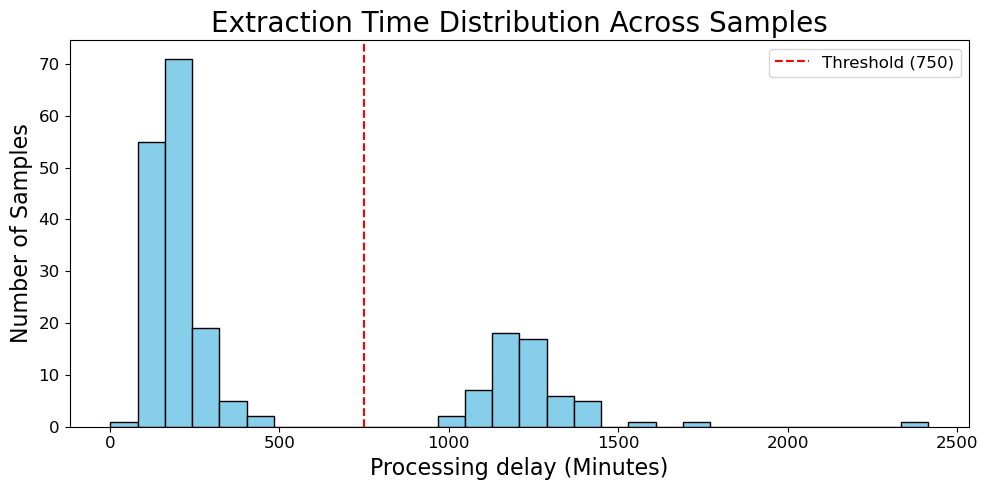

In [ ]:
# visualize Extraction time distribution in Dataset
unique_samples = clonotype_df.drop_duplicates('Sample_ID')

plt.figure(figsize=(10, 5))
plt.hist(unique_samples['extraction_time'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(TIME_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({TIME_THRESHOLD})')
plt.xlabel('Processing delay (Minutes)', fontsize=16)
plt.ylabel('Number of Samples', fontsize=16)
plt.title('Extraction Time Distribution Across Samples', fontsize=20)
plt.tick_params(axis='x', labelsize=12)  
plt.tick_params(axis='y', labelsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
save_plot("sample_time_distribution.svg", format="svg")

plt.show()

In [6]:
# Extract unique repertoire sets (Amino Acid CDR3s)
fast_clonotypes = set(fast_group["aaSeqCDR3"])
slow_clonotypes = set(slow_group["aaSeqCDR3"])

print("-" * 40)
print(f"Total clones (rows) in Fast group: {len(fast_group)}")
print(f"Total clones (rows) in Slow group: {len(slow_group)}")
print("-" * 40)
print(f"Unique CDR3s in Fast repertoire:   {len(fast_clonotypes)}")
print(f"Unique CDR3s in Slow repertoire:   {len(slow_clonotypes)}")

num_fast_samples = fast_group["Sample_ID"].nunique()
num_slow_samples = slow_group["Sample_ID"].nunique()

# Count clonotypes per sample 
fast_clonotypes_per_sample = (
    fast_group.groupby("Sample_ID")["aaSeqCDR3"].nunique()
)
slow_clonotypes_per_sample = (
    slow_group.groupby("Sample_ID")["aaSeqCDR3"].nunique()
)

avg_fast = fast_clonotypes_per_sample.mean()
med_fast = fast_clonotypes_per_sample.median()
avg_slow = slow_clonotypes_per_sample.mean()
med_slow = slow_clonotypes_per_sample.median()

# Print results
num_fast_samples = fast_group["Sample_ID"].nunique()
num_slow_samples = slow_group["Sample_ID"].nunique()

print(f"Number of samples in fast group: {num_fast_samples}")
print(f"Average clonotypes per fast sample: {avg_fast:.1f}")
print(f"Median clonotypes per fast sample: {med_fast:.1f}\n")

print(f"Number of samples in slow group: {num_slow_samples}")
print(f"Average clonotypes per slow sample: {avg_slow:.1f}")
print(f"Median clonotypes per slow sample: {med_slow:.1f}")


----------------------------------------
Total clones (rows) in Fast group: 12982717
Total clones (rows) in Slow group: 2229779
----------------------------------------
Unique CDR3s in Fast repertoire:   8991978
Unique CDR3s in Slow repertoire:   1852705
Number of samples in fast group: 153
Average clonotypes per fast sample: 82060.1
Median clonotypes per fast sample: 75004.0

Number of samples in slow group: 58
Average clonotypes per slow sample: 37566.7
Median clonotypes per slow sample: 32296.5


In [19]:
clone_stats_df = pd.DataFrame({
    "Group": ["Fast", "Slow"],
    "Num Samples": [num_fast_samples, num_slow_samples],
    "Avg Clonotypes/Sample": [avg_fast, avg_slow],
    "Median Clonotypes/Sample": [med_fast, med_slow]
})

print(clone_stats_df.to_string(index=False, float_format='%.1f'))

Group  Num Samples  Avg Clonotypes/Sample  Median Clonotypes/Sample
 Fast          153                82060.1                   75004.0
 Slow           58                37566.7                   32296.5


Saving figure to: figures/clonotype_richness.svg


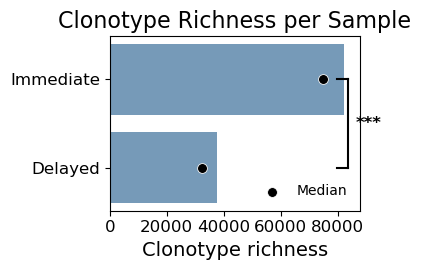

Immediate n = 153, Delayed n = 58
Mann–Whitney U test: U = 7.16e+03, p = 6.670e-12


In [ ]:
from scipy.stats import mannwhitneyu

# sample-level richness
sample_richness_df = (
    clonotype_df
    .groupby(["Sample_ID", "group"])["aaSeqCDR3"]
    .nunique()
    .reset_index(name="Clonotype_Richness")
)

sample_richness_df["Group"] = sample_richness_df["group"].replace({
    "fast": "Immediate",
    "slow": "Delayed",
    "Fast": "Immediate",
    "Slow": "Delayed"
})

order = ["Immediate", "Delayed"]

# Mann–Whitney U test
immediate = sample_richness_df.loc[
    sample_richness_df["Group"] == "Immediate", "Clonotype_Richness"
].dropna()

delayed = sample_richness_df.loc[
    sample_richness_df["Group"] == "Delayed", "Clonotype_Richness"
].dropna()

u_stat, p_val = mannwhitneyu(immediate, delayed, alternative="two-sided")

p_label = p_to_star(p_val)

# mean bars + median dots
summary_df = (
    sample_richness_df
    .groupby("Group")["Clonotype_Richness"]
    .agg(mean="mean", median="median")
    .reindex(order)
    .reset_index()
)

plt.figure(figsize=(4, 2.8))

sns.barplot(data=summary_df, x="mean", y="Group",
             order=order, color="steelblue", alpha=0.8)
sns.scatterplot(data=summary_df, x="median", y="Group",
                 color="black", s=50, zorder=10, label="Median")

# positions
y1, y2 = 0, 1
x = summary_df["mean"].max() * 1.02
h = summary_df["mean"].max() * 0.05

# vertical line
plt.plot([x, x], [y1, y2], color="black", lw=1.5)

# flip horizontal ticks to the LEFT
plt.plot([x - h, x], [y1, y1], color="black", lw=1.5)
plt.plot([x - h, x], [y2, y2], color="black", lw=1.5)

# label (keep on the right)
plt.text(x + h * 0.6, 0.5, p_label, va="center", fontsize=12, fontweight="bold")

plt.xlabel("Clonotype richness", fontsize=14)
plt.ylabel("")
plt.title("Clonotype Richness per Sample", fontsize=16)
plt.tick_params(axis="x", labelsize=12)
plt.tick_params(axis="y", labelsize=12)
plt.legend(frameon=False)

plt.tight_layout()
save_plot("clonotype_richness.svg", format="svg")
plt.show()

print(f"Immediate n = {len(immediate)}, Delayed n = {len(delayed)}")
print(f"Mann–Whitney U test: U = {u_stat:.3g}, p = {p_val:.3e}")

## Rarefraction analysis

Rarefaction analysis showing the number of unique clonotypes detected as a function of sequencing depth (subsampled reads). Used to assess repertoire diversity saturation across samples.

Rarefaction Limit: 209,378 reads


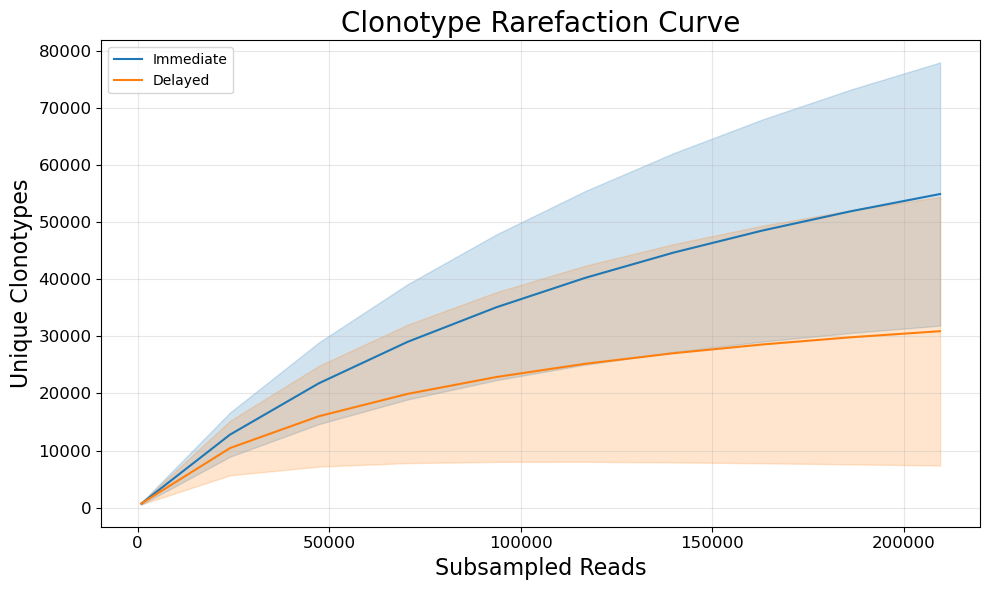

In [ ]:
# limit by the sample with the fewest reads.
min_total_reads = clonotype_df.groupby("Sample_ID")["readCount"].sum().min()
max_curve_limit = int(min_total_reads) 

# Create 10 evenly spaced steps
depths = np.linspace(1000, max_curve_limit, num=10, dtype=int)
print(f"Rarefaction Limit: {max_curve_limit:,} reads")

rarefaction_results = []

# Iterate Per Sample
grouped_samples = clonotype_df.groupby(["Sample_ID", "group"])

for (sample_id, group_label), sample_data in grouped_samples:
    counts = sample_data["readCount"].values.astype(int)
    total_reads = counts.sum()
    # Skip if sample is too small
    if total_reads < depths[0]:
        continue

    # Instead of expanding strings ["CASS..", "CASS.."], we expand indices [0, 0]
    # np.repeat creates an array where index '0' appears 'count[0]' times
    # This represents the "Bag of Reads" using lightweight integers
    read_indices = np.repeat(np.arange(len(counts)), counts)
    
    np.random.shuffle(read_indices)
    
    for depth in depths:
        if depth > total_reads:
            break
        
        # Slicing the first 'depth' elements simulates sampling wihtout replacement
        subsample = read_indices[:depth]
        
        # Count unique integers (which correspond to unique clonotypes)
        unique_clonotypes = len(np.unique(subsample))
        
        rarefaction_results.append({
            "Sample_ID": sample_id,
            "group": group_label,
            "depth": depth,
            "unique_clonotypes": unique_clonotypes
        })

# Plotting
rarefaction_df = pd.DataFrame(rarefaction_results)

rarefaction_df["group"] = rarefaction_df["group"].replace({
    "fast": "Immediate",
    "slow": "Delayed"
})

plt.figure(figsize=(10, 6))
sns.lineplot(data=rarefaction_df, x="depth", y="unique_clonotypes", hue="group",
            palette={"Immediate": "tab:blue", "Delayed": "tab:orange"}, estimator="mean",
            errorbar=("sd", 1) )

plt.title("Clonotype Rarefaction Curve", fontsize=20)
plt.xlabel("Subsampled Reads", fontsize=16)
plt.ylabel("Unique Clonotypes", fontsize=16)
plt.tick_params(axis='x', labelsize=12)  
plt.tick_params(axis='y', labelsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="")
plt.tight_layout()
save_plot("rarefaction_curve.svg", format="svg")

plt.show()


## Singleton and clone-size distribution analyses

For visualization purposes, the y-axis was truncated at 2,000 singleton clonotypes due to extreme outlier samples.

Saving figure to: figures/normalized_singleton.svg


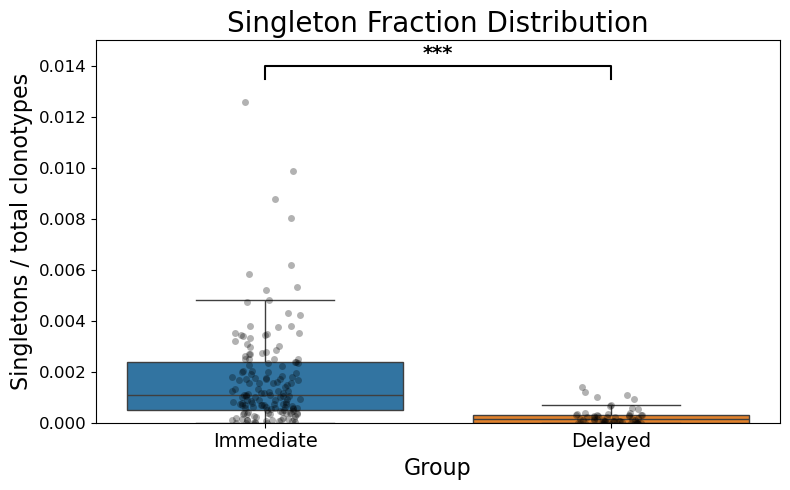

Mann–Whitney U test: U = 7.7e+03, p = 1.574e-16


In [ ]:
sample_stats = (
    clonotype_df.groupby(["Sample_ID", "group"])
    .agg(
        total_clonotypes=("aaSeqCDR3", "nunique"),
        singleton_count=("readCount", lambda x: (x == 1).sum())
    ).reset_index())

sample_stats["singleton_proportion"] = (
    sample_stats["singleton_count"] / sample_stats["total_clonotypes"])

sample_stats["group"] = sample_stats["group"].replace({
    "fast": "Immediate",
    "slow": "Delayed"})

order = ["Immediate", "Delayed"]

immediate = sample_stats.loc[
    sample_stats["group"] == "Immediate", "singleton_proportion"
].dropna()

delayed = sample_stats.loc[
    sample_stats["group"] == "Delayed", "singleton_proportion"
].dropna()

u_stat, p_val = mannwhitneyu(immediate, delayed, alternative="two-sided")

p_label = p_to_star(p_val)

plt.figure(figsize=(8, 5))

ax = sns.boxplot(data=sample_stats, x="group", y="singleton_proportion", order=order, hue="group", showfliers=False, legend=False)
sns.stripplot(data=sample_stats, x="group", y="singleton_proportion", order=order, color="black", alpha=0.3, dodge=False, clip_on=True)
plt.ylim(0, 0.015)

# p-value bracket
y = 0.0135
h = 0.0005
x1, x2 = 0, 1

plt.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", lw=1.5)
plt.text((x1 + x2) / 2, y + h * 1.2, p_label, ha="center", va="bottom", fontsize=14, fontweight="bold")

plt.title("Singleton Fraction Distribution", fontsize=20)
plt.ylabel("Singletons / total clonotypes", fontsize=16)
plt.xlabel("Group", fontsize=16)

plt.ylim(0, y + h * 3)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=12)

plt.tight_layout()
save_plot("normalized_singleton.svg", format="svg")
plt.show()

print(f"Mann–Whitney U test: U = {u_stat:.3g}, p = {p_val:.3e}")

 Clonal Size Distribution Binning

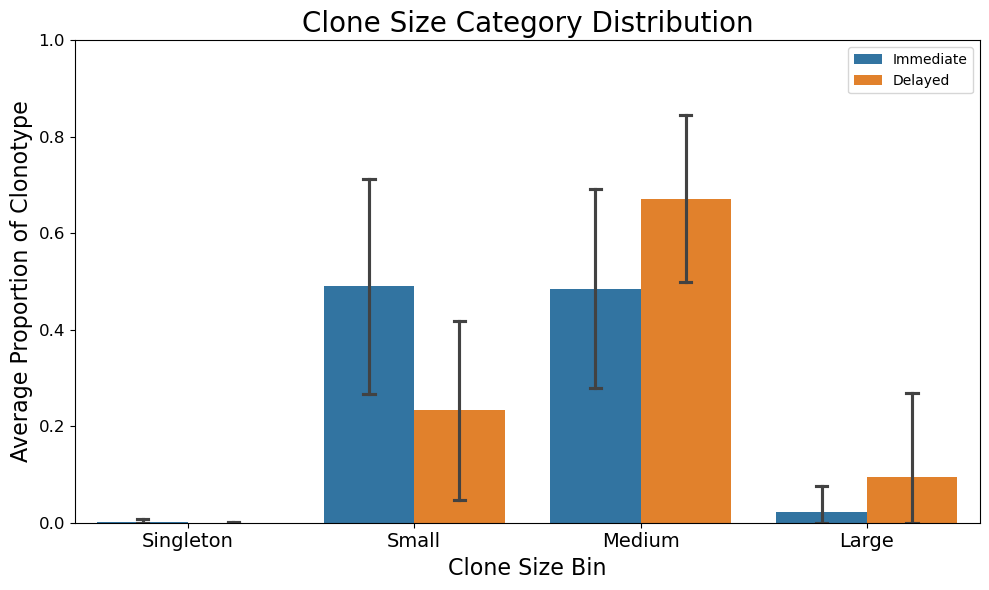

In [40]:
def clipped_sd(x):
    mean = np.mean(x)
    std = np.std(x, ddof=1)  # ddof=1 for sample standard deviation
    lower = max(0, mean - std) # This prevents the negative dip
    upper = mean + std
    return (lower, upper)

# Vectorized Binning
bins = [0, 1, 10, 100, np.inf]
labels = ["Singleton", "Small", "Medium", "Large"]

clonotype_df["size_bin"] = pd.cut(
    clonotype_df["readCount"], 
    bins=bins, 
    labels=labels
)

# Aggregation per Sample
# We group by Sample and Group to distinguish timepoints
bin_counts = (
    clonotype_df.groupby(["Sample_ID", "group", "size_bin"], observed=False)
    .size()
    .reset_index(name="count"))

# Normalize (Proportions)
sample_totals = bin_counts.groupby(["Sample_ID", "group"])["count"].transform("sum")
bin_counts["proportion"] = bin_counts["count"] / sample_totals

bin_counts["group"] = bin_counts["group"].replace({
    "fast": "Immediate", 
    "slow": "Delayed"
})
plt.figure(figsize=(10, 6))

sns.barplot(
    data=bin_counts,
    x="size_bin", 
    y="proportion",
    hue="group",
    palette="tab10", 
    estimator="mean", 
    errorbar=clipped_sd,  
    capsize=0.1, 
    hue_order=["Immediate", "Delayed"]
)

plt.title("Clone Size Category Distribution", fontsize=20)
plt.ylabel("Average Proportion of Clonotype", fontsize=16)
plt.xlabel("Clone Size Bin", fontsize=16)
plt.ylim(0, 1.0) 
plt.tick_params(axis='x', labelsize=14)  
plt.tick_params(axis='y', labelsize=12)
plt.legend(title="")
plt.tight_layout()
save_plot("../colon/clonal_size_dist.svg", format="svg")
plt.show()

## Shannon Diversity

In [15]:
import scirpy as ir
import anndata as ad

In [18]:
def build_airr_df(group_df: pd.DataFrame) -> pd.DataFrame:
    df = group_df.copy()
    df = df.assign(
        cell_id=[f"{sid}_{i}" for i, sid in zip(df.index, df["Sample_ID"])],
        locus="TRB",
        junction_aa=df["aaSeqCDR3"],
        productive=True,
        duplicate_count=df["readCount"],
        sample_id=df["Sample_ID"],)
    return df[["cell_id", "locus", "junction_aa", "productive",
               "duplicate_count", "sample_id", "extraction_time"]]

def make_adata(airr_df: pd.DataFrame, group_label: str):
    adata = ir.io.read_airr(
        airr_df,
        cell_attributes=["sample_id", "extraction_time", "junction_aa"]
    )
    adata.obs["group"] = group_label
    ir.tl.alpha_diversity(
        adata,
        groupby="sample_id",
        target_col="junction_aa",
        metric="shannon"
    )
    div = (
        adata.obs.groupby("sample_id", as_index=False)
        .agg(
            extraction_time=("extraction_time", "first"),
            shannon_junction_aa=("shannon_junction_aa", "mean"),
            group=("group", "first"),))
    return adata, div

fast_df = build_airr_df(fast_group)
slow_df = build_airr_df(slow_group)

fast_adata, fast_div = make_adata(fast_df, "fast")
slow_adata, slow_div = make_adata(slow_df, "slow")

/home/dsi/orrbavly/miniconda3/envs/scirpy/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


Saving figure to: figures/shannon_diversity_plot.svg


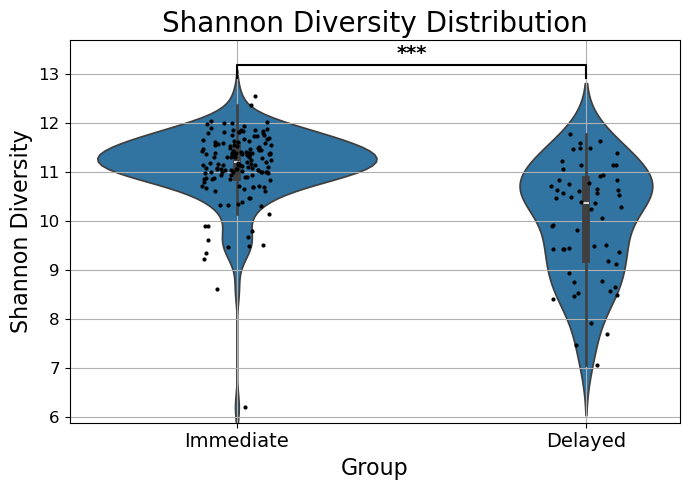

Mann–Whitney U test: U = 7.16e+03, p = 6.495e-12


In [ ]:
# Aggregate diversity scores per sample
fast_div = (
    fast_adata.obs.groupby("sample_id")
    .agg({
        "extraction_time": "first",
        "shannon_junction_aa": "mean",
        "group": "first"
    })
    .reset_index())

slow_div = (
    slow_adata.obs.groupby("sample_id")
    .agg({
        "extraction_time": "first",
        "shannon_junction_aa": "mean",
        "group": "first"
    })
    .reset_index())

diversity_df = pd.concat([fast_div, slow_div], ignore_index=True)
diversity_df = diversity_df.rename(columns={"shannon_junction_aa": "shannon_diversity"})

diversity_df["group"] = diversity_df["group"].replace({
    "fast": "Immediate",
    "slow": "Delayed"
})

order = ["Immediate", "Delayed"]

immediate = diversity_df.loc[
    diversity_df["group"] == "Immediate", "shannon_diversity"
].dropna()

delayed = diversity_df.loc[
    diversity_df["group"] == "Delayed", "shannon_diversity"
].dropna()

u_stat, p_val = mannwhitneyu(immediate, delayed, alternative="two-sided")
p_label = p_to_star(p_val)

plt.figure(figsize=(7, 5))

sns.violinplot(x="group", y="shannon_diversity", data=diversity_df, order=order, inner="box")
sns.stripplot(x="group", y="shannon_diversity", data=diversity_df, order=order, color="black", size=3, jitter=True)

# p-value bracket
y_max = diversity_df["shannon_diversity"].max()
y_min = diversity_df["shannon_diversity"].min()
yrange = y_max - y_min

y = y_max + yrange * 0.06
h = yrange * 0.04
x1, x2 = 0, 1

plt.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", lw=1.5)
plt.text((x1 + x2) / 2, y + h * 1.15, p_label, ha="center", va="bottom", fontsize=14, fontweight="bold")

plt.ylim(y_min - yrange * 0.05, y + h * 3)

plt.title("Shannon Diversity Distribution", fontsize=20)
plt.ylabel("Shannon Diversity", fontsize=16)
plt.xlabel("Group", fontsize=16)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=12)
plt.grid(True)
plt.tight_layout()

save_plot("shannon_diversity_plot.svg", format="svg")
plt.show()

print(f"Mann–Whitney U test: U = {u_stat:.3g}, p = {p_val:.3e}")

Shannon entropy-based diversity metric incorporating both clonotype richness and abundance distribution.

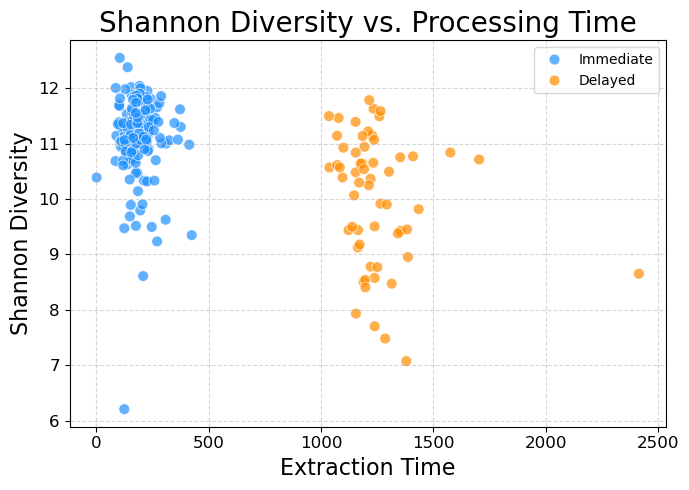

In [ ]:
# Scatter Plot (Time vs Diversity)
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=diversity_df,
    x="extraction_time",
    y="shannon_diversity",
    hue="group",
    palette={"Immediate": "dodgerblue", "Delayed": "darkorange"},
    alpha=0.7,
    s=60
)
plt.title("Shannon Diversity vs. Processing Time", fontsize=20)
plt.xlabel("Extraction Time", fontsize=16)
plt.ylabel("Shannon Diversity", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tick_params(axis="both", labelsize=12)
plt.legend(title="")
plt.tight_layout()

save_plot("shannon_vs_group_plot.svg", format="svg")

plt.show()

## Dominance analysis

How dominant is the top clone per sample?
Lets measure whether slower freezing leads to skewed repertoires dominated by one or few clones.


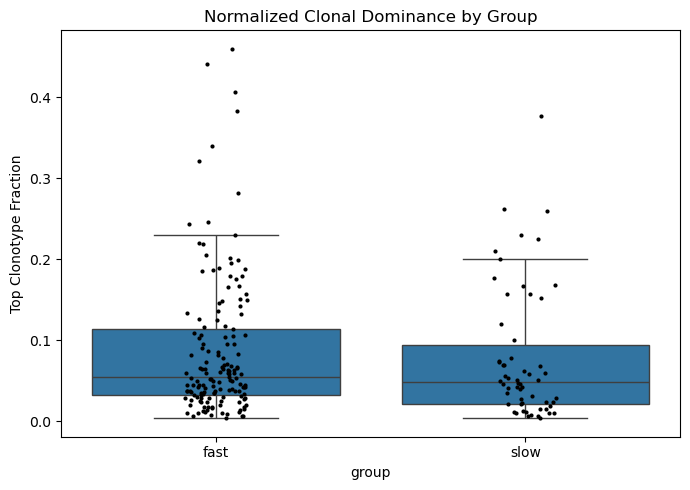

In [20]:
# Top clonotype read count (With group info)
dominance_df = (
    clonotype_df.groupby(["Sample_ID", "aaSeqCDR3", "group", "extraction_time"])["readCount"]
    .sum()
    .reset_index()
    .sort_values(["Sample_ID", "readCount"], ascending=[True, False])
    .groupby("Sample_ID")
    .first()
    .reset_index()
    .rename(columns={"readCount": "top_clone_reads"}))

# Total reads per sample
total_reads_df = (
    clonotype_df.groupby("Sample_ID")["readCount"]
    .sum()
    .reset_index()
    .rename(columns={"readCount": "total_reads"}))

dominance_df = dominance_df.merge(total_reads_df, on="Sample_ID", how="left")
dominance_df["dominance_fraction"] = dominance_df["top_clone_reads"] / dominance_df["total_reads"]

plt.figure(figsize=(7, 5))
sns.boxplot(data=dominance_df, x="group", y="dominance_fraction", showfliers=False)
sns.stripplot(data=dominance_df, x="group", y="dominance_fraction", color="black", size=3, jitter=True)
plt.ylabel("Top Clonotype Fraction")
plt.title("Normalized Clonal Dominance by Group")
plt.tight_layout()
plt.show()

Saving figure to: figures/top_clonotype_dominance_plot.svg


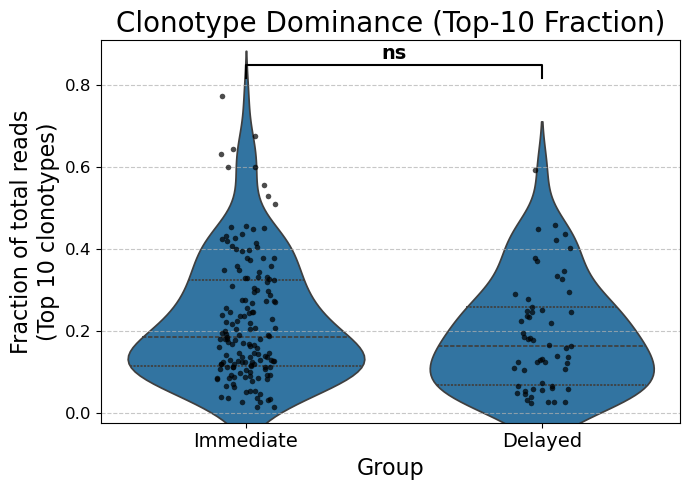

Mann–Whitney U test: U = 5.03e+03, p = 1.365e-01


In [ ]:
top_n = 10
metric_col = f"top{top_n}_fraction"
order = ["Immediate", "Delayed"]

# Compute Top-N clone fraction without groupby.apply
tmp = clonotype_df.sort_values(
    ["Sample_ID", "readCount"],
    ascending=[True, False]
).copy()

tmp["rank_in_sample"] = tmp.groupby("Sample_ID").cumcount() + 1

top_reads = (
    tmp[tmp["rank_in_sample"] <= top_n]
    .groupby("Sample_ID")["readCount"]
    .sum())

total_reads = tmp.groupby("Sample_ID")["readCount"].sum()

sample_meta = (
    tmp.groupby("Sample_ID")
    .agg(
        group=("group", "first"),
        extraction_time=("extraction_time", "first")
    ))

top10_df = sample_meta.copy()
top10_df[metric_col] = top_reads / total_reads
top10_df = top10_df.reset_index()

top10_df["group"] = top10_df["group"].replace({
    "fast": "Immediate",
    "slow": "Delayed"
})

# Mann–Whitney U test
immediate = top10_df.loc[top10_df["group"] == "Immediate", metric_col].dropna()
delayed = top10_df.loc[top10_df["group"] == "Delayed", metric_col].dropna()

u_stat, p_val = mannwhitneyu(immediate, delayed, alternative="two-sided")
p_label = p_to_star(p_val)

plt.figure(figsize=(7, 5))

sns.violinplot(data=top10_df, x="group", y=metric_col, order=order, inner="quartile")
sns.stripplot(data=top10_df, x="group", y=metric_col, order=order, color="black", size=4, jitter=True, alpha=0.7)

# p-value bracket
y_max = top10_df[metric_col].max()
y_min = top10_df[metric_col].min()
yrange = y_max - y_min

y = y_max + yrange * 0.06
h = yrange * 0.04
x1, x2 = 0, 1

plt.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", lw=1.5)

plt.text((x1 + x2) / 2, y + h * 1.15, p_label, ha="center", va="bottom", fontsize=14, fontweight="bold")

plt.ylim(y_min - yrange * 0.05, y + h * 3)

plt.title(f"Clonotype Dominance (Top-{top_n} Fraction)", fontsize=20)
plt.ylabel(f"Fraction of total reads\n(Top {top_n} clonotypes)", fontsize=16)
plt.xlabel("Group", fontsize=16)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=12)
plt.tight_layout()

save_plot("top_clonotype_dominance_plot.svg", format="svg")
plt.show()

print(f"Mann–Whitney U test: U = {u_stat:.3g}, p = {p_val:.3e}")

## Gini Index

Gini index measuring clonotype abundance inequality across the repertoire.
Higher values indicate increased clonal skewing.

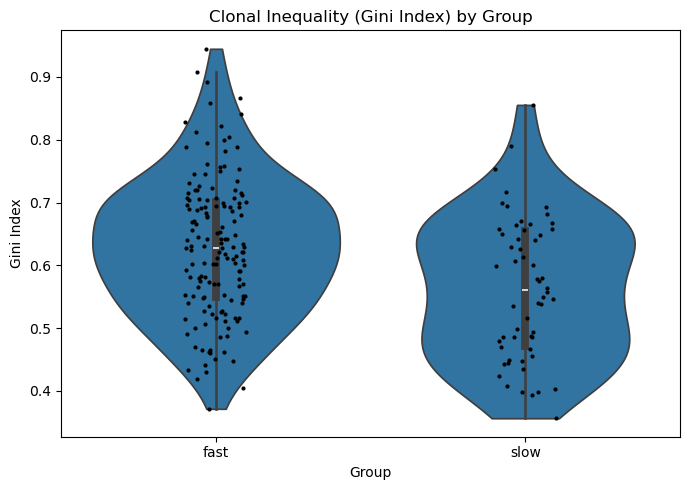

In [ ]:
def gini(array):
    """Compute Gini index (inequality) of an array."""
    array = np.array(array).flatten()
    if len(array) == 0: return 0

    array = np.sort(array)
    n = len(array)
    cumulative = np.cumsum(array)
    # Gini formula
    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n

#  Gini calculation
gini_df = (
    clonotype_df
    .groupby(["Sample_ID", "group", "extraction_time"])["readCount"]
    .apply(gini)
    .reset_index(name="gini_index") 
)

plt.figure(figsize=(7, 5))

sns.violinplot(
    data=gini_df,
    x="group",
    y="gini_index",
    inner="box",
    cut=0,
    legend=False)

sns.stripplot(data=gini_df,x="group",y="gini_index",color="black",
              size=3, jitter=True, dodge=False)

plt.title("Clonal Inequality (Gini Index) by Group")
plt.ylabel("Gini Index")
plt.xlabel("Group")
plt.tight_layout()
plt.show()


## Simpson diversity

Diversity metric weighted toward abundant clonotypes and sensitive to clonal dominance.

In [22]:
# Add Simpson diversity to existing adata objects
ir.tl.alpha_diversity(fast_adata, groupby="sample_id", target_col="junction_aa", metric="simpson")
ir.tl.alpha_diversity(slow_adata, groupby="sample_id", target_col="junction_aa", metric="simpson")

# Extract and merge
fast_simpson = (
    fast_adata.obs.groupby("sample_id")
    .agg({"simpson_junction_aa": "mean", "extraction_time": "first"})
    .reset_index()
)
fast_simpson["group"] = "fast"

slow_simpson = (
    slow_adata.obs.groupby("sample_id")
    .agg({"simpson_junction_aa": "mean", "extraction_time": "first"})
    .reset_index()
)
slow_simpson["group"] = "slow"

simpson_df = pd.concat([fast_simpson, slow_simpson], ignore_index=True)
simpson_df = simpson_df.rename(columns={"simpson_junction_aa": "simpson_diversity"})


Saving figure to: figures/simpson_diversity_plot.svg


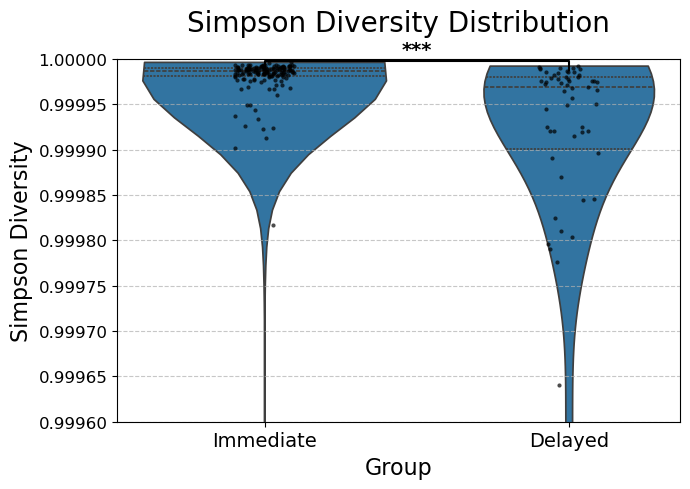

Mann–Whitney U test: U = 7.15e+03, p = 6.971e-12


In [34]:
simpson_df["group"] = simpson_df["group"].replace({
    "fast": "Immediate", 
    "slow": "Delayed"
})

order = ["Immediate", "Delayed"]

immediate = simpson_df.loc[simpson_df["group"] == "Immediate", "simpson_diversity"].dropna()
delayed = simpson_df.loc[simpson_df["group"] == "Delayed", "simpson_diversity"].dropna()

u_stat, p_val = mannwhitneyu(immediate, delayed, alternative="two-sided")
p_label = p_to_star(p_val)

plt.figure(figsize=(7, 5))
ax = sns.violinplot(data=simpson_df, x="group", y="simpson_diversity", order=order, inner="quartile", cut=0)
sns.stripplot(data=simpson_df, x="group", y="simpson_diversity", order=order, color="black", size=3, jitter=True, alpha=0.7)

ax.set_ylim(0.9996, 1.000)
ax.ticklabel_format(style="plain", axis="y", useOffset=False)

# p-value bracket inside restricted y-axis
# bracket in axes coordinates, not data coordinates
x1, x2 = 0, 1
y_ax = 0.97
h_ax = 0.025

ax.plot([x1, x1, x2, x2], [y_ax, y_ax + h_ax, y_ax + h_ax, y_ax],
         transform=ax.get_xaxis_transform(), color="black", lw=1.5, clip_on=False)
ax.text((x1 + x2) / 2, y_ax + h_ax + 0.005, p_label, transform=ax.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=14, fontweight="bold")

plt.ylabel("Simpson Diversity", fontsize=16)
plt.xlabel("Group", fontsize=16)
plt.title("Simpson Diversity Distribution", fontsize=20, pad=20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tick_params(axis="x", labelsize=14)  
plt.tick_params(axis="y", labelsize=12)
plt.subplots_adjust(top=0.82)
plt.tight_layout()

save_plot("simpson_diversity_plot.svg", format="svg")
plt.show()

print(f"Mann–Whitney U test: U = {u_stat:.3g}, p = {p_val:.3e}")

# Figure 3 - Clonotype distribution and gene usage analyses

V/J gene usage analysis across Immediate and Delayed repertoires, including shared clonotypes.

In [43]:
def extract_clean_genes(df, col_map):
    """
    Parses gene columns (e.g., 'TRBV1*01,TRBV1*02'),removes allele info (*01),
    and returns a clean long-format DataFrame.
    """
    processed = df.copy()
    melted_dfs = []
    id_cols = ["Sample_ID", "group", "subset_label", "readCount"]

    for original_col, new_col_name in col_map.items():
        temp = processed[id_cols + [original_col]].dropna(subset=[original_col])
        temp[new_col_name] = temp[original_col].str.split(",")
        temp = temp.explode(new_col_name)
        temp[new_col_name] = temp[new_col_name].str.split("*").str[0]
        temp["gene_type"] = new_col_name
        temp = temp.rename(columns={new_col_name: "gene_name"})
        melted_dfs.append(temp[["Sample_ID", "group", "subset_label", "gene_type", "gene_name", "readCount"]])

    return pd.concat(melted_dfs, ignore_index=True)


In [ ]:
GENE_COLS = {
    "allVHitsWithScore": "V_gene",
    "allDHitsWithScore": "D_gene",
    "allJHitsWithScore": "J_gene"
}

# Use the full clonotype dataframe (No filtering for uniques)
df_all = clonotype_df.copy()

# Map the group names to cleaner labels for the plot
# (Capitalized for better visuals)
df_all["subset_label"] = df_all["group"].map({
    "fast": "Fast (Total)", 
    "slow": "Slow (Total)"
})

# Run the cleaning
long_gene_df = extract_clean_genes(df_all, GENE_COLS)


In [ ]:
# Calculate Usage Frequencies Per Sample

# Group by Sample and Gene to sum read counts Using 'readCount' weights by abundance.
# Using size() weights by diversity.
sample_gene_counts = (
    long_gene_df.groupby(["Sample_ID", "group", "subset_label", "gene_type", "gene_name"])["readCount"]
    .sum()
    .reset_index())

# Calculate Total Reads per Gene Type per Sample for normalization (e.g., Total V-gene usage for Sample1)
sample_totals = (
    sample_gene_counts.groupby(["Sample_ID", "gene_type"])["readCount"]
    .transform("sum"))

# Calculate Frequency (Proportion)
sample_gene_counts["usage_frequency"] = sample_gene_counts["readCount"] / sample_totals

# Plotting 
def plot_top_genes_with_errorbars(data, gene_col, title, top_n=30):
    """
    Plot the top_n Genes, with error bars.
    """
    subset = data[data["gene_type"] == gene_col].copy()

    if top_n is not None:
        gene_order = (subset.groupby("gene_name")["usage_frequency"]
                      .mean().sort_values(ascending=False)
                      .head(top_n).index.tolist())
        plot_data = subset[subset["gene_name"].isin(gene_order)]
    else:
        gene_order = (subset.groupby("gene_name")["usage_frequency"]
                      .mean().sort_values(ascending=False)
                      .index.tolist())
        plot_data = subset.copy()

    plt.figure(figsize=(14, 6))
    plot_data["subset_label"] = plot_data["subset_label"].replace({
        "Fast (Total)": "Immediate (Total)", 
        "Slow (Total)": "Delayed (Total)",
        "fast": "Immediate (Total)", 
        "slow": "Delayed (Total)"
    })
    sns.barplot(
        data=plot_data, x="gene_name", y="usage_frequency", hue="subset_label",
        order=gene_order,
        palette={
            "Immediate (Total)": "dodgerblue", 
            "Delayed (Total)": "darkorange"
        },
        errorbar="se", capsize=0.1, err_kws={'linewidth': 1.5}, alpha=0.9
    )
    plt.title(title, fontsize=20,)
    x_label = f"{gene_col.split('_')[0]} Genes"
    plt.xlabel(f"{x_label}", fontsize=16)
    plt.ylabel("Usage Frequency (Mean ± SEM)", fontsize=16)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    save_plot(f"../colon/fast_slow_only_{gene_col}_usage_plot.svg", format="svg")

    plt.show()

# Generate Plots 
plot_top_genes_with_errorbars(sample_gene_counts, "V_gene", "V-Gene Usage by Processing Group", top_n=30)
plot_top_genes_with_errorbars(sample_gene_counts, "J_gene", "J-Gene Usage by Processing Group", top_n=30)
plot_top_genes_with_errorbars(sample_gene_counts, "D_gene", "D-Gene Usage by Processing Group", top_n=30)

In [ ]:
# Define Subsets

# Get the set of CDR3s for each group
fast_cdr3s = set(clonotype_df[clonotype_df["group"] == "fast"]["aaSeqCDR3"])
slow_cdr3s = set(clonotype_df[clonotype_df["group"] == "slow"]["aaSeqCDR3"])

# Define the 3 sets
shared_cdr3s = fast_cdr3s.intersection(slow_cdr3s)
fast_only_cdr3s = fast_cdr3s - slow_cdr3s
slow_only_cdr3s = slow_cdr3s - fast_cdr3s

# Create a mapping dictionary for fast lookup
cdr3_to_label = {}
for cdr3 in fast_only_cdr3s: cdr3_to_label[cdr3] = "Fast Unique"
for cdr3 in slow_only_cdr3s: cdr3_to_label[cdr3] = "Slow Unique"
for cdr3 in shared_cdr3s:    cdr3_to_label[cdr3] = "Shared"

# Apply the labels to the main dataframe
df_3way = clonotype_df.copy()
df_3way["subset_label"] = df_3way["aaSeqCDR3"].map(cdr3_to_label)

# Filter out rows that might not match 
df_3way = df_3way.dropna(subset=["subset_label"])

# Clean Genes
long_gene_df_3way = extract_clean_genes(df_3way, GENE_COLS)

# Calculate Usage Frequencies Per Sample Per Subset

# Sum reads by Sample & Subset (e.g., Sample_1's usage within "Shared" vs Sample_1's usage within "Fast Unique")
sample_gene_counts_3way = (long_gene_df_3way.groupby(["Sample_ID", "subset_label", "gene_type", "gene_name"])["readCount"]
    .sum().reset_index())

# Calculate Total Reads per "Subset" per Sample (Ensures in-group normalization)
subset_totals = (sample_gene_counts_3way.groupby(["Sample_ID", "subset_label", "gene_type"])["readCount"]
    .transform("sum"))

sample_gene_counts_3way["usage_frequency"] = sample_gene_counts_3way["readCount"] / subset_totals

In [ ]:
# Plotting
def plot_3way_genes_with_errorbars(data, gene_col, title, top_n=30):
    """
    Plots the top N genes with error bars for 3 groups.
    Adapted from the previous function to handle the 3-color palette.
    """
    subset = data[data["gene_type"] == gene_col].copy()
    
    # Identify Top N genes based on global average frequency across all subsets
    if top_n is not None:
        top_genes = (subset.groupby("gene_name")["usage_frequency"]
                      .mean().sort_values(ascending=False)
                      .head(top_n).index.tolist())
        plot_data = subset[subset["gene_name"].isin(top_genes)]
    else:
        top_genes = (subset.groupby("gene_name")["usage_frequency"]
                      .mean().sort_values(ascending=False)
                      .index.tolist())
        plot_data = subset.copy()
    
    plt.figure(figsize=(14, 6))
    plot_data["subset_label"] = plot_data["subset_label"].replace({
        "Shared": "Core",                   
        "Fast Unique": "Immediate Unique",  
        "Slow Unique": "Delayed Unique"    
    })
    sns.barplot(data=plot_data,x="gene_name", y="usage_frequency", hue="subset_label", order=top_genes,
            palette={
            "Immediate Unique": "dodgerblue", 
            "Delayed Unique": "darkorange", 
            "Core": "forestgreen"
            }, errorbar="se", capsize=0.1, err_kws={'linewidth': 1.5},alpha=0.9)
    
    plt.title(title, fontsize=20)
    x_label = f"{gene_col.split('_')[0]} Genes"
    plt.xlabel(x_label, fontsize=16)
    plt.ylabel("Usage Frequency (Mean ± SEM)", fontsize=16)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    save_plot(f"../colon/shared_fast_slow_{gene_col}_usage_plot.svg", format="svg")

    plt.show()


plot_3way_genes_with_errorbars(sample_gene_counts_3way, "V_gene", "V-Gene Usage by Processing Group", top_n=30)
plot_3way_genes_with_errorbars(sample_gene_counts_3way, "J_gene", "J-Gene Usage by Processing Group", top_n=30)
plot_3way_genes_with_errorbars(sample_gene_counts_3way, "D_gene", "D-Gene Usage by Processing Group", top_n=30)

# Figure 4 - Logo Anlysis

In [ ]:
import logomaker

In [ ]:
def pad_sequences(seq_list, pad_char='-', max_length=20):
    # Truncate: Force all sequences to be at most max_length
    trimmed = [s[:max_length] for s in seq_list]
    
    # Pad: Force all sequences to be at least max_length
    padded = [s.ljust(max_length, pad_char) for s in trimmed]

    # Sanity check to prevent Logomaker crashes
    lengths = [len(seq) for seq in padded]
    if len(set(lengths)) > 1:
        raise ValueError("Padding failed — sequences are still of different lengths.")
    
    return padded

# Get the set of CDR3s for each group
fast_cdr3s = set(clonotype_df[clonotype_df["group"] == "fast"]["aaSeqCDR3"])
slow_cdr3s = set(clonotype_df[clonotype_df["group"] == "slow"]["aaSeqCDR3"])

# Define the 3 sets
shared_cdr3s = fast_cdr3s.intersection(slow_cdr3s)
fast_only_cdr3s = fast_cdr3s - slow_cdr3s
slow_only_cdr3s = slow_cdr3s - fast_cdr3s

# Convert sets to lists
common_tcrs_list = list(shared_cdr3s)
private_tcrs_list = list(fast_only_cdr3s.union(slow_only_cdr3s))

# Apply padding 
target_len = 30
common_aligned = pad_sequences(common_tcrs_list, pad_char='-', max_length=target_len)
private_aligned = pad_sequences(private_tcrs_list, pad_char='-', max_length=target_len)

def get_logo_df(seq_list):
    return logomaker.alignment_to_matrix(seq_list, to_type='counts')

common_df = get_logo_df(common_aligned)
private_df = get_logo_df(private_aligned)


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot Common
logomaker.Logo(common_df, color_scheme='chemistry', ax=ax1)
ax1.set_title(f"Survivor TCRs (Shared across groups, n={len(common_tcrs_list)})")
ax1.set_ylabel("Count")

# Plot Private
logomaker.Logo(private_df, color_scheme='chemistry', ax=ax2)
ax2.set_title(f"Private TCRs (Group Specific, n={len(private_tcrs_list)})")
ax2.set_xlabel("CDR3 Position")
ax2.set_ylabel("Count")

plt.tight_layout()

save_plot("logos_survivor_private.svg", format="svg")

plt.show()

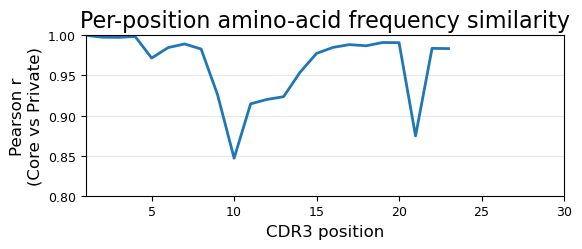

In [ ]:
common_freq  = common_df.div(common_df.sum(axis=1), axis=0)
private_freq = private_df.div(private_df.sum(axis=1), axis=0)

corrs = common_freq.corrwith(private_freq, axis=1)

x = np.arange(1, len(corrs) + 1)  # 1-based positions for readability

fig, ax = plt.subplots(figsize=(6, 2.6))

ax.plot(x, corrs.values, linewidth=2)
ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("CDR3 position", fontsize=12)
ax.set_ylabel("Pearson r\n(Core vs Private)", fontsize=12)
ax.set_title("Per-position amino-acid frequency similarity", fontsize=16)
ax.set_xlim(1, len(corrs))
ax.set_ylim(0.8, 1)  # correlation bounds
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
save_plot("corr_logos_survivor_private.svg", format="svg")

plt.show()


Correlation analysis of sequence-logo position frequencies to quantify similarity between groups.

In [71]:
# Create group-wise sets
fast_seqs = set(clonotype_df[clonotype_df["group"] == "fast"]["aaSeqCDR3"].dropna())
slow_seqs = set(clonotype_df[clonotype_df["group"] == "slow"]["aaSeqCDR3"].dropna())

# Define Private sequences
fast_only = list(fast_seqs - slow_seqs)
slow_only = list(slow_seqs - fast_seqs)

# Align
target_len = 30  
fast_aligned = pad_sequences(fast_only, pad_char='-', max_length=target_len)
slow_aligned = pad_sequences(slow_only, pad_char='-', max_length=target_len)

# Logo df
fast_df = get_logo_df(fast_aligned)
slow_df = get_logo_df(slow_aligned)

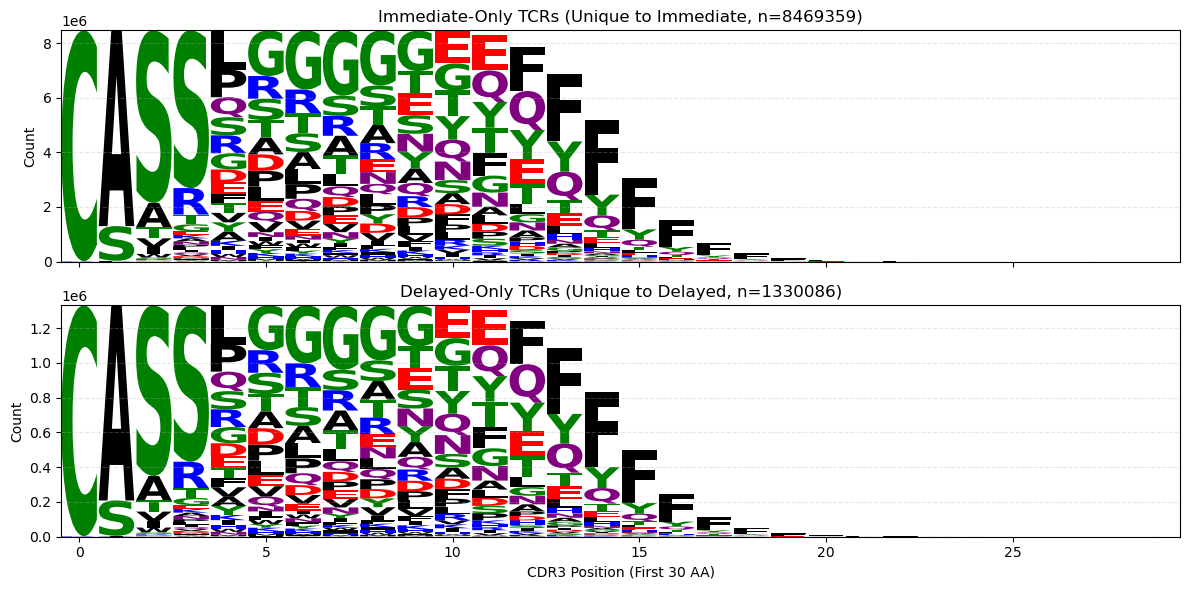

In [ ]:
# Plotting 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot Fast-Only
logomaker.Logo(fast_df, color_scheme='chemistry', ax=ax1)
ax1.set_title(f"Immediate-Only TCRs (Unique to Immediate, n={len(fast_only)})")
ax1.set_ylabel("Count")

# Plot Slow-Only
logomaker.Logo(slow_df, color_scheme='chemistry', ax=ax2)
ax2.set_title(f"Delayed-Only TCRs (Unique to Delayed, n={len(slow_only)})")
ax2.set_xlabel(f"CDR3 Position (First {target_len} AA)")
ax2.set_ylabel("Count")

# Clean styling
for ax in [ax1, ax2]:
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
save_plot("logos_immediate_delayed.svg", format="svg")

plt.show()

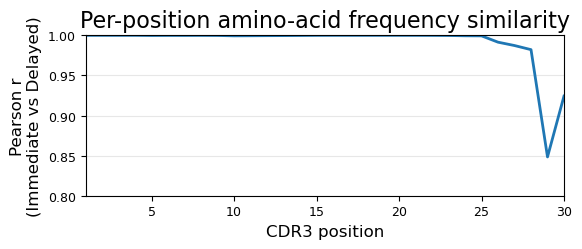

In [ ]:
fast_freq  = fast_df.div(fast_df.sum(axis=1), axis=0)
slow_freq = slow_df.div(slow_df.sum(axis=1), axis=0)

corrs_fast_slow = fast_freq.corrwith(slow_freq, axis=1)

x = np.arange(1, len(corrs_fast_slow) + 1)  # 1-based positions for readability

fig, ax = plt.subplots(figsize=(6, 2.6))

ax.plot(x, corrs_fast_slow.values, linewidth=2)
ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("CDR3 position", fontsize=12)
ax.set_ylabel("Pearson r\n(Immediate vs Delayed)", fontsize=12)
ax.set_title("Per-position amino-acid frequency similarity", fontsize=16)
ax.set_xlim(1, len(corrs_fast_slow))
ax.set_ylim(0.8, 1)  # correlation bounds
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
save_plot("corr_logos_immediate_delayed.svg", format="svg")

plt.show()


# Shared preprocessing - amino-acid-identical clonotypes with nucleotide variation


Identifies amino-acid-identical CDR3β clonotypes shared between Immediate and Delayed repertoires and classifies them by whether their nucleotide sequences are identical or distinct across groups.

In [4]:
# Convergent Recombination Analysis (Shared AA, Distinct NT)
df_unique = clonotype_df[["aaSeqCDR3", "nSeqCDR3", "group"]].dropna().drop_duplicates()

# Pivot: Collect NT sets for each AA, separating immediate/delayed into columns
shared_aa = df_unique.groupby(["aaSeqCDR3", "group"])["nSeqCDR3"].apply(set).unstack().dropna(subset=["fast", "slow"])

# Check if the set of Nucleotides is identical between groups
same_mask = shared_aa["fast"] == shared_aa["slow"]

# Extract lists for downstream analysis
same_nt = shared_aa.index[same_mask].tolist()
diff_nt = shared_aa.index[~same_mask].tolist()
survivors_set = set(same_nt + diff_nt)

# Statistics
total_shared = len(shared_aa)
print(f"Total shared AA sequences (intersection): {total_shared}")
print(f"Identical NT Usage: {len(same_nt)} ({len(same_nt)/total_shared:.1%})")
print(f"Convergent/Different NT Usage: {len(diff_nt)} ({len(diff_nt)/total_shared:.1%})")

Total shared AA sequences (intersection): 522619
Identical NT Usage: 6766 (1.3%)
Convergent/Different NT Usage: 515853 (98.7%)


In [ ]:
# Get sets of common (shared) vs private (group-specific) TCRs
common_tcrs = set(diff_nt)  # appear in both groups, with different NTs
all_aas = set(clonotype_df["aaSeqCDR3"].dropna())
private_tcrs = all_aas - set(same_nt) - set(diff_nt)  # appear in only one group

# Supplementary Figure 1 - CORE clonotype abundance distributions

Descriptive abundance comparison

In [48]:
from scipy.stats import mannwhitneyu

df = clonotype_df.copy()
df["is_core"] = df["aaSeqCDR3"].isin(survivors_set).astype(int)
df["log_readFraction"] = np.log10(df["readFraction"] + 1e-10)

print("Total rows:", len(df))
print("CORE rows:", df["is_core"].sum())
print("Unique clonotypes:", df["aaSeqCDR3"].nunique())
print("CORE clonotypes:", df[df["is_core"] == 1]["aaSeqCDR3"].nunique())

# Build clonotype-level abundance summary
clono_abund = (
    df.groupby("aaSeqCDR3", observed=False)
      .agg(
          is_core=("is_core", "max"),
          median_readFraction=("readFraction", "median")
      )
      .reset_index()
)

n_core_clonotypes = int(clono_abund["is_core"].sum())

# Top-abundant clonotypes group, same size as CORE
top_abundant = (
    clono_abund.sort_values("median_readFraction", ascending=False)
               .head(n_core_clonotypes)
               .copy()
)

top_abundant_set = set(top_abundant["aaSeqCDR3"])

# Percentage of CORE clonotypes inside top-abundant set
pct_core_in_top = 100 * top_abundant["is_core"].mean()
print(f"Top-abundant clonotype group size: {n_core_clonotypes}")
print(f"Percentage of CORE clonotypes in top-abundant group: {pct_core_in_top:.2f}%")

# Create 3-group label for row-level plotting
def assign_group(cdr3, is_core):
    if cdr3 in top_abundant_set:
        return "Top-abundant"
    elif is_core == 1:
        return "CORE"
    else:
        return "Non-CORE"

df["plot_group"] = [
    assign_group(cdr3, core)
    for cdr3, core in zip(df["aaSeqCDR3"], df["is_core"])
]

# Order groups explicitly
group_order = ["Non-CORE", "CORE", "Top-abundant"]

# P-values
core_vals = df.loc[df["plot_group"] == "CORE", "log_readFraction"]
noncore_vals = df.loc[df["plot_group"] == "Non-CORE", "log_readFraction"]
top_vals = df.loc[df["plot_group"] == "Top-abundant", "log_readFraction"]

p_core_vs_non = mannwhitneyu(core_vals, noncore_vals, alternative="two-sided").pvalue
p_top_vs_core = mannwhitneyu(top_vals, core_vals, alternative="two-sided").pvalue
p_top_vs_non = mannwhitneyu(top_vals, noncore_vals, alternative="two-sided").pvalue
print(f"Mann-Whitney p (CORE vs Non-CORE): {p_core_vs_non:.3e}")
print(f"Mann-Whitney p (Top-abundant vs CORE): {p_top_vs_core:.3e}")
print(f"Mann-Whitney p (Top-abundant vs Non-CORE): {p_top_vs_non:.3e}")


Total rows: 15212496
CORE rows: 3942108
Unique clonotypes: 10322064
CORE clonotypes: 522619
Top-abundant clonotype group size: 522619
Percentage of CORE clonotypes in top-abundant group: 4.18%
Mann-Whitney p (CORE vs Non-CORE): 0.000e+00
Mann-Whitney p (Top-abundant vs CORE): 0.000e+00
Mann-Whitney p (Top-abundant vs Non-CORE): 0.000e+00


Saving figure to: figures/core_vs_top_abundance_violin.svg


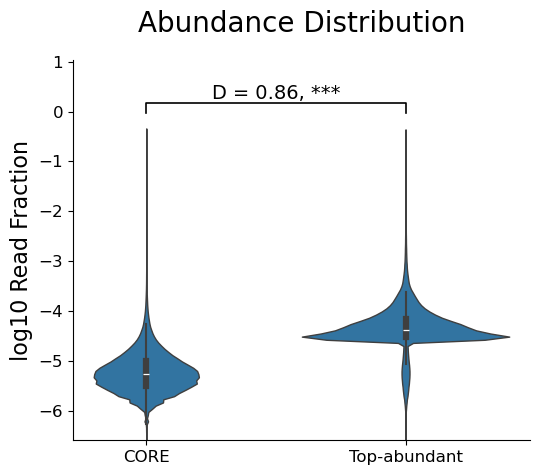

In [ ]:
from scipy.stats import ks_2samp

def add_sig_bracket(ax, x1, x2, y, h, text, fs=12, lw=1.2):
    ax.plot([x1,x1,x2,x2],[y,y+h,y+h,y], lw=lw, c="black", clip_on=False)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom", fontsize=fs)

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

# subset
plot_groups = ["CORE","Top-abundant"]
df_plot = df[df["plot_group"].isin(plot_groups)].copy()

vals_core = df_plot.loc[df_plot["plot_group"]=="CORE","log_readFraction"].dropna().values
vals_top  = df_plot.loc[df_plot["plot_group"]=="Top-abundant","log_readFraction"].dropna().values

ks = ks_2samp(vals_core, vals_top, alternative="two-sided", method="asymp")
label = f"D = {ks.statistic:.2f}, {p_to_stars(ks.pvalue)}"

fig, ax = plt.subplots(figsize=(5.5,5))
sns.violinplot(data=df_plot, x="plot_group", y="log_readFraction",
               order=plot_groups, inner="box", cut=0, linewidth=1, ax=ax)

ax.set_title("Abundance Distribution", fontsize=20, pad=20)
ax.set_ylabel("log10 Read Fraction", fontsize=16)
ax.set_xlabel("")
ax.tick_params(axis="both", labelsize=12)
sns.despine(ax=ax)

ymin, ymax = df_plot["log_readFraction"].min(), df_plot["log_readFraction"].max()
yr = ymax - ymin
ax.set_ylim(ymin, ymax + 0.22*yr)

add_sig_bracket(ax, 0, 1, ymax + 0.05*yr, 0.03*yr, label, fs=14)

plt.tight_layout(rect=[0,0,1,0.97])
save_plot("core_vs_top_abundance_violin.svg", format='svg')
plt.show()

# Figure 5 - Synonymous codon variation in CORE clonotypes

In [12]:
from collections import Counter, defaultdict
import itertools

# Filter for shared AAs with different NTs and group by AA
nt_groups = (
    clonotype_df[clonotype_df["aaSeqCDR3"].isin(diff_nt)]
    [["aaSeqCDR3", "nSeqCDR3"]]
    .dropna()
    .drop_duplicates()
    .groupby("aaSeqCDR3")["nSeqCDR3"]
    .apply(list))

mutation_counts = defaultdict(int)     
aa_pos_mutations = defaultdict(int)     
aa_pos_depth = defaultdict(int)        
total_codons_compared = 0

for aa_seq, nt_list in nt_groups.items():
    valid_nts = [nt for nt in nt_list if len(nt) == len(aa_seq) * 3]
    if len(valid_nts) < 2: continue

    for nt1, nt2 in itertools.combinations(valid_nts, 2):
        
        # Track "Depth": This AA position existed in this comparison
        for aa_idx in range(len(aa_seq)):
            aa_pos_depth[aa_idx] += 1
            
        total_codons_compared += len(aa_seq)

        # Count mismatches by position
        for k in range(len(nt1)):
            if nt1[k] != nt2[k]:
                base_pos = (k % 3) + 1  # 1, 2, or 3
                aa_idx = k // 3         # 0, 1, 2...
                mutation_counts[base_pos] += 1
                aa_pos_mutations[aa_idx] += 1

# Compute Frequencies (Normalization)
# Normalize by the actual number of times we looked at that position
base_freqs = {k: v / total_codons_compared for k, v in mutation_counts.items()}
aa_freqs = {k + 1: aa_pos_mutations[k] / aa_pos_depth[k] for k in aa_pos_mutations}



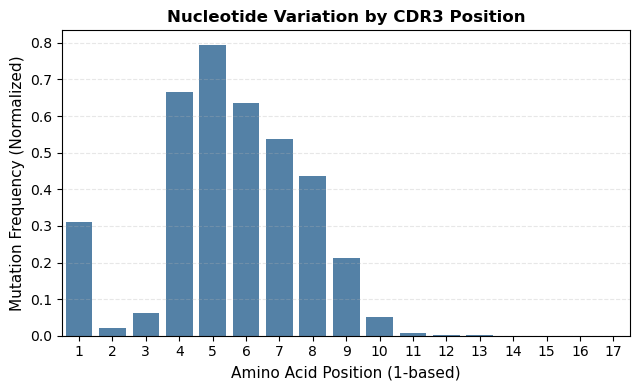

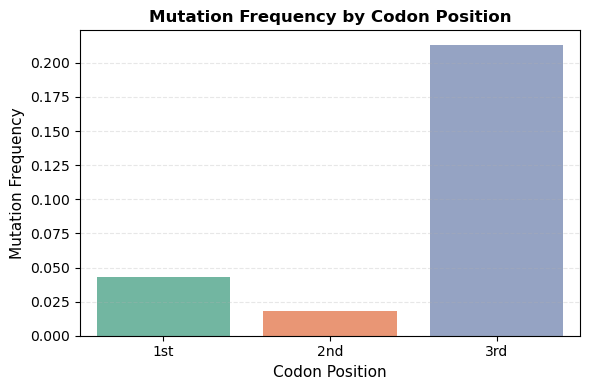

In [ ]:
plt.figure(figsize=(6.5, 4))

sns.barplot(
    x=list(aa_freqs.keys()),
    y=list(aa_freqs.values()),
    color="steelblue"
)

plt.title("Nucleotide Variation by CDR3 Position", fontsize=12, fontweight="bold")
plt.xlabel("Amino Acid Position (1-based)", fontsize=11)
plt.ylabel("Mutation Frequency (Normalized)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))

labels = ["1st", "2nd", "3rd"]
freqs = [base_freqs.get(i, 0) for i in [1, 2, 3]]

sns.barplot(
    x=labels,
    y=freqs,
    hue=labels,        
    palette="Set2",
    legend=False)

plt.title("Mutation Frequency by Codon Position", fontsize=16, fontweight="bold")
plt.xlabel("Codon Position", fontsize=12)
plt.ylabel("Mutation Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

save_plot("bases_mutation_frequency.svg", format="svg")

plt.show()


This analysis evaluates nucleotide-level variation among amino-acid-identical CDR3β clonotypes shared between the Immediate and Delayed cohorts.

For each shared amino-acid clonotype, nucleotide sequences were separated by cohort and compared exclusively across cohorts (Immediate vs Delayed), excluding within-cohort comparisons.

Substitutions were directionally anchored as:

- From: nucleotide observed in the Immediate cohort
- To: nucleotide observed in the Delayed cohort

Substitution frequencies were analyzed by:
- codon base position,
- amino-acid position along the CDR3,
- and substitution composition (base→base).

**Normalization**

Substitution counts were normalized by the frequency of the originating nucleotide in the Immediate cohort:

$\displaystyle \text{Normalized}(b_{\text{Immediate}} \rightarrow b_{\text{Delayed}}) = \frac{\#(b_{\text{Immediate}} \rightarrow b_{\text{Delayed}})}{\#(b_{\text{Immediate}}\ \text{observed in Immediate})}$

Identical nucleotide positions (e.g., A→A) were excluded from substitution counts.

In [7]:
from collections import Counter

# Cohort-anchored nucleotide differences in shared AA clonotypes
# Fast -> Slow direction is defined by cohort 

BASES = ["A", "C", "G", "T"]
FAST_LABEL = "fast"
SLOW_LABEL = "slow"

# Keep group so comparisons are Fast vs Slow within each AA clonotype
df = clonotype_df.loc[
    clonotype_df["aaSeqCDR3"].isin(diff_nt),
    ["aaSeqCDR3", "nSeqCDR3", "group"]
].dropna().drop_duplicates()

# enforce valid bases only
df = df[df["nSeqCDR3"].str.fullmatch(r"[ACGT]+")]

# Group by AA clonotype, keep cohort-specific NT variants
groups = df.groupby("aaSeqCDR3")

aa_pos_counter = Counter()            # 1-based codon/AA position
codon_base_counter = Counter()        # 1,2,3 base in codon
nt_substitution_counter = Counter()   # (base_fast, base_slow)
base_occurrence_counter = Counter()   # background counts of bases in FAST ("from" side)

n_groups_used = 0

for aa_seq, g in groups:
    codon_len = len(aa_seq)
    nt_len_expected = codon_len * 3

    # Split NT variants by cohort, keep in-frame length only
    fast_nts = g.loc[g["group"] == FAST_LABEL, "nSeqCDR3"].tolist()
    slow_nts = g.loc[g["group"] == SLOW_LABEL, "nSeqCDR3"].tolist()

    fast_nts = [nt for nt in fast_nts if len(nt) == nt_len_expected]
    slow_nts = [nt for nt in slow_nts if len(nt) == nt_len_expected]

    # Need at least one NT realization in each cohort to anchor Fast -> Slow
    if len(fast_nts) == 0 or len(slow_nts) == 0:
        continue

    n_groups_used += 1

    # Convert to character matrices
    mat_fast = np.array([list(s) for s in fast_nts], dtype="U1")  # (m, L)
    mat_slow = np.array([list(s) for s in slow_nts], dtype="U1")  # (n, L)

    m, L = mat_fast.shape
    n = mat_slow.shape[0]

    # Create all Fast-vs-Slow pair rows (m*n, L) without nested Python loops
    # Pair indexing: (fast_i, slow_j) for all i,j
    fast_idx = np.repeat(np.arange(m), n)
    slow_idx = np.tile(np.arange(n), m)

    seqs_fast = mat_fast[fast_idx]    # (m*n, L)
    seqs_slow = mat_slow[slow_idx]    # (m*n, L)

    # Background base counts on the "from" side:
    # Count bases in Fast sequences, expanded by number of Slow partners
    u, c = np.unique(seqs_fast, return_counts=True)
    base_occurrence_counter.update(dict(zip(u, c)))

    # Find mismatches
    diff_mask = (seqs_fast != seqs_slow)
    if not np.any(diff_mask):
        continue

    # Indices of mismatch positions (row idx not needed, only column positions)
    _, col_indices = np.where(diff_mask)

    # Update AA/codon index and codon base position counters
    aa_indices = (col_indices // 3) + 1          # 1-based codon/AA position
    base_positions = (col_indices % 3) + 1       # 1,2,3 within codon

    aa_pos_counter.update(aa_indices.tolist())
    codon_base_counter.update(base_positions.tolist())

    # Update oriented substitutions: Fast base -> Slow base, only at mismatches
    b_fast = seqs_fast[diff_mask]
    b_slow = seqs_slow[diff_mask]
    nt_substitution_counter.update(zip(b_fast.tolist(), b_slow.tolist()))

print(f"Used {n_groups_used} AA clonotypes with Fast+Slow NT realizations (anchored comparisons).")


Used 513661 AA clonotypes with Fast+Slow NT realizations (anchored comparisons).


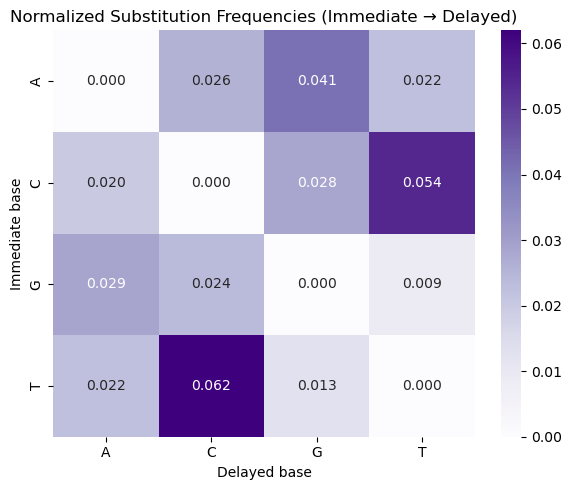

In [ ]:
# Build normalized heatmap
heatmap_norm = pd.DataFrame(0.0, index=BASES, columns=BASES)

for (b1, b2), count in nt_substitution_counter.items():
    if b1 not in BASES or b2 not in BASES:
        continue
    denom = base_occurrence_counter.get(b1, 0)
    if denom > 0:
        heatmap_norm.loc[b1, b2] = count / denom


plt.figure(figsize=(6, 5))
sns.heatmap(heatmap_norm, annot=True, fmt=".3f", cmap="Purples")
plt.title("Normalized Substitution Frequencies (Immediate → Delayed)")
plt.xlabel("Delayed base")
plt.ylabel("Immediate base")
plt.tight_layout()

save_plot("normalized_substitution_freq_all.svg", format="svg")
plt.show()


In [ ]:
# derived summaries for plotting elsewhere
# Codon base position frequencies normalized by total mismatches (simple, descriptive)
total_mismatches = sum(codon_base_counter.values())
codon_base_freqs = {pos: codon_base_counter[pos] / total_mismatches for pos in [1, 2, 3]} if total_mismatches else {1: 0, 2: 0, 3: 0}

# AA-position frequencies normalized by total mismatches
aa_pos_freqs = {pos: aa_pos_counter[pos] / total_mismatches for pos in sorted(aa_pos_counter)} if total_mismatches else {}


In [ ]:
BASES = ["A", "C", "G", "T"]
FAST_LABEL = "fast"
SLOW_LABEL = "slow"

#  Counters, stratified by codon base position (1,2,3) 
substitution_by_position = {1: Counter(), 2: Counter(), 3: Counter()}     # (fast_base, slow_base) counts
base_occurrence_by_position = {1: Counter(), 2: Counter(), 3: Counter()}  # background "from" bases in Fast, per position

#  Prepare data: must include group to anchor direction 
df = clonotype_df.loc[
    clonotype_df["aaSeqCDR3"].isin(diff_nt),
    ["aaSeqCDR3", "nSeqCDR3", "group"]
].dropna().drop_duplicates()

# keep only canonical DNA bases
df = df[df["nSeqCDR3"].str.fullmatch(r"[ACGT]+")]

for aa_seq, g in df.groupby("aaSeqCDR3"):
    codon_len = len(aa_seq)
    nt_len = codon_len * 3

    fast_nts = g.loc[g["group"] == FAST_LABEL, "nSeqCDR3"].tolist()
    slow_nts = g.loc[g["group"] == SLOW_LABEL, "nSeqCDR3"].tolist()

    fast_nts = [nt for nt in fast_nts if len(nt) == nt_len]
    slow_nts = [nt for nt in slow_nts if len(nt) == nt_len]

    if not fast_nts or not slow_nts:
        continue

    mat_fast = np.array([list(s) for s in fast_nts], dtype="U1")  # (m, L)
    mat_slow = np.array([list(s) for s in slow_nts], dtype="U1")  # (n, L)

    m, L = mat_fast.shape
    n = mat_slow.shape[0]

    # all Fast-vs-Slow pairs
    fast_idx = np.repeat(np.arange(m), n)
    slow_idx = np.tile(np.arange(n), m)

    seqs_fast = mat_fast[fast_idx]  # (m*n, L)
    seqs_slow = mat_slow[slow_idx]  # (m*n, L)

    # background base exposure per codon base position (FAST side only) 
    # positions 0,1,2 correspond to codon base 1,2,3, repeated every 3 bases
    col_mod = np.arange(L) % 3  # 0/1/2 for each column
    for pos in (1, 2, 3):
        cols = np.where(col_mod == (pos - 1))[0]
        u, c = np.unique(seqs_fast[:, cols], return_counts=True)
        base_occurrence_by_position[pos].update(dict(zip(u, c)))

    # mismatches and substitutions, stratified by codon base position
    diff_mask = (seqs_fast != seqs_slow)
    if not np.any(diff_mask):
        continue

    mismatch_cols = np.where(diff_mask)[1]
    mismatch_fast = seqs_fast[diff_mask]
    mismatch_slow = seqs_slow[diff_mask]

    mismatch_pos = (mismatch_cols % 3) + 1  # 1/2/3

    # update counters per position
    for pos in (1, 2, 3):
        sel = (mismatch_pos == pos)
        if not np.any(sel):
            continue
        substitution_by_position[pos].update(zip(mismatch_fast[sel].tolist(), mismatch_slow[sel].tolist()))



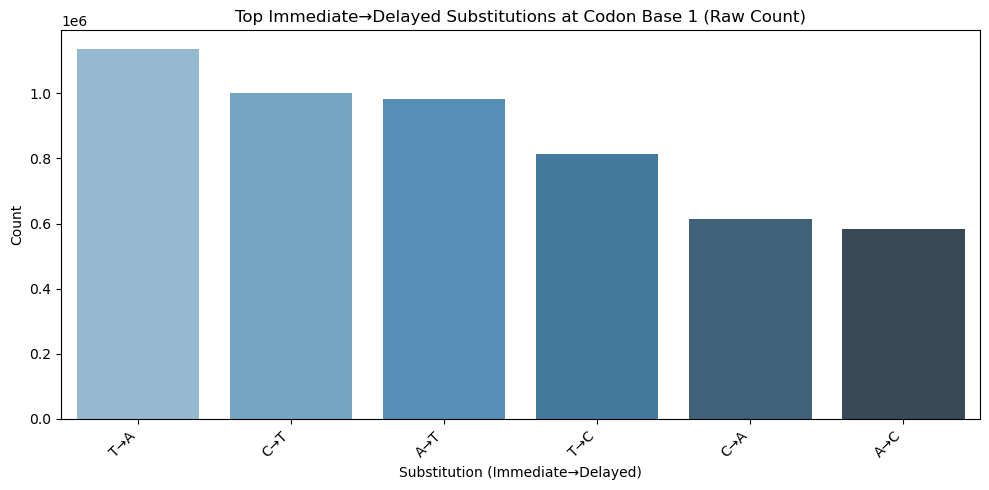

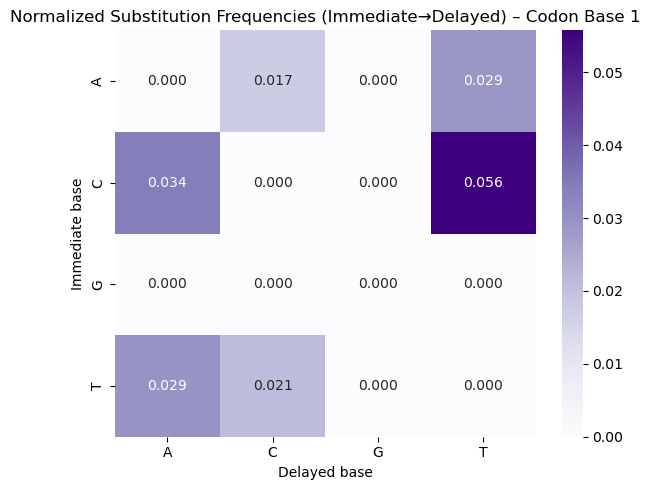

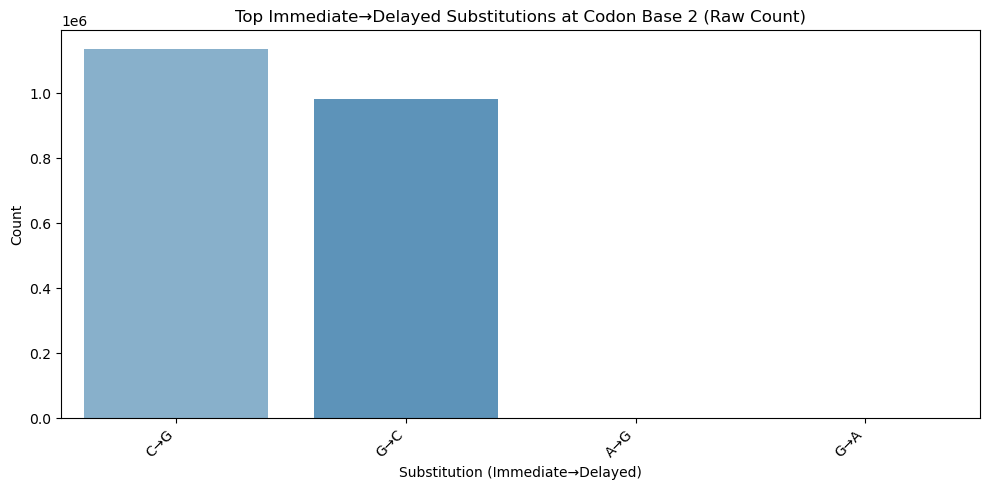

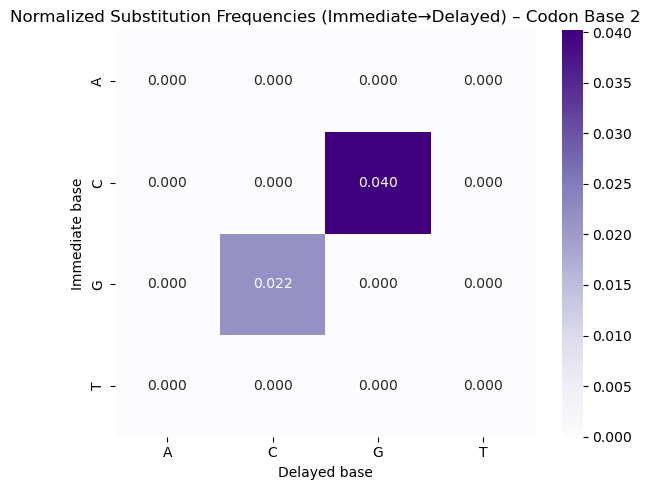

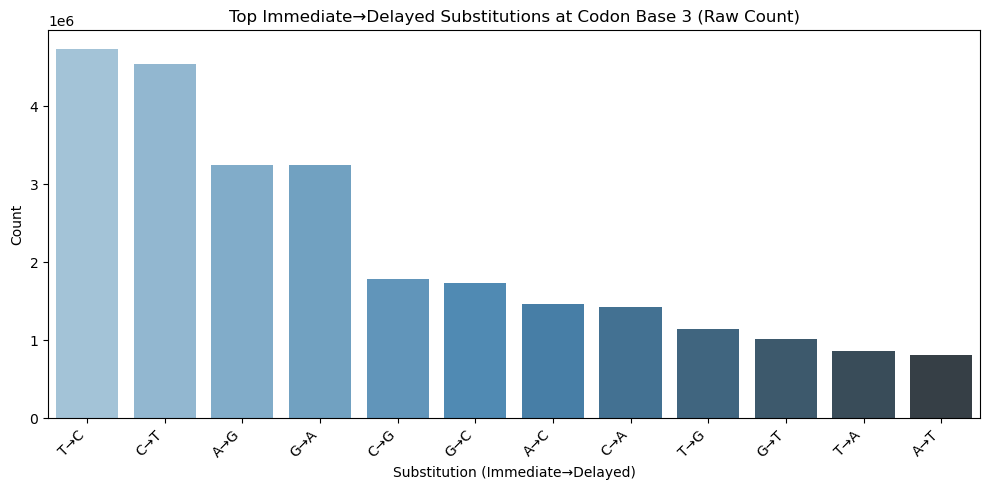

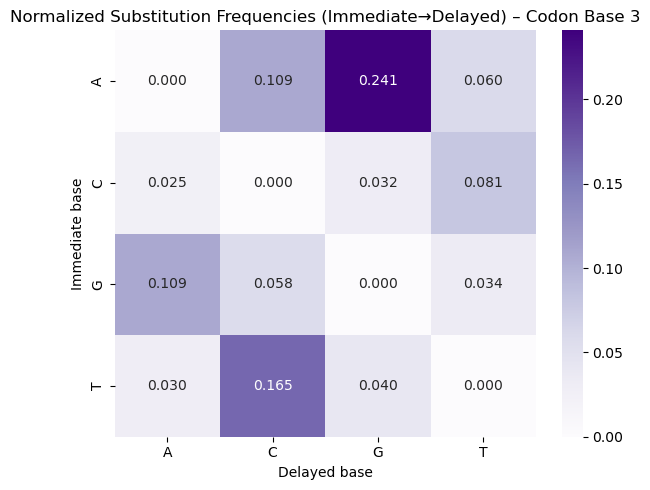

In [ ]:
# Plot per codon base position
for pos in (1, 2, 3):
    sub_counter = substitution_by_position[pos]
    base_counter = base_occurrence_by_position[pos]

    # Build a table with raw + normalized Fast->Slow substitution frequencies
    rows = []
    for (b_fast, b_slow), count in sub_counter.items():
        if (b_fast not in BASES) or (b_slow not in BASES):
            continue
        denom = base_counter.get(b_fast, 0)
        if denom == 0:
            continue
        rows.append((b_fast, b_slow, count, count / denom))

    sub_df = pd.DataFrame(rows, columns=["from", "to", "count", "normalized"])
    if sub_df.empty:
        print(f"[Codon base {pos}] No substitutions to plot.")
        continue

    sub_df["substitution"] = sub_df["from"] + "→" + sub_df["to"]

    # --- Barplot: top substitutions by raw count (Fast->Slow, codon base pos) ---
    top_df = sub_df.sort_values("count", ascending=False).head(15)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_df, x="substitution", y="count", hue="substitution",
                palette="Blues_d",legend=False)

    plt.title(f"Top Immediate→Delayed Substitutions at Codon Base {pos} (Raw Count)")
    plt.xlabel("Substitution (Immediate→Delayed)")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Heatmap: normalized Fast->Slow substitution frequencies 
    heatmap_df = pd.DataFrame(0.0, index=BASES, columns=BASES)
    for _, r in sub_df.iterrows():
        heatmap_df.loc[r["from"], r["to"]] = r["normalized"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="Purples")
    plt.title(f"Normalized Substitution Frequencies (Immediate→Delayed) – Codon Base {pos}")
    plt.xlabel("Delayed base")
    plt.ylabel("Immediate base")
    plt.tight_layout()
    
    save_plot(f"normalized_substitution_freq_{pos}.svg", format="svg")

    plt.show()


# Figure 6 - Comparative V/J gene usage analysis of CORE and group-unique clonotypes

avg_nt_diversity = sum of all unique TCR appearances divided by the number of unique TCRs for that v-gene.

In [85]:
# Filter to relevant rows and columns in one pass
df_v = (
    clonotype_df.loc[clonotype_df["aaSeqCDR3"].isin(diff_nt), 
                     ["aaSeqCDR3", "nSeqCDR3", "allVHitsWithScore"]]
    .dropna()
    .drop_duplicates()  # Removes exact duplicates
    .copy())

# Extract Gene Name
df_v["V_gene"] = (
    df_v["allVHitsWithScore"]
    .str.split(",").str[0]
    .str.split("*").str[0])

# Calculate Statistics
# First, count NT variants per (Gene, AA) pair
# Second, aggregate by Gene to get Summary Stats
v_summary = (
    df_v.groupby(["V_gene", "aaSeqCDR3"])["nSeqCDR3"]
    .nunique()
    .reset_index(name="nt_variants")       #  NT count per clonotype
    .groupby("V_gene")
    .agg(
        n_public_TCRs=("aaSeqCDR3", "nunique"),  # X-axis: How many shared AA sequences?
        avg_nt_diversity=("nt_variants", "mean") # Y-axis: How many NTs per AA on average?
    )
    .reset_index()
    .sort_values("n_public_TCRs", ascending=False))


In [87]:
# Identify Shared AA Sequences-
fast_aas = set(clonotype_df.loc[clonotype_df["group"] == "fast", "aaSeqCDR3"].dropna())
slow_aas = set(clonotype_df.loc[clonotype_df["group"] == "slow", "aaSeqCDR3"].dropna())

# Intersection = The Shared Pool to Exclude
shared_aas = fast_aas.intersection(slow_aas)

print(f"Excluding {len(shared_aas)} shared AA sequences.")

# Filter for UNIQUE TCRs
# Keep rows where AA is NOT in the shared list
unique_tcr_df = (
    clonotype_df[~clonotype_df["aaSeqCDR3"].isin(shared_aas)]
    [["aaSeqCDR3", "nSeqCDR3", "allVHitsWithScore"]]
    .dropna()
    .drop_duplicates()
    .copy())

# Clean V-Genes
unique_tcr_df["V_gene"] = (
    unique_tcr_df["allVHitsWithScore"]
    .str.split(",").str[0]  
    .str.split("*").str[0]  )

# Aggregate Statistics
# Count distinct NTs per (Gene, AA)
diversity_unique = (
    unique_tcr_df.groupby(["V_gene", "aaSeqCDR3"])["nSeqCDR3"]
    .nunique()
    .reset_index(name="nt_variants"))

# Summarize by V-Gene
v_summary_unique = (
    diversity_unique.groupby("V_gene")
    .agg(
        n_unique_TCRs=("aaSeqCDR3", "nunique"),  # X-axis
        avg_nt_diversity=("nt_variants", "mean") # Y-axis
    )
    .reset_index()
    .sort_values("n_unique_TCRs", ascending=False))


Excluding 522619 shared AA sequences.


Combine Plots and match Gene legend

In [ ]:
def plot_gene_scatter_stacked(
    df_top, df_bottom,
    gene_col: str,
    x_top: str, x_bottom: str,
    y: str = "avg_nt_diversity",
    title_top: str = "",
    title_bottom: str = "",
    xlabel: str = "Number of Unique CDR3 Clonotypes per Gene",
    ylabel: str = "Average # of NT Variants per TCR",
    out_svg: str | None = None,
    figsize=(12, 14),
    base_font=10,
    tick_font=10,
    title_font=22,
    label_font=16,
    legend_title: str = "Gene",
    legend_cols: int | None = None,
    legend_y: float = -0.05,
    bottom_margin: float = 0.25,
    match_y: bool = True,
    y_min: float = 0.95,
    y_pad: float = 0.10,
    palette_name: str = "tab20",
):
    plt.rcParams.update({"font.size": base_font})

    # stable gene->color mapping across both plots
    genes = sorted(set(df_top[gene_col]).union(set(df_bottom[gene_col])))
    palette = dict(zip(genes, sns.color_palette(palette_name, n_colors=len(genes))))

    fig, axes = plt.subplots(2, 1, figsize=figsize, constrained_layout=False)

    # top
    sns.scatterplot(
        data=df_top, x=x_top, y=y, hue=gene_col,
        palette=palette, s=100, alpha=0.8, ax=axes[0], legend=False
    )
    axes[0].set_title(title_top, fontsize=title_font)
    axes[0].set_xlabel("")
    axes[0].set_ylabel(ylabel, fontsize=label_font)
    axes[0].tick_params(axis="both", labelsize=tick_font)
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # bottom 
    sns.scatterplot(
        data=df_bottom, x=x_bottom, y=y, hue=gene_col,
        palette=palette, s=100, alpha=0.8, ax=axes[1], legend=False
    )
    axes[1].set_title(title_bottom, fontsize=title_font)
    axes[1].set_xlabel(xlabel, fontsize=label_font)
    axes[1].set_ylabel(ylabel, fontsize=label_font)
    axes[1].tick_params(axis="both", labelsize=tick_font)
    axes[1].grid(True, linestyle="--", alpha=0.5)

    # match y-lims across panels (optional)
    if match_y:
        max_y = max(df_top[y].max(), df_bottom[y].max())
        axes[0].set_ylim(y_min, max_y + y_pad)
        axes[1].set_ylim(y_min, max_y + y_pad)

    # one legend under the bottom plot
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
                   markerfacecolor=palette[g], markeredgecolor=palette[g], label=g)
        for g in genes
    ]
    if legend_cols is None:
        legend_cols = min(10, max(4, len(genes) // 3))

    fig.legend(
        handles=handles, labels=genes, title=legend_title,
        loc="lower center", bbox_to_anchor=(0.5, legend_y),
        ncol=legend_cols, frameon=False,
        fontsize=11, title_fontsize=13,
    )

    fig.subplots_adjust(hspace=0.17, bottom=bottom_margin)

    if out_svg is not None:
        save_plot(out_svg, format="svg", bbox_inches="tight")

    plt.show()


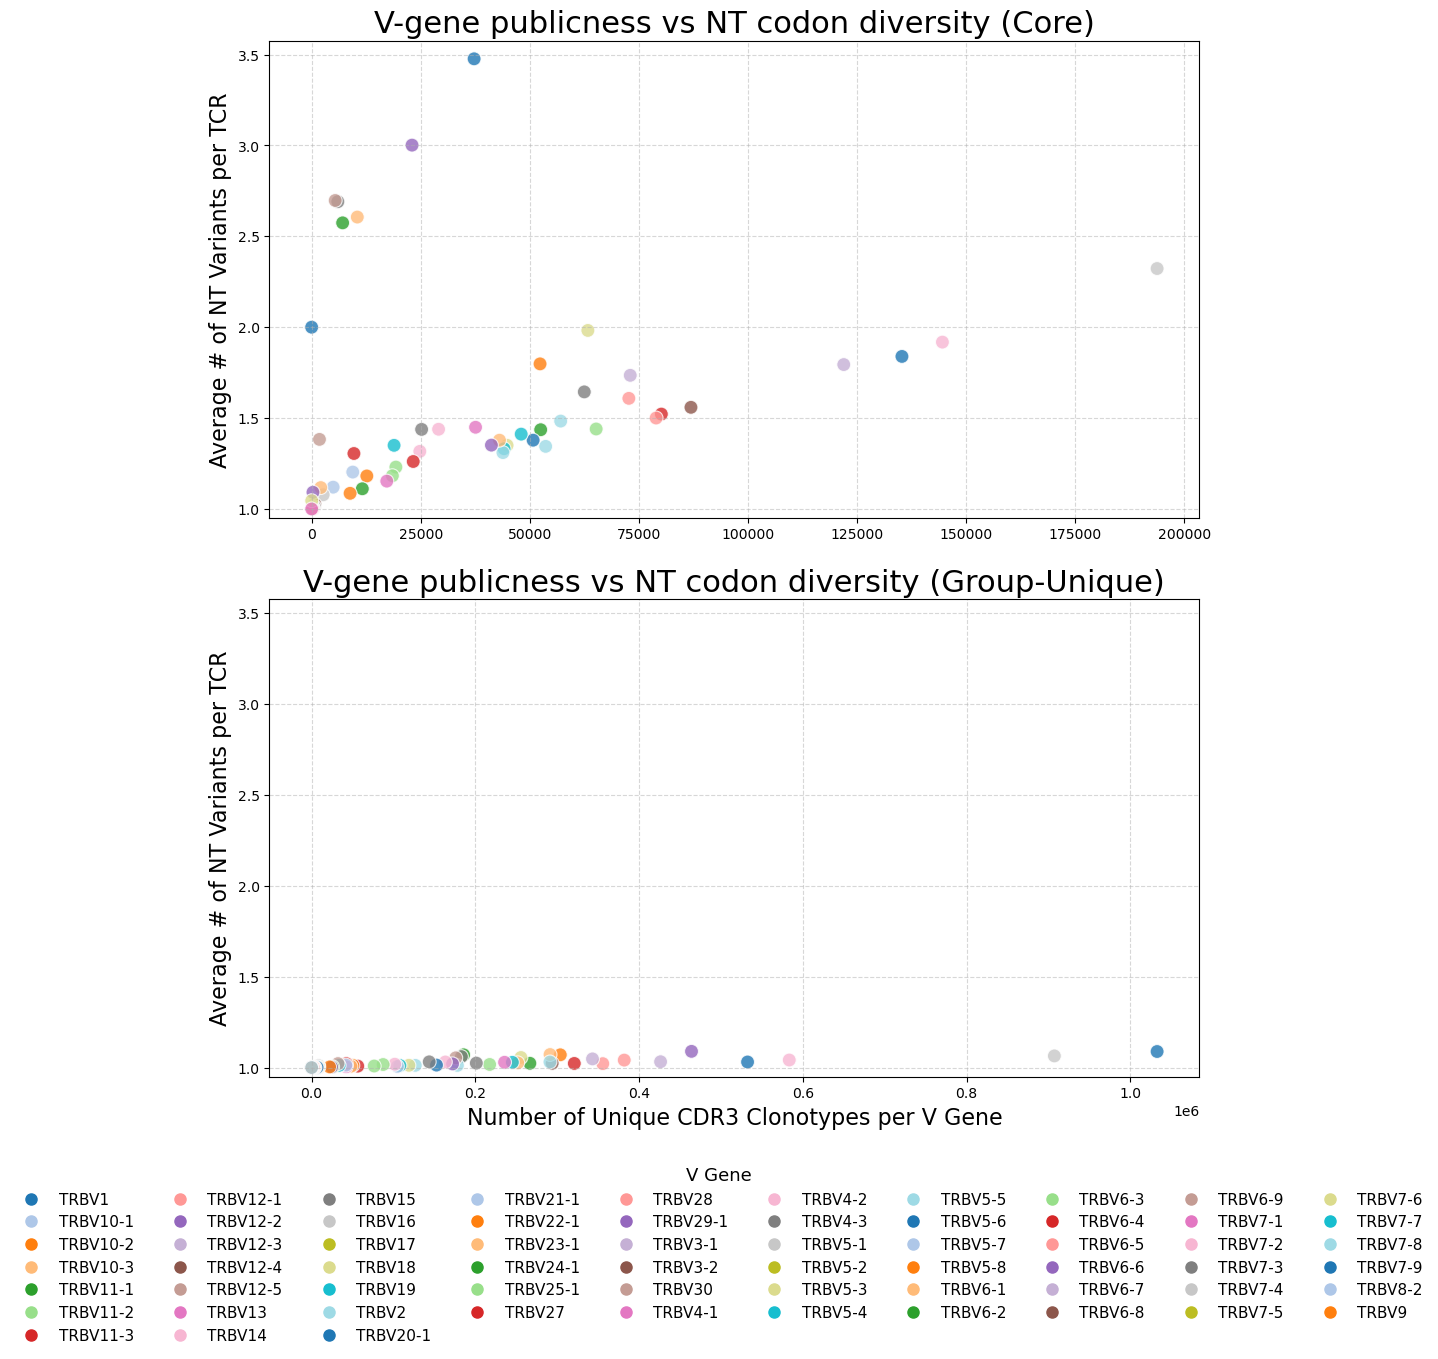

In [112]:
# V gene (compact call)
plot_gene_scatter_stacked(
    df_top=v_summary,
    df_bottom=v_summary_unique,
    gene_col="V_gene",
    x_top="n_public_TCRs",
    x_bottom="n_unique_TCRs",
    title_top="V-gene publicness vs NT codon diversity (Core)",
    title_bottom="V-gene publicness vs NT codon diversity (Group-Unique)",
    xlabel="Number of Unique CDR3 Clonotypes per V Gene",
    legend_title="V Gene",
    out_svg="../colon/V_gene_usage_shared_unique_stacked.svg",
    legend_y=-0.06,
    bottom_margin=0.14,
)


J Gene Usage

In [ ]:
# Filter to relevant rows and columns in one pass (J genes)
df_j = (
    clonotype_df.loc[clonotype_df["aaSeqCDR3"].isin(diff_nt),
                     ["aaSeqCDR3", "nSeqCDR3", "allJHitsWithScore"]]
    .dropna().drop_duplicates().copy())

# Extract J gene name (first hit, drop allele)
df_j["J_gene"] = (
    df_j["allJHitsWithScore"]
    .str.split(",").str[0]
    .str.split("*").str[0]
)

# Summary statistics per J gene
j_summary = (
    df_j.groupby(["J_gene", "aaSeqCDR3"])["nSeqCDR3"]
    .nunique()
    .reset_index(name="nt_variants")          # NT count per clonotype
    .groupby("J_gene")
    .agg(
        n_public_TCRs=("aaSeqCDR3", "nunique"),   # X-axis: shared AA clonotypes per gene
        avg_nt_diversity=("nt_variants", "mean")  # Y-axis: NT variants per AA (mean)
    )
    .reset_index()
    .sort_values("n_public_TCRs", ascending=False)
)


In [ ]:
# Identify Shared AA Sequences
fast_aas = set(clonotype_df.loc[clonotype_df["group"] == "fast", "aaSeqCDR3"].dropna())
slow_aas = set(clonotype_df.loc[clonotype_df["group"] == "slow", "aaSeqCDR3"].dropna())

shared_aas = fast_aas.intersection(slow_aas)
print(f"Excluding {len(shared_aas)} shared AA sequences.")

# Filter for UNIQUE TCRs (non-shared AA clonotypes)
unique_tcr_df = (
    clonotype_df.loc[~clonotype_df["aaSeqCDR3"].isin(shared_aas),
                     ["aaSeqCDR3", "nSeqCDR3", "allJHitsWithScore"]]
    .dropna().drop_duplicates().copy())

# Clean J-Genes (first hit, drop allele)
unique_tcr_df["J_gene"] = (
    unique_tcr_df["allJHitsWithScore"]
    .str.split(",").str[0]
    .str.split("*").str[0])

# Count distinct NTs per (J_gene, AA)
diversity_unique_j = (
    unique_tcr_df.groupby(["J_gene", "aaSeqCDR3"])["nSeqCDR3"]
    .nunique()
    .reset_index(name="nt_variants"))

# Summarize by J-Gene
j_summary_unique = (
    diversity_unique_j.groupby("J_gene")
    .agg(
        n_unique_TCRs=("aaSeqCDR3", "nunique"),   # X-axis
        avg_nt_diversity=("nt_variants", "mean")  # Y-axis
    )
    .reset_index().sort_values("n_unique_TCRs", ascending=False))


Excluding 522619 shared AA sequences.


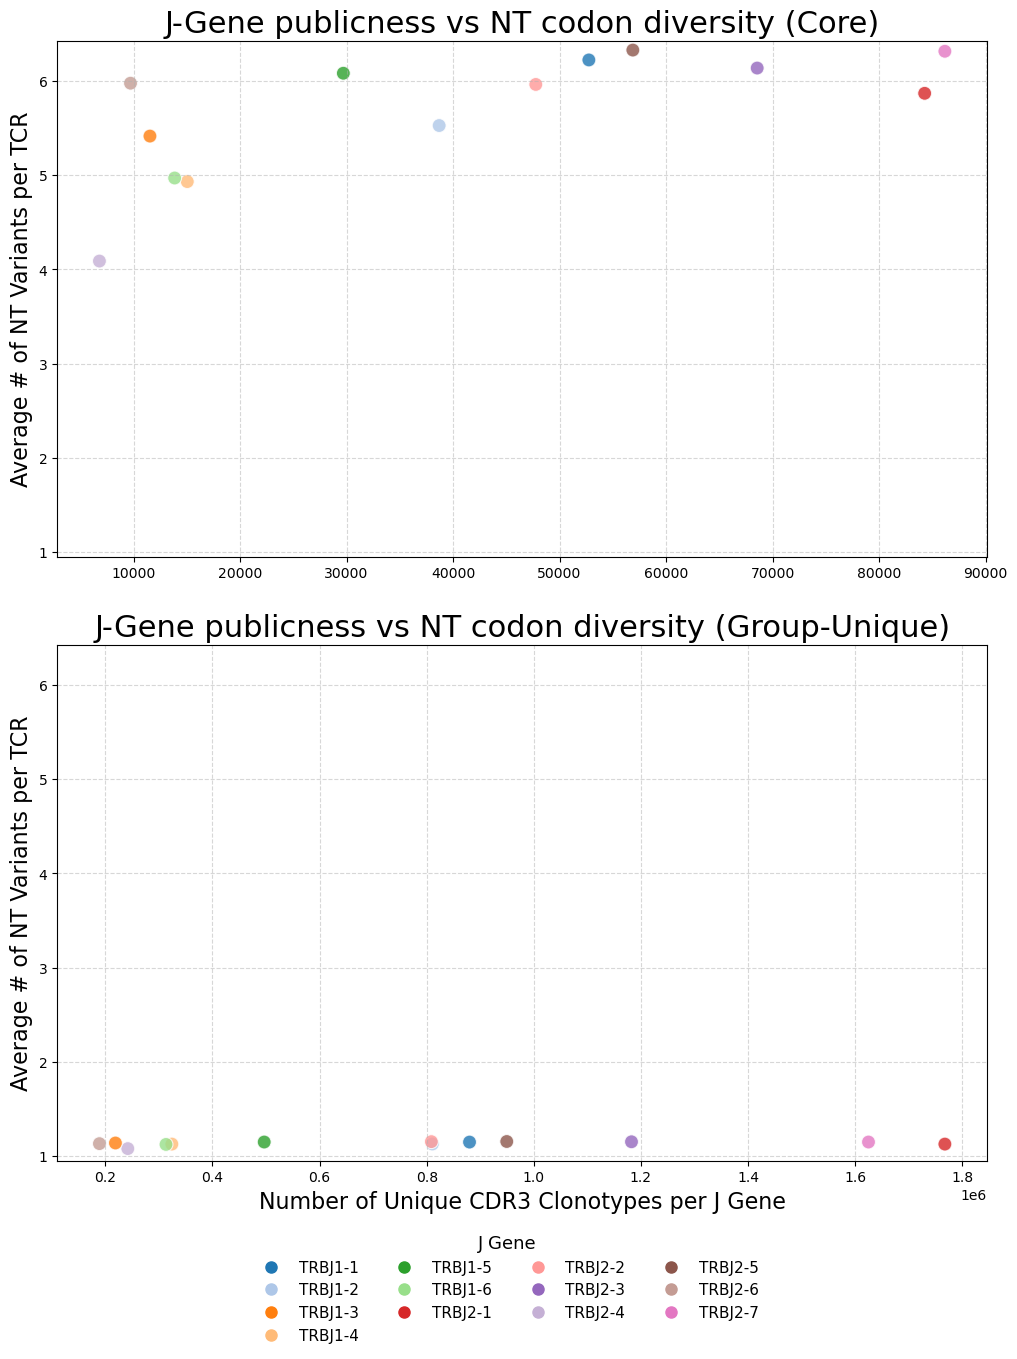

In [113]:
# J gene 
plot_gene_scatter_stacked(
    df_top=j_summary,
    df_bottom=j_summary_unique,
    gene_col="J_gene",
    x_top="n_public_TCRs",
    x_bottom="n_unique_TCRs",
    title_top="J-Gene publicness vs NT codon diversity (Core)",
    title_bottom="J-Gene publicness vs NT codon diversity (Group-Unique)",
    xlabel="Number of Unique CDR3 Clonotypes per J Gene",
    legend_title="J Gene",
    out_svg="../colon/J_gene_usage_shared_unique_stacked.svg",
    legend_y=-0.06,
    bottom_margin=0.08,
)

# Figure 7 - Codon composition divergence between CORE and group-unique clonotypes

For codon composition analyses, Immediate and Delayed samples were first matched by sequencing depth and downsampled to a common read budget. CORE and group-unique clonotype sets were then defined after normalization, so codon comparisons are not driven by library size differences.


## Read-depth matching and downsampling


In [ ]:
from typing import Tuple, Dict, Set
def match_fast_to_slow_by_reads(
    clonotype_df: pd.DataFrame,
    read_col: str,
    group_col: str = "group",
    sample_col: str = "Sample_ID",
    fast_label: str = "fast",
    slow_label: str = "slow",
    match_on: str = "log",  # "log" or "raw"
) -> pd.DataFrame:
    """
    1-to-1 greedy matching: for each slow sample, pick the closest fast sample
    by (log) total reads, without replacement.

    Returns a dataframe with matched samples only (both groups kept).
    """
    req = {sample_col, group_col, read_col}
    missing = req - set(clonotype_df.columns)
    if missing:
        raise ValueError(f"clonotype_df missing columns: {missing}")

    sample_reads = (
        clonotype_df.groupby([sample_col, group_col], as_index=False)[read_col]
        .sum()
        .rename(columns={read_col: "total_reads"})
    )

    slow = sample_reads[sample_reads[group_col] == slow_label].copy()
    fast = sample_reads[sample_reads[group_col] == fast_label].copy()

    if slow.empty or fast.empty:
        raise ValueError("One of the groups is empty after aggregating sample reads.")

    if match_on == "log":
        slow["m"] = np.log10(slow["total_reads"].clip(lower=1))
        fast["m"] = np.log10(fast["total_reads"].clip(lower=1))
    elif match_on == "raw":
        slow["m"] = slow["total_reads"]
        fast["m"] = fast["total_reads"]
    else:
        raise ValueError("match_on must be 'log' or 'raw'")

    # Greedy matching without replacement
    slow_sorted = slow.sort_values("m").reset_index(drop=True)
    fast_sorted = fast.sort_values("m").reset_index(drop=True)

    fast_vals = fast_sorted["m"].to_numpy()
    fast_ids = fast_sorted[sample_col].to_numpy()
    fast_used = np.zeros(len(fast_sorted), dtype=bool)

    matched_fast_ids = []
    for s_val in slow_sorted["m"].to_numpy():
        # find nearest available fast sample
        # start from insertion point, then expand outward until find unused
        idx = int(np.searchsorted(fast_vals, s_val, side="left"))
        left = idx - 1
        right = idx

        best_j = None
        best_dist = None

        while left >= 0 or right < len(fast_vals):
            candidates = []
            if left >= 0 and not fast_used[left]:
                candidates.append(left)
            if right < len(fast_vals) and not fast_used[right]:
                candidates.append(right)

            if candidates:
                # pick closest among candidates
                dists = [abs(fast_vals[j] - s_val) for j in candidates]
                j = candidates[int(np.argmin(dists))]
                best_j = j
                best_dist = abs(fast_vals[j] - s_val)
                break

            left -= 1
            right += 1

        if best_j is None:
            # not enough fast samples to match all slow samples
            break

        fast_used[best_j] = True
        matched_fast_ids.append(fast_ids[best_j])

    matched_slow_ids = slow_sorted.loc[: len(matched_fast_ids) - 1, sample_col].tolist()

    keep_samples = set(matched_slow_ids) | set(matched_fast_ids)
    df_matched = clonotype_df[clonotype_df[sample_col].isin(keep_samples)].copy()

    return df_matched

def downsample_reads_within_sample_multinomial(
    df: pd.DataFrame,
    read_col: str,
    target_reads: int,
    sample_col: str = "Sample_ID",
    group_col: str = "group",
    seed: int = 0,
    out_col: str = "ds_reads",
) -> pd.DataFrame:
    """
    For each sample, downsample clonotype read counts to target_reads using a multinomial draw.
    Keeps the same rows; adds a new column out_col with downsampled counts.

    Assumes read_col is integer-like counts per row (clonotype).
    """
    if target_reads <= 0:
        raise ValueError("target_reads must be > 0")

    rng = np.random.default_rng(seed)

    df = df.copy()
    df[read_col] = pd.to_numeric(df[read_col], errors="coerce")
    df = df.dropna(subset=[read_col])
    df = df[df[read_col] > 0].copy()

    def _ds_one_sample(sub: pd.DataFrame) -> pd.DataFrame:
        counts = sub[read_col].to_numpy(dtype=float)
        total = counts.sum()
        if total <= 0:
            sub[out_col] = 0
            return sub

        # If sample has fewer reads than target, keep as-is (or optionally upsample; we won't).
        if total <= target_reads:
            sub[out_col] = counts.astype(int)
            return sub

        p = counts / total
        draw = rng.multinomial(target_reads, pvals=p)
        sub[out_col] = draw.astype(int)
        return sub

    downsampled = []
    for _, sub in df.groupby([sample_col, group_col], sort=False):
        downsampled.append(_ds_one_sample(sub.copy()))

    df = pd.concat(downsampled, ignore_index=True)

    return df

def define_shared_unique_sets_after_downsampling(
    df_down: pd.DataFrame,
    thresh: int,
    aa_col: str = "aaSeqCDR3",
    sample_col: str = "Sample_ID",
    group_col: str = "group",
    fast_label: str = "fast",
    slow_label: str = "slow",
    ds_col: str = "ds_reads",
) -> Tuple[Set[str], Set[str], Set[str], pd.DataFrame]:
    """
    Define sets based on the FINAL matched+downsampled data.
    Presence is defined as ds_reads > 0 for that (AA, sample).
    Returns: shared_set, unique_fast_set, unique_slow_set, df_counts
    """
    req = {aa_col, sample_col, group_col, ds_col}
    missing = req - set(df_down.columns)
    if missing:
        raise ValueError(f"df_down missing columns: {missing}")

    # One row per (AA, Sample, Group) with presence
    pres = (
        df_down.loc[df_down[ds_col] > 0, [aa_col, sample_col, group_col]]
        .drop_duplicates().copy())

    df_counts = (
        pres.groupby([aa_col, group_col])[sample_col]
        .nunique().unstack(fill_value=0))

    shared_set = set(df_counts[
            (df_counts.get(fast_label, 0) >= thresh) &
            (df_counts.get(slow_label, 0) >= thresh)].index)

    unique_fast_set = set(df_counts[
            (df_counts.get(fast_label, 0) >= thresh) &
            (df_counts.get(slow_label, 0) == 0)].index)

    unique_slow_set = set(df_counts[
            (df_counts.get(slow_label, 0) >= thresh) &
            (df_counts.get(fast_label, 0) == 0)].index)

    return shared_set, unique_fast_set, unique_slow_set, df_counts


In [ ]:
# match -> downsample -> define shared/unique
READ_COL = "readCount"
PUBLICNESS_THRESHOLD = 3
MIN_DOWNSAMPLED_READS = 3         

# Match fast to slow by (log) total reads, keep paired samples
clonotype_df_matched = match_fast_to_slow_by_reads(
    clonotype_df=clonotype_df,
    read_col=READ_COL,
    match_on="log",
)

# Choose downsampling depth = lowest total reads across matched samples (both groups)
sample_totals_matched = (
    clonotype_df_matched.groupby(["Sample_ID", "group"], as_index=False)[READ_COL]
    .sum()
    .rename(columns={READ_COL: "total_reads"})
)

target_reads = int(sample_totals_matched["total_reads"].min())

# Downsample within each sample to target_reads
clonotype_df_down = downsample_reads_within_sample_multinomial(
    df=clonotype_df_matched,
    read_col=READ_COL,
    target_reads=target_reads,
    seed=0,
    out_col="ds_reads",
)


In [ ]:
# Define shared/unique sets AFTER matching+downsampling
shared_set_std, unique_fast_set_std, unique_slow_set_std, df_counts_std = (
    define_shared_unique_sets_after_downsampling(
        df_down=clonotype_df_down,
        thresh=PUBLICNESS_THRESHOLD,
        ds_col="ds_reads",
    )
)

print(f"shared_set_std: {len(shared_set_std)}")
print(f"unique_fast_set_std: {len(unique_fast_set_std)}")
print(f"unique_slow_set_std: {len(unique_slow_set_std)}")

shared_set_std: 27987
unique_fast_set_std: 19646
unique_slow_set_std: 4527


In [ ]:
df_shared = clonotype_df_down[
    (clonotype_df_down["aaSeqCDR3"].isin(shared_set_std)) &
    (clonotype_df_down["ds_reads"] >= MIN_DOWNSAMPLED_READS)
].copy()

# restrict shared sequences to diff_nt only
df_shared_diff_nt = df_shared[df_shared["aaSeqCDR3"].isin(diff_nt)].copy()
print("CORE shared diff-NT AAs:", df_shared_diff_nt["aaSeqCDR3"].nunique())

27712


In [ ]:
df_unique_fast = clonotype_df_down[
    (clonotype_df_down["aaSeqCDR3"].isin(unique_fast_set_std)) &
    (clonotype_df_down["group"] == "fast") &
    (clonotype_df_down["ds_reads"] >= MIN_DOWNSAMPLED_READS)
].copy()

df_unique_slow = clonotype_df_down[
    (clonotype_df_down["aaSeqCDR3"].isin(unique_slow_set_std)) &
    (clonotype_df_down["group"] == "slow") &
    (clonotype_df_down["ds_reads"] >= MIN_DOWNSAMPLED_READS)
].copy()

print("unique_fast AAs:", df_unique_fast["aaSeqCDR3"].nunique())
print("unique_slow AAs:", df_unique_slow["aaSeqCDR3"].nunique())


unique_fast AAs: 14716
unique_slow AAs: 4057


In [ ]:
AA_TO_CODONS = {
    "A": ["GCT","GCC","GCA","GCG"],
    "C": ["TGT","TGC"],
    "D": ["GAT","GAC"],
    "E": ["GAA","GAG"],
    "F": ["TTT","TTC"],
    "G": ["GGT","GGC","GGA","GGG"],
    "H": ["CAT","CAC"],
    "I": ["ATT","ATC","ATA"],
    "K": ["AAA","AAG"],
    "L": ["TTA","TTG","CTT","CTC","CTA","CTG"],
    "M": ["ATG"],
    "N": ["AAT","AAC"],
    "P": ["CCT","CCC","CCA","CCG"],
    "Q": ["CAA","CAG"],
    "R": ["CGT","CGC","CGA","CGG","AGA","AGG"],
    "S": ["TCT","TCC","TCA","TCG","AGT","AGC"],
    "T": ["ACT","ACC","ACA","ACG"],
    "V": ["GTT","GTC","GTA","GTG"],
    "W": ["TGG"],
    "Y": ["TAT","TAC"],
}
AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")


def get_unique_aa_nt_universe(df, aa_col="aaSeqCDR3", nt_col="nSeqCDR3"):
    u = df[[aa_col, nt_col]].dropna().drop_duplicates().copy()
    m = u[nt_col].str.len().astype(int) == u[aa_col].str.len().astype(int) * 3
    return u[m].copy()

def explode_codons_universe(universe_df, aa_col="aaSeqCDR3", nt_col="nSeqCDR3"):
    aa_seqs = universe_df[aa_col].tolist()
    nt_seqs = universe_df[nt_col].tolist()
    records = [
        {"AA": aa[i], "Position": i + 1, "Codon": nt[i*3:(i+1)*3]}
        for aa, nt in zip(aa_seqs, nt_seqs)
        for i in range(len(aa))
    ]
    return pd.DataFrame(records)

def codon_fraction_by_AA_position(df_group):
    """
    Returns a dataframe with columns: AA, Position, Codon, fraction
    where fraction is normalized within each (AA, Position).
    Universe = unique (aaSeqCDR3, nSeqCDR3) pairs.
    """
    uni = get_unique_aa_nt_universe(df_group)
    codon_df = explode_codons_universe(uni)

    counts = (
        codon_df.groupby(["AA", "Position", "Codon"])
        .size()
        .reset_index(name="count")
    )
    counts["fraction"] = counts["count"] / counts.groupby(["AA", "Position"])["count"].transform("sum")
    return counts


def plot_codon_composition_grid_paired(
    df_fast,
    df_slow,
    global_positions,
    title="Codon composition by AA and CDR3 position (paired)",
    aa_order=AA_ORDER,
    aa_to_codons=AA_TO_CODONS,
    n_cols=5,
    figsize=(20, 12),
    show_legend=True,
    out_svg=None,
):
    frac_fast = codon_fraction_by_AA_position(df_fast)
    frac_slow = codon_fraction_by_AA_position(df_slow)

    n_aa = len(aa_order)
    blocks = int(np.ceil(n_aa / n_cols))
    n_rows = blocks * 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharey=True)
    axes = np.array(axes)

    def draw_panel(ax, sub_frac, aa, positions, codons, grey=False, hide_xticklabels=False):
        mat = (
            sub_frac[sub_frac["AA"] == aa]
            .pivot_table(index="Position", columns="Codon", values="fraction", fill_value=0)
            .reindex(index=positions, columns=codons, fill_value=0)
        )

        bottoms = np.zeros(len(positions), dtype=float)
        for codon in codons:
            vals = mat[codon].to_numpy()
            if grey:
                ax.bar(positions, vals, bottom=bottoms, width=0.85, color="0.7", label=codon)
            else:
                ax.bar(positions, vals, bottom=bottoms, width=0.85, label=codon)
            bottoms += vals

        ax.set_ylim(0, 1.0)

        ax.set_xticks(positions)
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
        ax.tick_params(axis="y", labelsize=8)

        if hide_xticklabels:
            ax.tick_params(axis="x", labelbottom=False)

        # legend gutter on the right
        ax.set_xlim(positions.min() - 0.6, positions.max() + 0.6)

    for i, aa in enumerate(aa_order):
        block = i // n_cols
        col = i % n_cols
        ax_fast = axes[block * 2, col]
        ax_slow = axes[block * 2 + 1, col]

        codons = aa_to_codons[aa]
        is_single = (len(codons) == 1)

        pos_fast = frac_fast.loc[frac_fast["AA"] == aa, "Position"]
        pos_slow = frac_slow.loc[frac_slow["AA"] == aa, "Position"]

        if pos_fast.empty and pos_slow.empty:
            ax_fast.axis("off")
            ax_slow.axis("off")
            continue

        positions = global_positions

        title_color = "0.4" if is_single else "black"

        # Add padding so the AA title sits a bit higher and doesn't collide
        ax_fast.set_title(aa, fontsize=12, fontweight="bold", color=title_color, pad=8)

        draw_panel(ax_fast, frac_fast, aa, positions, codons, grey=is_single, hide_xticklabels=True)
        draw_panel(ax_slow, frac_slow, aa, positions, codons, grey=is_single, hide_xticklabels=False)

        # legend once per AA: on slow axis, in gutter
        if show_legend and (not is_single):
            ax_slow.legend(title="Codon", fontsize=8, title_fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False,
                            handlelength=1.1, borderaxespad=0.0, labelspacing=0.25,)

    # turn off unused axes
    total_cells = n_rows * n_cols
    used_cells = blocks * n_cols * 2
    for idx in range(used_cells, total_cells):
        r = idx // n_cols
        c = idx % n_cols
        axes[r, c].axis("off")

    fig.suptitle(title, fontsize=22, fontweight="normal", y=0.94)
    fig.text(0.5, 0.04, "CDR3 position", ha="center", fontsize=16)
    fig.text(0.01, 0.5, "Relative codon proportion within (AA, position)", va="center", rotation="vertical", fontsize=16)

    # tight_layout first, then add extra vertical spacing
    plt.tight_layout(rect=[0.08, 0.06, 1, 0.95])
    fig.subplots_adjust(wspace=0.35, hspace=0.70) 

    # add Immediate/Delayed row labels on the left margin
    # Place the label centered on each row using axes positions
    for r in range(n_rows):
        # skip if the whole row is off (rare, but safe)
        if all(axes[r, c].axison is False for c in range(n_cols)):
            continue
        bbox = axes[r, 0].get_position()
        y_center = (bbox.y0 + bbox.y1) / 2 + 0.02
        fig.text(
            0.085, y_center,                 
            "Immediate" if (r % 2 == 0) else "Delayed",
            ha="right", va="center", rotation=45,
            fontsize=13, fontweight="normal", rotation_mode="anchor",
        )
    if out_svg is not None:
        save_plot(out_svg, format="svg", bbox_inches="tight")
    
    plt.show()
    return frac_fast, frac_slow


## Codon composition plots

In [33]:
df_shared_fast = df_shared_diff_nt[df_shared_diff_nt["group"] == "fast"].copy()
df_shared_slow = df_shared_diff_nt[df_shared_diff_nt["group"] == "slow"].copy()

In [34]:
# global max CDR3 position across all datasets
global_max_pos = max(
    df_shared_fast["aaSeqCDR3"].str.len().max(),
    df_shared_slow["aaSeqCDR3"].str.len().max(),
    df_unique_fast["aaSeqCDR3"].str.len().max(),
    df_unique_slow["aaSeqCDR3"].str.len().max(),
)

global_positions = np.arange(1, global_max_pos + 1)

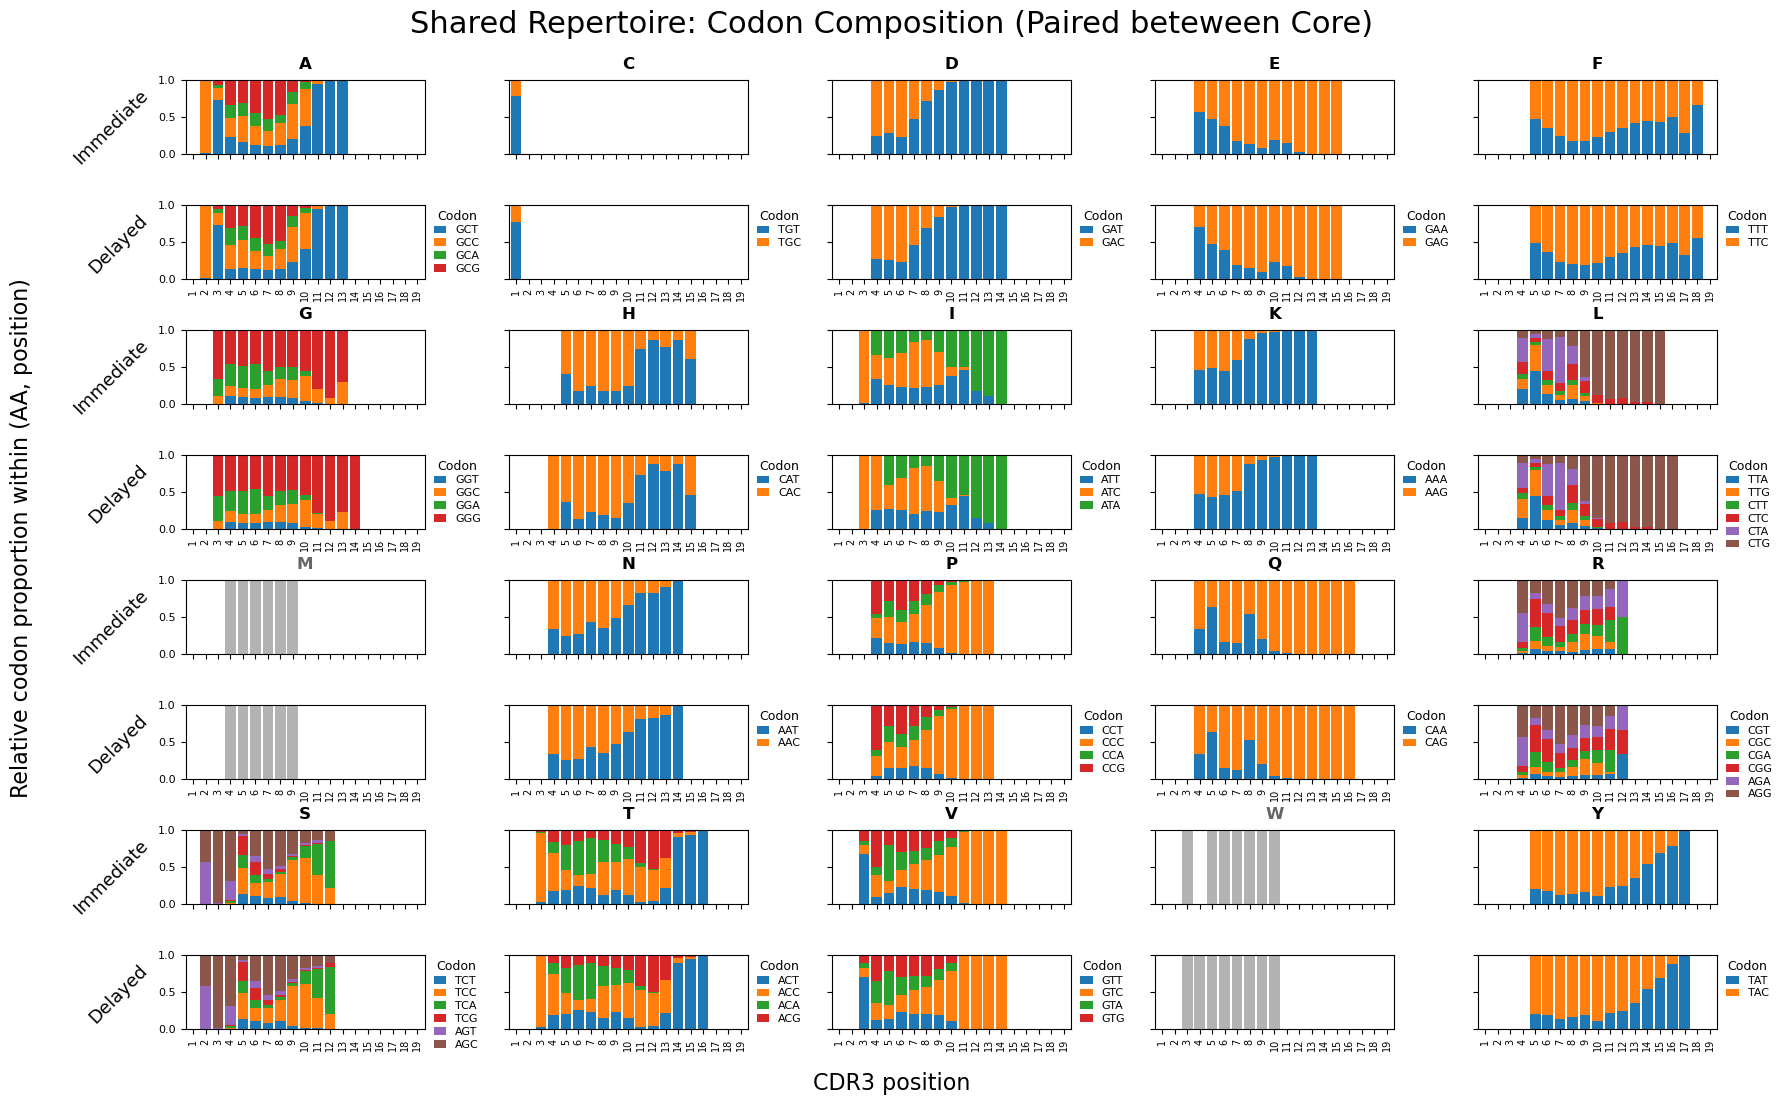

In [ ]:
frac_fast_shared, frac_slow_shared = plot_codon_composition_grid_paired(
    df_fast=df_shared_fast,
    df_slow=df_shared_slow,
    global_positions=global_positions,
    title="CORE clonotypes: codon composition",
    n_cols=5,
    figsize=(18, 12),
    show_legend=True,
    out_svg="codon_bias_composition_core.svg"
)

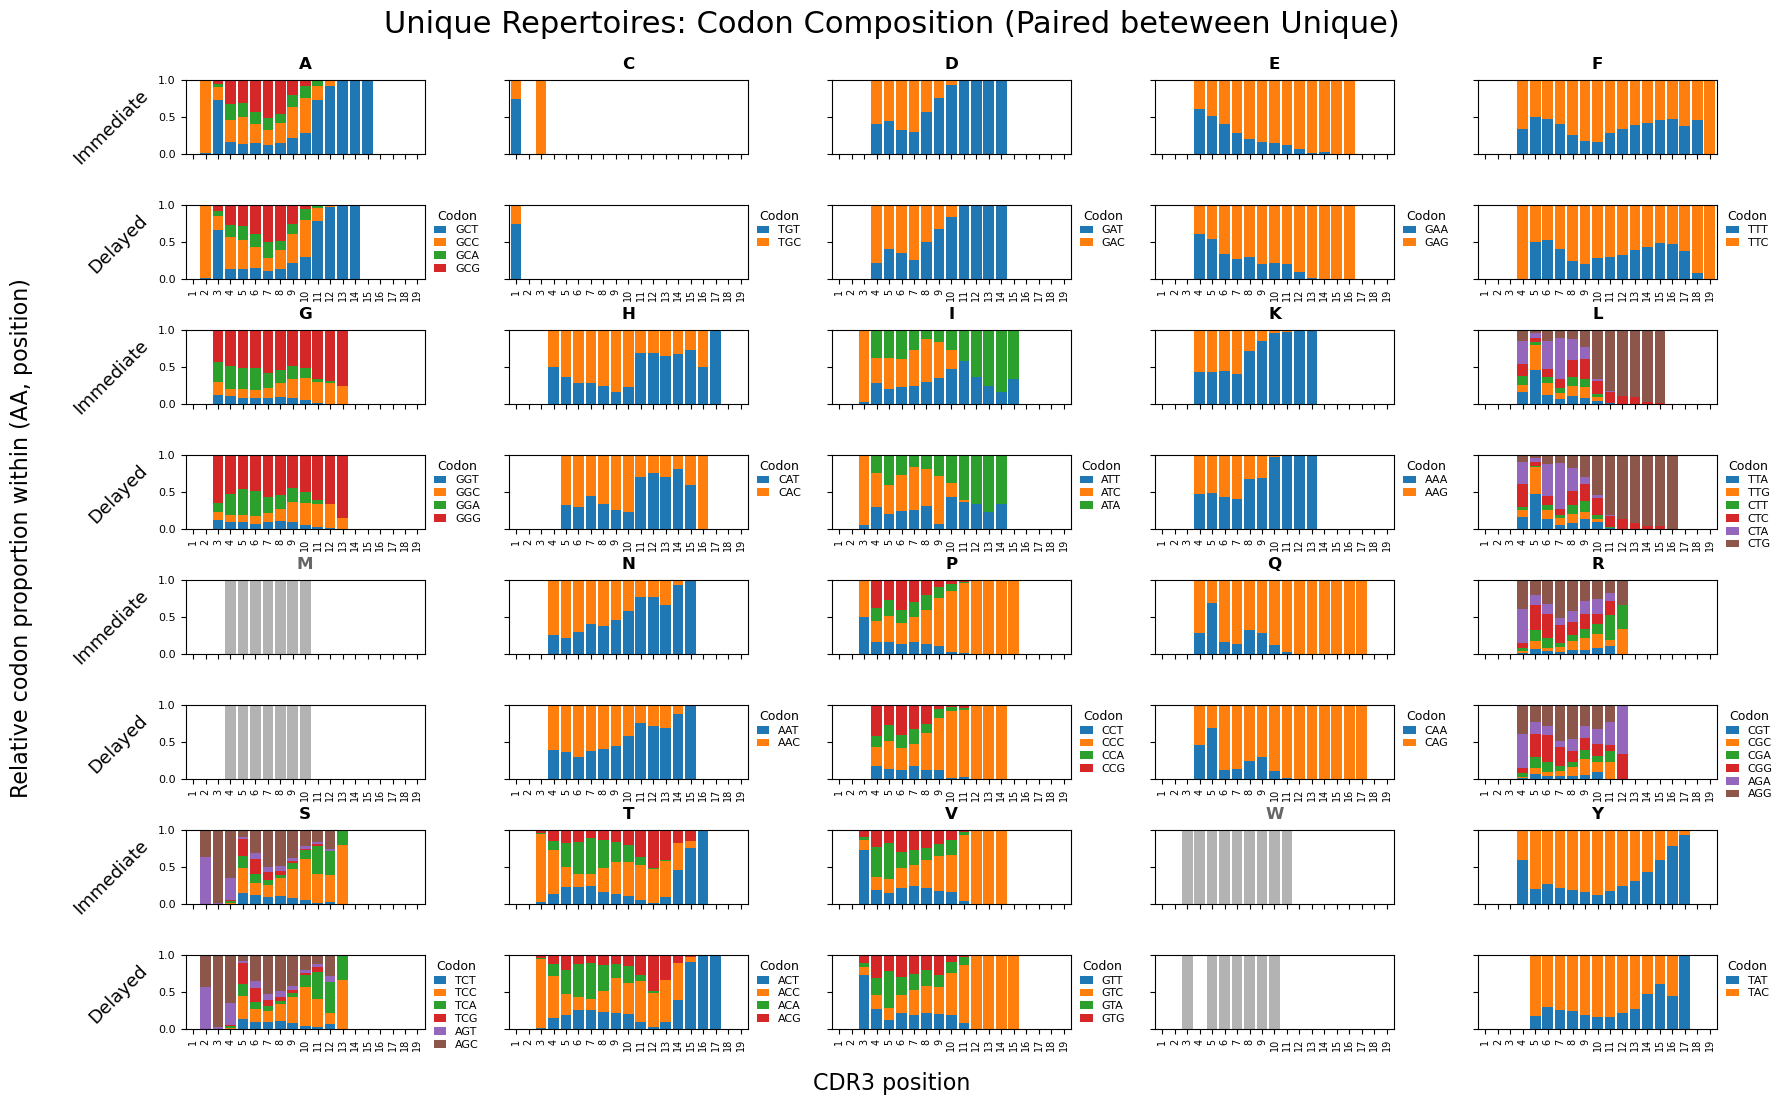

In [ ]:
frac_fast, frac_slow = plot_codon_composition_grid_paired(
    df_fast=df_unique_fast,
    df_slow=df_unique_slow,
    global_positions=global_positions,
    title="Group-unique clonotypes: codon composition",
    n_cols=5,
    figsize=(18, 12),
    show_legend=True,
    out_svg="codon_bias_composition_unique.svg"
)


## Codon composition summary metrics

In [ ]:
def _safe_normalize(vec: np.ndarray) -> np.ndarray:
    s = float(np.sum(vec))
    if s <= 0:
        return np.zeros_like(vec, dtype=float)
    return vec / s

def _js_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    """
    Jensen–Shannon divergence (base-2), bounded in [0, 1].
    Safe for zeros via eps-smoothing + renormalization.
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = _safe_normalize(p + eps)
    q = _safe_normalize(q + eps)
    m = 0.5 * (p + q)

    def kl(a, b):
        return float(np.sum(a * np.log2(a / b)))

    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def _shannon_entropy(p: np.ndarray, eps: float = 1e-12) -> float:
    """Shannon entropy (base-e); safe for zeros via eps."""
    p = np.asarray(p, dtype=float)
    p = _safe_normalize(p + eps)
    return float(-np.sum(p * np.log(p)))

def effective_num_codons(p: np.ndarray, eps: float = 1e-12) -> float:
    """Effective number of codons = exp(H)."""
    return float(np.exp(_shannon_entropy(p, eps=eps)))


# Δ-fraction table from two fraction dfs
def build_delta_fraction_table(
    frac_fast: pd.DataFrame,
    frac_slow: pd.DataFrame,
    aa_to_codons: dict,
    aa_order=AA_ORDER,
) -> pd.DataFrame:
    """
    frac_* expected columns: AA, Position, Codon, fraction
    Returns long df with columns:
      AA, Position, Codon, frac_fast, frac_slow, delta
    Only includes codons valid for that AA.
    """
    # Keep only relevant columns
    f = frac_fast[["AA", "Position", "Codon", "fraction"]].rename(columns={"fraction": "frac_fast"})
    s = frac_slow[["AA", "Position", "Codon", "fraction"]].rename(columns={"fraction": "frac_slow"})

    merged = pd.merge(f, s, on=["AA", "Position", "Codon"], how="outer")
    merged["frac_fast"] = merged["frac_fast"].fillna(0.0)
    merged["frac_slow"] = merged["frac_slow"].fillna(0.0)

    # Filter to AA-specific codons only
    valid_rows = []
    for aa in aa_order:
        codons = set(aa_to_codons[aa])
        sub = merged[merged["AA"] == aa].copy()
        sub = sub[sub["Codon"].isin(codons)]
        valid_rows.append(sub)
    merged = pd.concat(valid_rows, ignore_index=True)

    merged["delta"] = merged["frac_fast"] - merged["frac_slow"]
    merged["Position"] = pd.to_numeric(merged["Position"], errors="coerce").astype("Int64")
    merged = merged.dropna(subset=["AA", "Position", "Codon"]).copy()
    merged["Position"] = merged["Position"].astype(int)

    return merged


# Δ-heatmap grid (AA facets), global color scale
def plot_delta_fraction_heatmap_grid(
    delta_df: pd.DataFrame,
    title: str,
    aa_to_codons: dict = AA_TO_CODONS,
    aa_order=AA_ORDER,
    n_cols: int = 5,
    figsize=(20, 12),
    cmap: str = "coolwarm",
    show_colorbar: bool = True,
):
    """
    Faceted heatmap by AA:
      x = CDR3 position
      y = codon (AA-specific)
      color = Δfraction = fast - slow

    Uses GLOBAL symmetric vlim across all AAs within this delta_df.
    """
    n_aa = len(aa_order)
    n_rows = int(np.ceil(n_aa / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=False, sharey=False)
    axes = np.array(axes).reshape(n_rows, n_cols)

    # Global symmetric limits
    if delta_df.empty:
        raise ValueError("delta_df is empty. Check inputs.")
    vmax = float(np.nanmax(np.abs(delta_df["delta"].to_numpy())))
    vmax = max(vmax, 1e-6)
    vmin = -vmax

    last_im = None

    for i, aa in enumerate(aa_order):
        r = i // n_cols
        c = i % n_cols
        ax = axes[r, c]

        codons = aa_to_codons[aa]
        sub = delta_df[delta_df["AA"] == aa]
        if sub.empty:
            ax.axis("off")
            continue

        pos_min = int(sub["Position"].min())
        pos_max = int(sub["Position"].max())
        positions = list(range(pos_min, pos_max + 1))

        mat = (
            sub.pivot_table(index="Codon", columns="Position", values="delta", fill_value=0.0)
            .reindex(index=codons, columns=positions, fill_value=0.0)
        )

        # image: codon rows, position columns
        last_im = ax.imshow(mat.to_numpy(),aspect="auto",interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax,)
        ax.set_title(aa, fontsize=11, fontweight="bold", pad=6)
        ax.set_xticks(np.arange(len(positions)))
        ax.set_xticklabels([str(p) for p in positions], rotation=90, fontsize=7)

        ax.set_yticks(np.arange(len(codons)))
        ax.set_yticklabels(codons, fontsize=7)

        # thin gridlines help reading
        ax.set_xticks(np.arange(-0.5, len(positions), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(codons), 1), minor=True)
        ax.grid(which="minor", linewidth=0.3)
        ax.tick_params(which="minor", bottom=False, left=False)

    # turn off unused axes
    for j in range(n_aa, n_rows * n_cols):
        r = j // n_cols
        c = j % n_cols
        axes[r, c].axis("off")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.text(0.5, 0.04, "CDR3 position", ha="center", fontsize=14, fontweight="bold")
    fig.text(0.02, 0.5, "Codon (within AA)", va="center", rotation="vertical", fontsize=14, fontweight="bold")

    if show_colorbar and last_im is not None:
        # one shared colorbar
        # create a dedicated colorbar axis on the right
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
        cbar = fig.colorbar(last_im, cax=cax)
        cbar.set_label("Delta fraction (Immediate - Delayed)", fontsize=12)

    plt.tight_layout(rect=[0.04, 0.06, 0.90, 0.93])
    plt.show()


# Collapse and compare (Shared vs Unique):
#    (i) Effective codon # per (AA, Position) per group
#    (ii) JS divergence between immediate and delayed per (AA, Position)
def _codon_vector_for_aa_pos(frac_df: pd.DataFrame, aa: str, pos: int, codons: list) -> np.ndarray:
    sub = frac_df[(frac_df["AA"] == aa) & (frac_df["Position"] == pos)]
    if sub.empty:
        return np.zeros(len(codons), dtype=float)
    v = np.zeros(len(codons), dtype=float)
    m = {c: float(f) for c, f in zip(sub["Codon"].tolist(), sub["fraction"].tolist())}
    for i, c in enumerate(codons):
        v[i] = m.get(c, 0.0)
    return _safe_normalize(v)


def collapse_metrics_by_aa_pos(
    frac_fast: pd.DataFrame,
    frac_slow: pd.DataFrame,
    label: str,
    aa_to_codons: dict = AA_TO_CODONS,
    aa_order=AA_ORDER,
) -> pd.DataFrame:
    """
    Returns df with rows per (AA, Position) containing:
      label, AA, Position, eff_codons_fast, eff_codons_slow, js_fast_slow
    """
    rows = []
    for aa in aa_order:
        codons = aa_to_codons[aa]
        # union of positions present in either fast/slow for this AA
        pos_f = frac_fast.loc[frac_fast["AA"] == aa, "Position"]
        pos_s = frac_slow.loc[frac_slow["AA"] == aa, "Position"]
        if pos_f.empty and pos_s.empty:
            continue
        pos_min = int(min(pos_f.min() if not pos_f.empty else np.inf,
                          pos_s.min() if not pos_s.empty else np.inf))
        pos_max = int(max(pos_f.max() if not pos_f.empty else -np.inf,
                          pos_s.max() if not pos_s.empty else -np.inf))
        for pos in range(pos_min, pos_max + 1):
            p = _codon_vector_for_aa_pos(frac_fast, aa, pos, codons)
            q = _codon_vector_for_aa_pos(frac_slow, aa, pos, codons)

            rows.append({
                "set": label,
                "AA": aa,
                "Position": pos,
                "eff_codons_fast": effective_num_codons(p),
                "eff_codons_slow": effective_num_codons(q),
                "js_fast_slow": _js_divergence(p, q),
            })

    out = pd.DataFrame(rows)
    return out


def mask_below_threshold(mat: pd.DataFrame, threshold: float) -> pd.DataFrame:
    """Return a copy of mat where values < threshold are NaN (for masking in imshow)."""
    if threshold is None:
        return mat
    out = mat.copy()
    out[out < threshold] = np.nan
    return out


def plot_effective_codons_shared_vs_unique(
    metrics_df: pd.DataFrame,
    value_col: str,  
    title_prefix: str = "Effective codons: Shared vs Unique",
    aa_order=AA_ORDER,
    figsize=(18, 3.8),
    global_positions: list[int] | None = None,
):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes = np.array(axes)

    def heat(ax, sub, title):
        mat = sub.pivot_table(index="AA", columns="Position", values=value_col, aggfunc="mean")
        mat = mat.reindex(index=aa_order)
        if global_positions is not None:
            mat = mat.reindex(columns=global_positions)

        im = ax.imshow(mat.to_numpy(), aspect="auto", interpolation="nearest")
        ax.set_title(title, fontsize=12, fontweight="bold")

        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels(mat.index.tolist(), fontsize=8)

        positions = mat.columns.tolist() 
        ax.set_xticks(np.arange(len(positions)))
        ax.set_xticklabels([str(p) for p in positions], rotation=90, fontsize=7)
        return im

    sub_shared = metrics_df[metrics_df["set"] == "Shared"].copy()
    sub_unique = metrics_df[metrics_df["set"] == "Unique"].copy()

    im1 = heat(axes[0], sub_shared, f"{value_col} — Shared")
    im2 = heat(axes[1], sub_unique, f"{value_col} — Unique")

    # single shared colorbar on right
    cax = fig.add_axes([0.92, 0.20, 0.02, 0.60])
    cbar = fig.colorbar(im1, cax=cax)
    cbar.set_label("Effective number of codons (exp(H))", fontsize=11)

    fig.suptitle(title_prefix, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0.02, 0.02, 0.90, 0.90])
    plt.show()


def plot_js_divergence_shared_vs_unique(
    metrics_df: pd.DataFrame,
    js_col: str = "js_fast_slow",
    title_prefix: str = "JS divergence (Immediate vs Delayed)",
    aa_order=AA_ORDER,
    figsize=(18, 3.8),
    js_threshold: float | None = None,   
    vmax: float | None = None,           
    global_positions: list[int] | None = None,
):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes = np.array(axes)

    def heat(ax, sub, title):
        mat = sub.pivot_table(index="AA", columns="Position", values=js_col, aggfunc="mean")
        mat = mat.reindex(index=aa_order)
        if global_positions is not None:
            mat = mat.reindex(columns=global_positions)

        mat_masked = mask_below_threshold(mat, js_threshold)

        # choose vmax: either user-specified or computed from visible (non-NaN) values
        local_vmax = vmax
        if local_vmax is None:
            vals = mat_masked.to_numpy().ravel()
            vals = vals[~np.isnan(vals)]
            local_vmax = float(np.nanmax(vals)) if vals.size else 1e-6

        im = ax.imshow(
            mat_masked.to_numpy(),
            aspect="auto",
            interpolation="nearest",
            vmin=js_threshold if js_threshold is not None else 0.0,
            vmax=local_vmax,
        )

        ax.set_title(title, fontsize=16)

        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels(mat.index.tolist(), fontsize=9)

        positions = mat.columns.tolist()
        ax.set_xticks(np.arange(len(positions)))
        ax.set_xticklabels([str(p) for p in positions], fontsize=9)
        return im

    sub_shared = metrics_df[metrics_df["set"] == "Shared"].copy()
    sub_unique = metrics_df[metrics_df["set"] == "Unique"].copy()

    im1 = heat(axes[0], sub_shared, "JS divergence — Core")
    im2 = heat(axes[1], sub_unique, "JS divergence — Unique")

    # single shared colorbar on right
    cax = fig.add_axes([0.92, 0.20, 0.02, 0.60])
    cbar = fig.colorbar(im1, cax=cax)
    lbl = "Jensen–Shannon divergence"
    if js_threshold is not None:
        lbl += f"\n (base-2; masked < {js_threshold})"
    cbar.set_label(lbl, fontsize=14)

    fig.suptitle(title_prefix, fontsize=22, y=0.92)
    plt.tight_layout(rect=[0.02, 0.02, 0.90, 0.90])
    save_plot("js_divergence.svg", format="svg")
    plt.show()


In [38]:
# Fractions
frac_shared_fast = codon_fraction_by_AA_position(df_shared_fast)
frac_shared_slow = codon_fraction_by_AA_position(df_shared_slow)
frac_unique_fast = codon_fraction_by_AA_position(df_unique_fast)
frac_unique_slow = codon_fraction_by_AA_position(df_unique_slow)

# Δfraction tables
delta_shared = build_delta_fraction_table(frac_shared_fast, frac_shared_slow, aa_to_codons=AA_TO_CODONS, aa_order=AA_ORDER)
delta_unique = build_delta_fraction_table(frac_unique_fast, frac_unique_slow, aa_to_codons=AA_TO_CODONS, aa_order=AA_ORDER)


/tmp/ipykernel_501051/957031836.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.06, 0.90, 0.93])


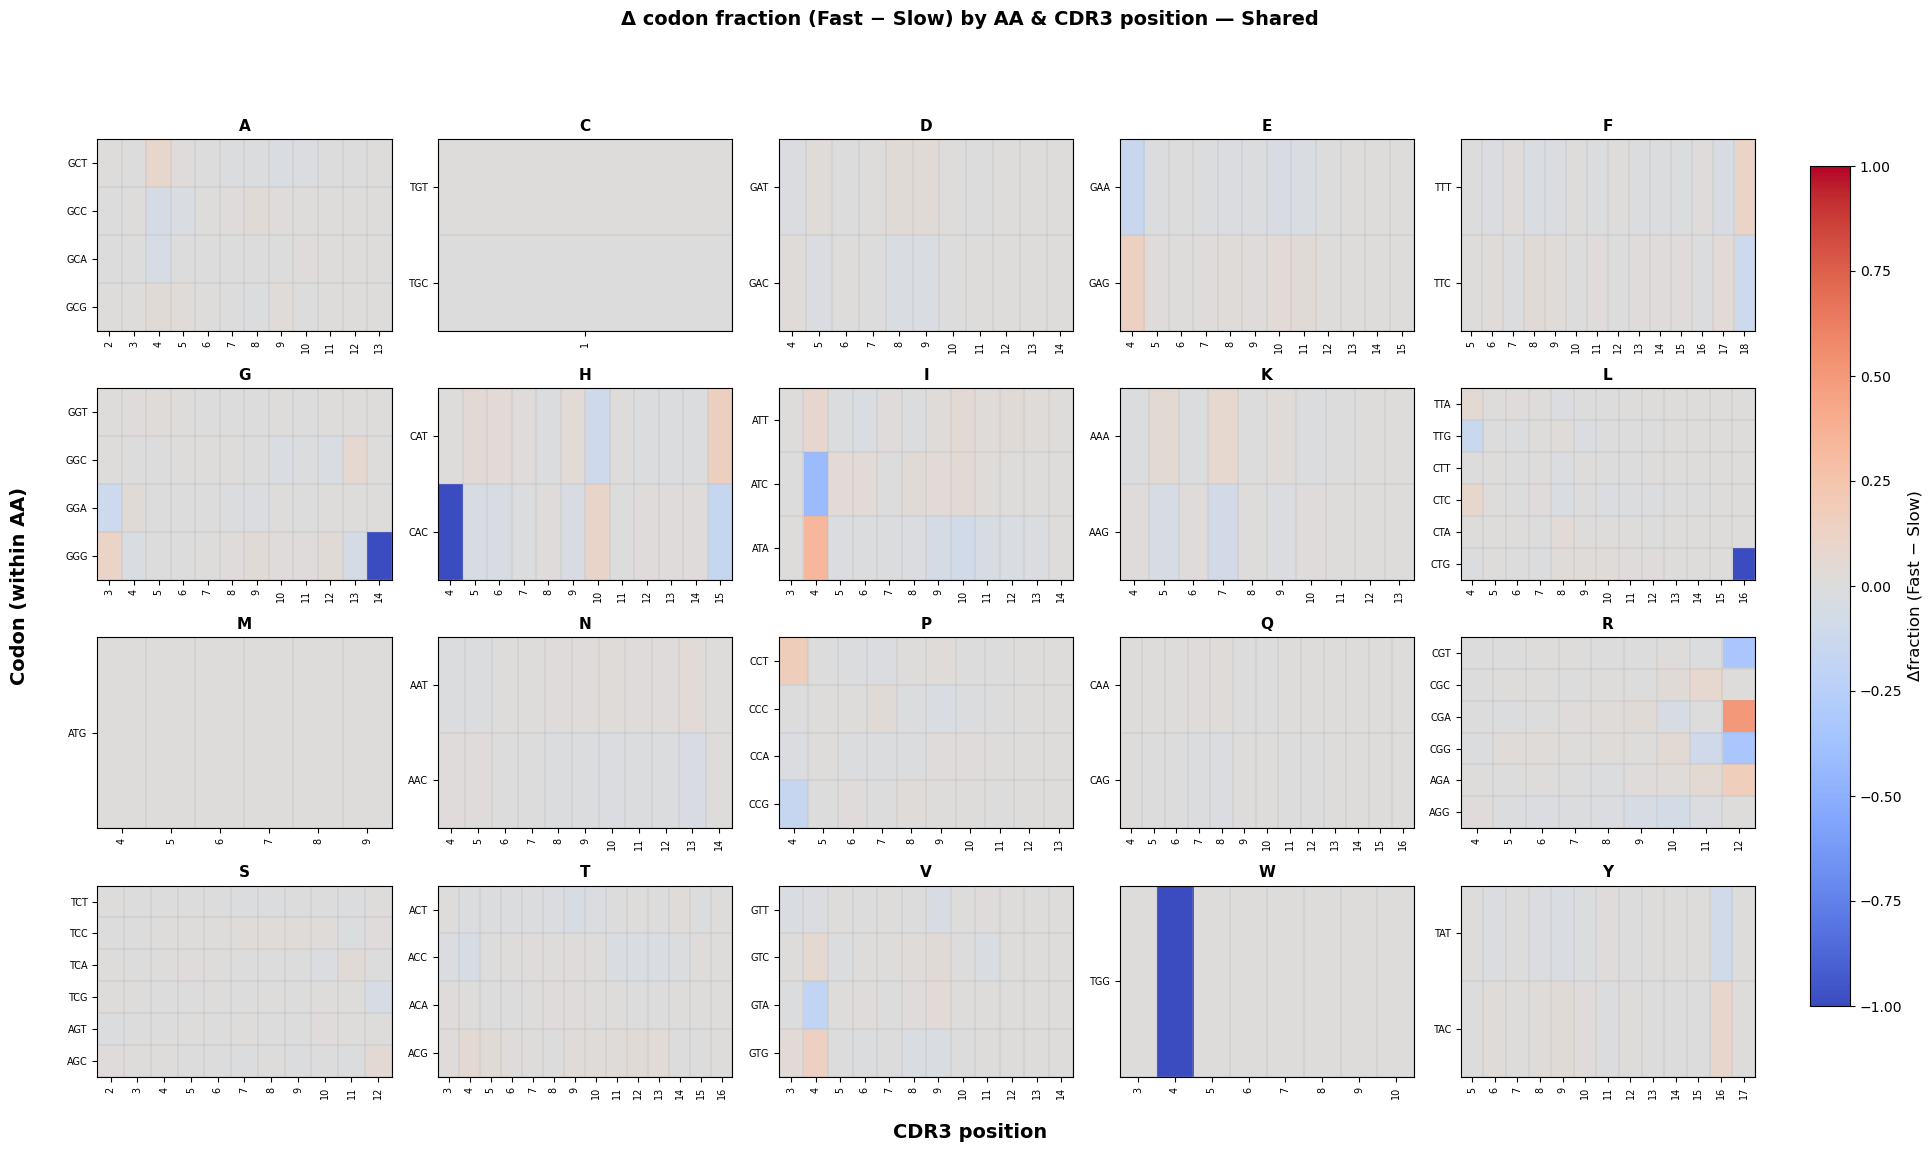

In [ ]:
# Δ-heatmaps
plot_delta_fraction_heatmap_grid(
    delta_shared,
    title="Delta codon fraction (Immediate - Delayed): CORE",
    aa_to_codons=AA_TO_CODONS,
    aa_order=AA_ORDER,
    n_cols=5,
    figsize=(20, 12),
    cmap="coolwarm",
    show_colorbar=True,
)


/tmp/ipykernel_501051/957031836.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.06, 0.90, 0.93])


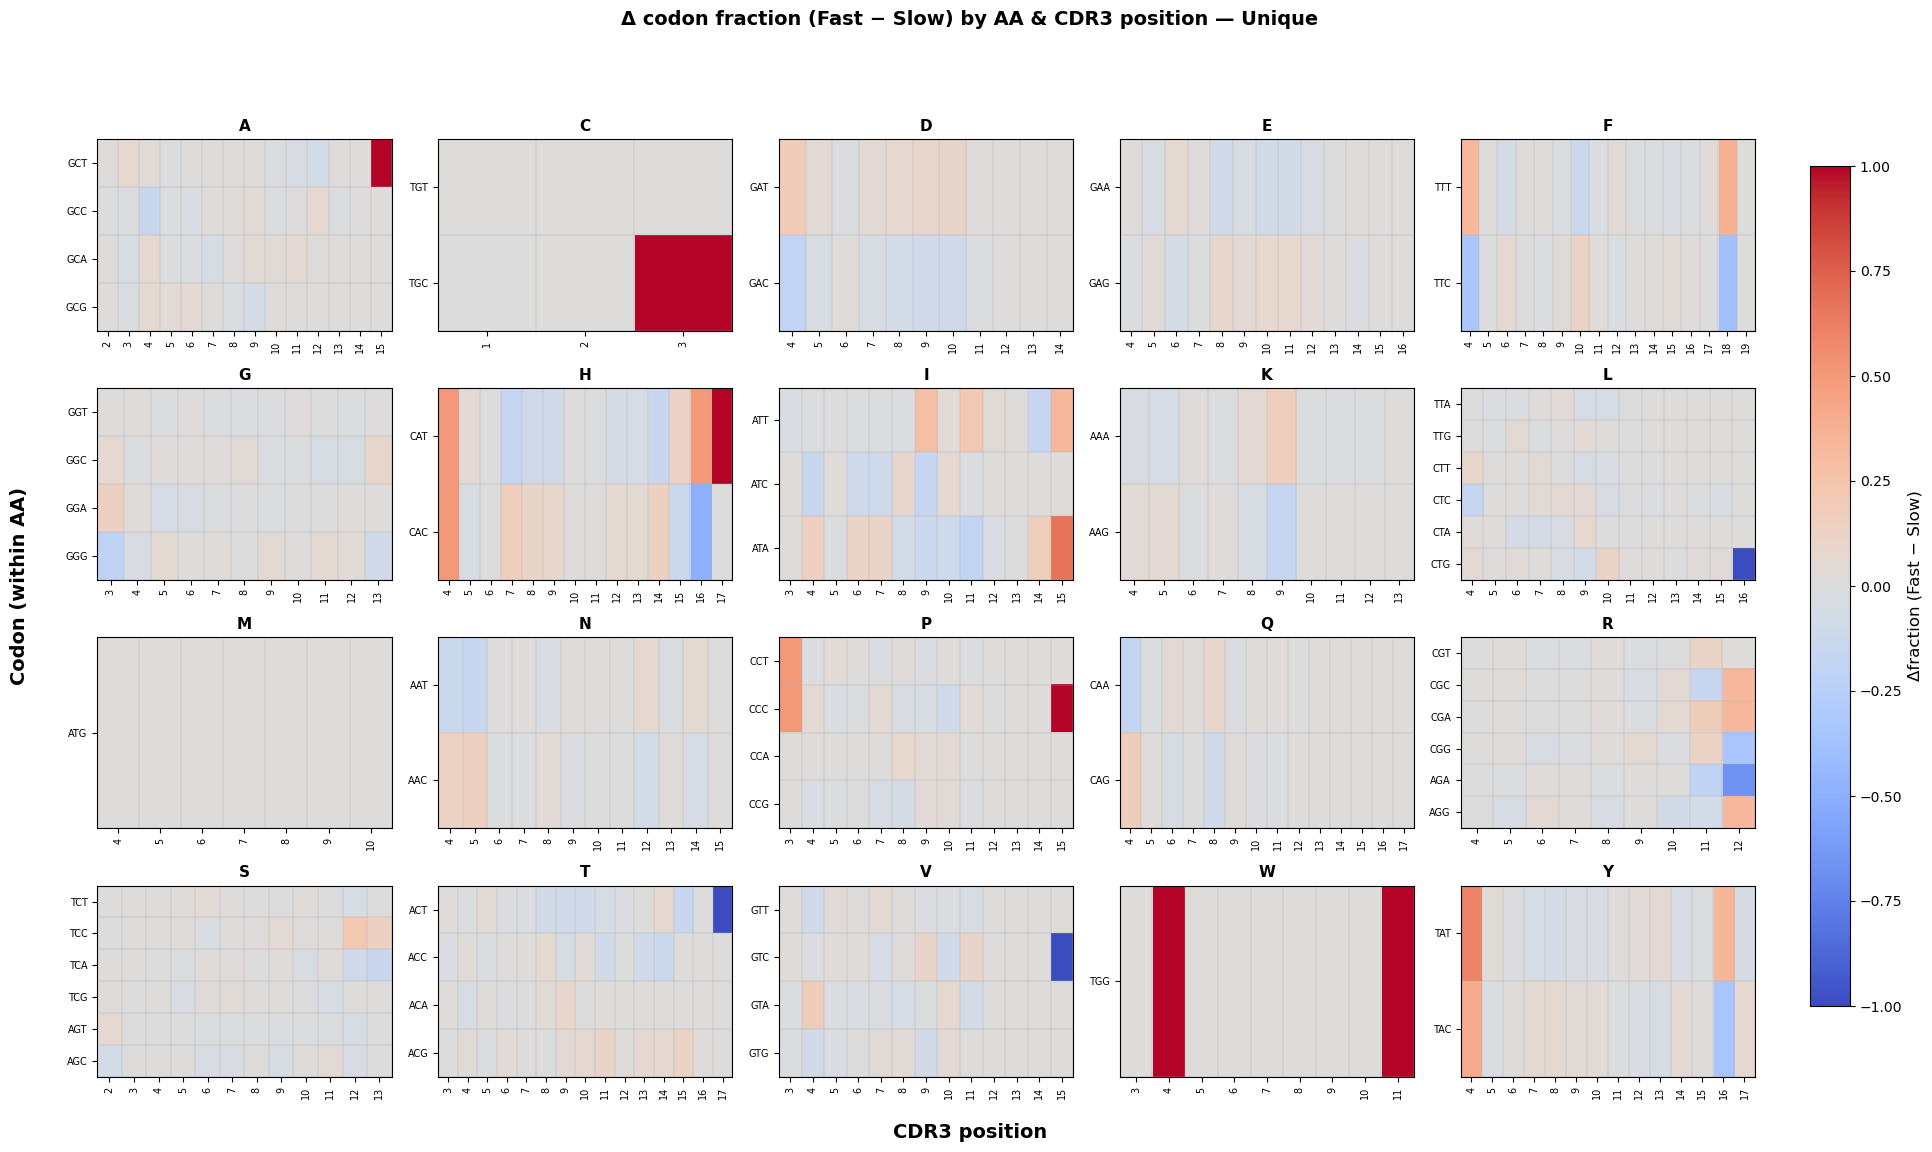

In [ ]:
plot_delta_fraction_heatmap_grid(
    delta_unique,
    title="Delta codon fraction (Immediate - Delayed): group-unique",
    aa_to_codons=AA_TO_CODONS,
    aa_order=AA_ORDER,
    n_cols=5,
    figsize=(20, 12),
    cmap="coolwarm",
    show_colorbar=True,
)


Two complementary metrics were used to characterize synonymous codon usage at each amino-acid position.

**Effective number of codons** measures codon usage constraint within a group:
- low values indicate dominant use of few codons,
- high values indicate more uniform synonymous codon usage.

**Jensen–Shannon (JS) divergence** quantifies differences in codon usage distributions between Immediate and Delayed cohorts:
- JS = 0 indicates identical codon usage,
- higher values indicate increased divergence in codon preference.

Together, these metrics distinguish positional codon constraint from cohort-specific codon usage bias.

In [43]:

# Collapse and compare (between figures): Effective codons + JS divergence heatmaps
metrics_shared = collapse_metrics_by_aa_pos(frac_shared_fast, frac_shared_slow, label="Shared", aa_to_codons=AA_TO_CODONS, aa_order=AA_ORDER)
metrics_unique = collapse_metrics_by_aa_pos(frac_unique_fast, frac_unique_slow, label="Unique", aa_to_codons=AA_TO_CODONS, aa_order=AA_ORDER)
metrics_all = pd.concat([metrics_shared, metrics_unique], ignore_index=True)



/tmp/ipykernel_501051/2167984886.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 0.90, 0.90])


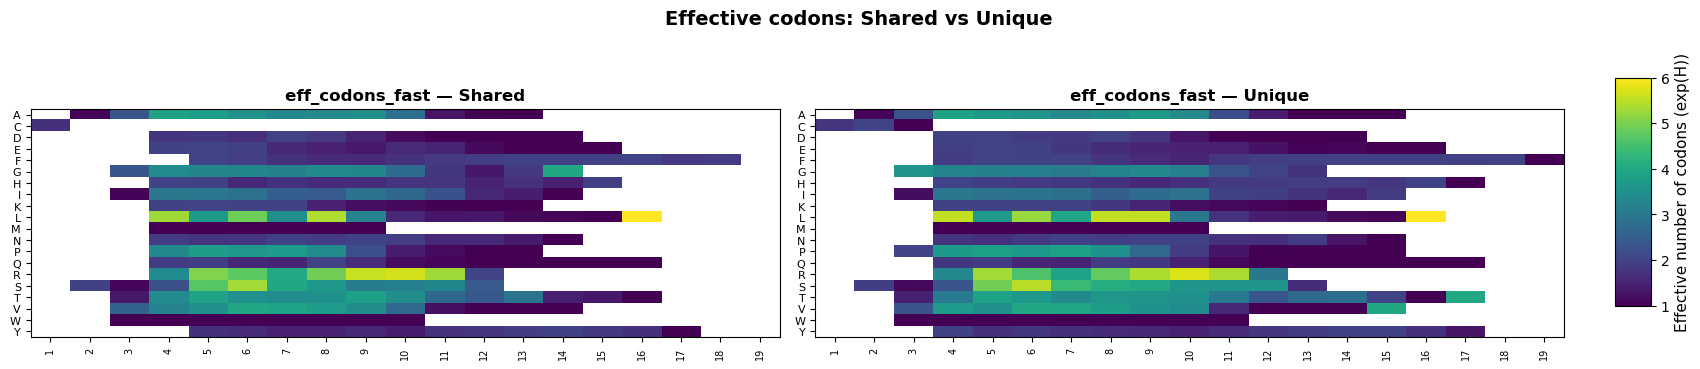

/tmp/ipykernel_501051/2167984886.py:330: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.02, 0.90, 0.90])


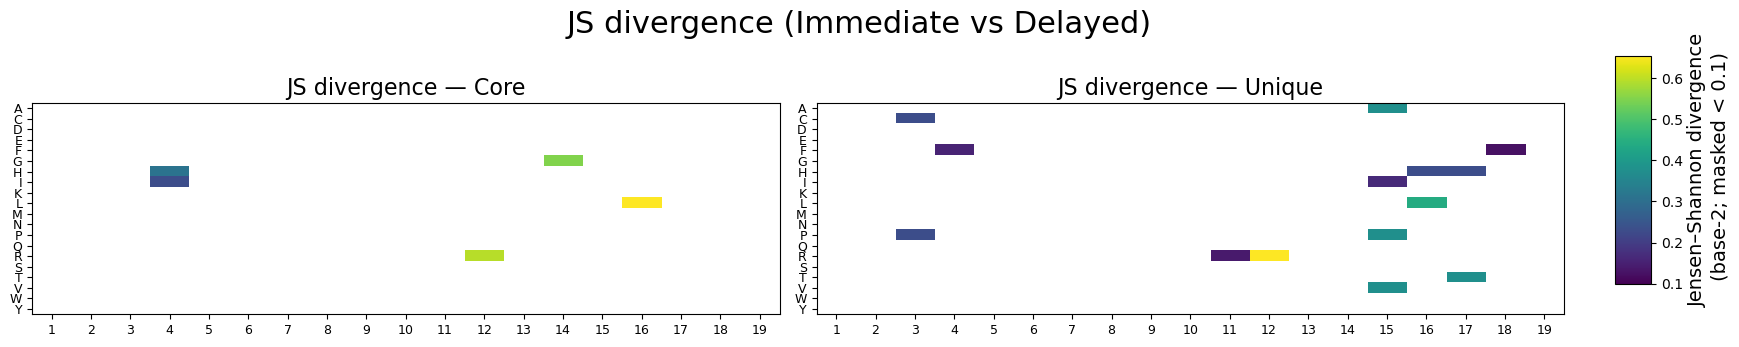

In [165]:
plot_effective_codons_shared_vs_unique(metrics_all, value_col="eff_codons_fast", global_positions=global_positions)

plot_js_divergence_shared_vs_unique(metrics_all, js_threshold=0.1, global_positions=global_positions)


# Figure 8 - Biochemical properties

In [ ]:
# Define Refined Metrics
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Define refined + added metrics
def analyze_sequence_refined(seq: str):
    keys = ["Length","Aromaticity","Isoelectric Point","Hydrophobicity GRAVY",
            "Charge pH7","Charged Fraction","Proline Fraction", "AA Shannon Entropy"]
    try:
        seq = str(seq)
        L = len(seq)
        if L == 0:
            return {k: np.nan for k in keys}

        prot = ProteinAnalysis(seq)

        # simple composition-based features
        aa_percent = prot.amino_acids_percent
        aa_values = np.array(list(aa_percent.values()), dtype=float)

        if aa_values.sum() > 1.5:
            aa_frac = {aa: val / 100.0 for aa, val in aa_percent.items()}
        else:
            aa_frac = aa_percent

        # charged residue fraction: K,R,D,E
        charged_frac = (
            aa_frac.get("K", 0.0) + aa_frac.get("R", 0.0) +
            aa_frac.get("D", 0.0) + aa_frac.get("E", 0.0)
        )

        # Shannon entropy of AA composition (natural log)
        p = np.array(list(aa_frac.values()), dtype=float)
        p = p[p > 0]
        aa_entropy = float(-(p * np.log(p)).sum()) if p.size else 0.0

        return {
            "Length": L,
            "Aromaticity": prot.aromaticity(),
            "Isoelectric Point": prot.isoelectric_point(),
            "Hydrophobicity GRAVY": prot.gravy(),
            "Charge pH7": prot.charge_at_pH(7.0),
            "Charged Fraction": charged_frac,
            "AA Shannon Entropy": aa_entropy,
        }

    except Exception:
        return {k: np.nan for k in keys}

def build_biochem_df(aa_list, label):
    # Analyze
    records = [analyze_sequence_refined(seq) for seq in aa_list]
    df = pd.DataFrame(records)
    df["Group"] = label
    # Add the sequence back for reference if needed
    df["aaSeqCDR3"] = list(aa_list)
    return df

THRESH = 3 

In [ ]:
# match -> downsample -> define shared/unique
READ_COL = "readCount"   
PUBLICNESS_THRESHOLD = 3                

# Match fast to slow by (log) total reads, keep paired samples
clonotype_df_matched = match_fast_to_slow_by_reads(
    clonotype_df=clonotype_df,
    read_col=READ_COL,
    match_on="log",
)

# downsampling depth: lowest total reads across matched samples (both groups)
sample_totals_matched = (
    clonotype_df_matched.groupby(["Sample_ID", "group"], as_index=False)[READ_COL]
    .sum()
    .rename(columns={READ_COL: "total_reads"})
)
target_reads = int(sample_totals_matched["total_reads"].min())

print(f"Matched samples: fast={sample_totals_matched[sample_totals_matched['group']=='fast']['Sample_ID'].nunique()}, "
      f"slow={sample_totals_matched[sample_totals_matched['group']=='slow']['Sample_ID'].nunique()}")
print(f"Downsampling each sample to target_reads={target_reads}")


Matched samples: fast=58, slow=58
Downsampling each sample to target_reads=209378


In [ ]:
# 3) Downsample within each sample to target_reads
clonotype_df_down = downsample_reads_within_sample_multinomial(
    df=clonotype_df_matched,
    read_col=READ_COL,
    target_reads=target_reads,
    seed=0,
    out_col="ds_reads",
)

# 4) Define shared/unique sets AFTER matching+downsampling
shared_set_std, unique_fast_set_std, unique_slow_set_std, df_counts_std = (
    define_shared_unique_sets_after_downsampling(
        df_down=clonotype_df_down,
        thresh=PUBLICNESS_THRESHOLD,
        ds_col="ds_reads",
    )
)

print(f"shared_set_std: {len(shared_set_std)}")
print(f"unique_fast_set_std: {len(unique_fast_set_std)}")
print(f"unique_slow_set_std: {len(unique_slow_set_std)}")


In [120]:
df_shared = build_biochem_df(shared_set_std, "Shared")
df_fast = build_biochem_df(unique_fast_set_std, "Unique Fast")
df_slow = build_biochem_df(unique_slow_set_std, "Unique Slow")

# Combine
biochem_master_std = pd.concat([df_shared, df_fast, df_slow], ignore_index=True)
biochem_master_std = biochem_master_std.dropna(subset=["Length", "Isoelectric Point"])


We compared biochemical properties of shared/CORE clonotypes against group-unique clonotypes using two-sided Mann-Whitney U tests, with Benjamini-Hochberg FDR correction across metrics.


In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def compute_biochem_pairwise_pvals(
    biochem_master: pd.DataFrame,
    metrics: list,
    group_col: str = "Group",
    shared_label: str = "Shared",
    fast_label: str = "Unique Fast",
    slow_label: str = "Unique Slow",
    apply_fdr: bool = True,
):
    rows = []

    for metric in metrics:
        x = biochem_master.loc[biochem_master[group_col] == shared_label, metric].dropna().values
        y_fast = biochem_master.loc[biochem_master[group_col] == fast_label, metric].dropna().values
        y_slow = biochem_master.loc[biochem_master[group_col] == slow_label, metric].dropna().values

        # two-sided Mann–Whitney U
        p_sf = np.nan
        p_ss = np.nan
        if len(x) > 0 and len(y_fast) > 0:
            _, p_sf = mannwhitneyu(x, y_fast, alternative="two-sided")
        if len(x) > 0 and len(y_slow) > 0:
            _, p_ss = mannwhitneyu(x, y_slow, alternative="two-sided")

        rows.append({
            "metric": metric,
            "p_shared_vs_fast": p_sf,
            "p_shared_vs_slow": p_ss,
        })

    out = pd.DataFrame(rows)

    if apply_fdr:
        # FDR separately within each comparison family across metrics
        for pcol, qcol in [
            ("p_shared_vs_fast", "q_shared_vs_fast"),
            ("p_shared_vs_slow", "q_shared_vs_slow"),
        ]:
            pvals = out[pcol].to_numpy(dtype=float)
            q = np.full_like(pvals, np.nan, dtype=float)
            valid = np.isfinite(pvals)
            if valid.any():
                _, q_valid, _, _ = multipletests(pvals[valid], method="fdr_bh")
                q[valid] = q_valid
            out[qcol] = q

    return out


In [122]:
VIOLIN_METRICS = [
    "Aromaticity",
    "Isoelectric Point",
    "Hydrophobicity GRAVY",
    "Charge pH7",
    "AA Shannon Entropy",
    "Charged Fraction"
]

HISTOGRAM_METRICS = [
    "Length"
]

metrics = VIOLIN_METRICS + HISTOGRAM_METRICS

In [ ]:
biochem_p_stats_df = compute_biochem_pairwise_pvals(biochem_master_std, metrics, apply_fdr=True)

In [ ]:
from matplotlib.patches import Patch

def plot_biochem_with_pairwise_stats_new(
    biochem_master: pd.DataFrame,
    violin_metrics: list,
    box_metrics: list,
    stats_df: pd.DataFrame,
    group_order: tuple = ("Shared", "Unique Fast", "Unique Slow"),
    group_col: str = "Group",
    show_q_on_plot: bool = False,
):
    # harmonize group names 
    biochem_master = biochem_master.copy()
    biochem_master["Group"] = biochem_master["Group"].replace(
        {"Unique Fast": "Immediate", "Unique Slow": "Delayed"}
    )
    biochem_master[group_col] = biochem_master[group_col].replace(
        {"Unique Fast": "Immediate", "Unique Slow": "Delayed", "Shared": "Core"}
    )

    group_order = ["Core", "Immediate", "Delayed"]
    palette = {
        "Core": "#2ca02c",
        "Immediate": "#1f77b4",
        "Delayed": "#ff7f0e"
    }

    stats_df = stats_df.rename(columns={
        "p_shared_vs_fast": "p_shared_vs_immediate",
        "p_shared_vs_slow": "p_shared_vs_delayed",
        "q_shared_vs_fast": "q_shared_vs_immediate",
        "q_shared_vs_slow": "q_shared_vs_delayed"
    }).set_index("metric")

    #  force Length to be the dedicated histogram metric (remove from other lists if present)
    length_metric = "Length"
    violin_metrics = [m for m in violin_metrics if m != length_metric]
    box_metrics = [m for m in box_metrics if m != length_metric]

    other_hist_metrics = list(box_metrics)

    # layout: 4 columns total
    # col 0 = Length (row 0) + Legend (row 1)
    # cols 1-3 = violins (and optionally other hists) in a 3-col grid
    violin_cols = 3
    violin_items = [(m, "violin") for m in violin_metrics] + [(m, "histogram") for m in other_hist_metrics]
    n_violin = len(violin_items)
    n_violin_rows = int(np.ceil(n_violin / violin_cols)) if n_violin > 0 else 1

    # need at least 2 rows to host legend beneath Length
    nrows = max(n_violin_rows, 2)
    ncols = 1 + violin_cols  # 4 total

    fig = plt.figure(figsize=(12, 4 * nrows), constrained_layout=True)
    gs = fig.add_gridspec(nrows=nrows, ncols=ncols)

    fig.suptitle("Biochemical Properties by Group", fontsize=22)

    # Length panel (top-left)
    ax_len = fig.add_subplot(gs[0, 0])
    if length_metric in biochem_master.columns:
        sns.histplot(data=biochem_master, x=length_metric, hue=group_col, palette=palette, element="step",
                      stat="density", common_norm=False, bins=20, ax=ax_len)
        ax_len.set_title(length_metric, fontsize=16)
        ax_len.set_xlabel("")
        ax_len.set_ylabel(length_metric, fontsize=14)

        # annotate p/q for Length
        if length_metric in stats_df.index:
            p_sf = stats_df.at[length_metric, "p_shared_vs_immediate"]
            p_ss = stats_df.at[length_metric, "p_shared_vs_delayed"]
            q_sf = stats_df.at[length_metric, "q_shared_vs_immediate"]
            q_ss = stats_df.at[length_metric, "q_shared_vs_delayed"]
        else:
            p_sf = p_ss = q_sf = q_ss = np.nan

        if show_q_on_plot:
            line1 = f"Core vs Immediate: q={q_sf:.2e}" if np.isfinite(q_sf) else "Core vs Immediate: q=NA"
            line2 = f"Core vs Delayed: q={q_ss:.2e}" if np.isfinite(q_ss) else "Core vs Delayed: q=NA"
        else:
            line1 = f"Core vs Immediate: p={p_sf:.2e}" if np.isfinite(p_sf) else "Core vs Immediate: p=NA"
            line2 = f"Core vs Delayed: p={p_ss:.2e}" if np.isfinite(p_ss) else "Core vs Delayed: p=NA"

        ax_len.text(
            0.02, 0.98, f"{line1}\n{line2}",
            transform=ax_len.transAxes,
            ha="left", va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"))
    else:
        ax_len.axis("off")

    # Legend cell under Length
    ax_leg = fig.add_subplot(gs[1, 0])
    ax_leg.axis("off")

    legend_handles = [Patch(facecolor=palette[g], edgecolor="none", label=g) for g in group_order]
    ax_leg.legend(
        handles=legend_handles,
            title="Group",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05), 
        frameon=True)

    # ensure no legends remain elsewhere
    for ax in fig.axes:
        if ax is not ax_leg and ax.get_legend() is not None:
            ax.get_legend().remove()
    
    # Populate violin grid
    # Only show x tick labels on the bottom row of the violin grid
    violin_bottom_row = n_violin_rows - 1

    for idx, (metric, plot_type) in enumerate(violin_items):
        r = idx // violin_cols
        c = idx % violin_cols
        ax = fig.add_subplot(gs[r, c + 1])

        if plot_type == "violin":
            sns.violinplot( data=biochem_master, x=group_col, y=metric, order=group_order, inner="box",
                            cut=0, palette=palette, hue="Group", ax=ax)
        else:
            sns.histplot(data=biochem_master,x=metric, hue=group_col, palette=palette, element="step",
                          stat="density", common_norm=False, bins=20, ax=ax)
            # don't keep legends in these panels
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        ax.set_title(metric, fontsize=16)
        ax.set_xlabel("")

        short_label = metric.split()[-1]
        ax.set_ylabel(short_label, fontsize=14)

        # x ticks only on bottom violin row
        if r != violin_bottom_row:
            ax.set_xticklabels([])
        else:
            ax.tick_params(axis="x", labelsize=14)
            plt.setp(ax.get_xticklabels(), rotation=30, ha="center")

        # annotate p/q
        if metric in stats_df.index:
            p_sf = stats_df.at[metric, "p_shared_vs_immediate"]
            p_ss = stats_df.at[metric, "p_shared_vs_delayed"]
            q_sf = stats_df.at[metric, "q_shared_vs_immediate"]
            q_ss = stats_df.at[metric, "q_shared_vs_delayed"]
        else:
            p_sf = p_ss = q_sf = q_ss = np.nan

        if show_q_on_plot:
            line1 = f"Core vs Immediate: q={q_sf:.2e}" if np.isfinite(q_sf) else "Core vs Immediate: q=NA"
            line2 = f"Core vs Delayed: q={q_ss:.2e}" if np.isfinite(q_ss) else "Core vs Delayed: q=NA"
        else:
            line1 = f"Core vs Immediate: p={p_sf:.2e}" if np.isfinite(p_sf) else "Core vs Immediate: p=NA"
            line2 = f"Core vs Delayed: p={p_ss:.2e}" if np.isfinite(p_ss) else "Core vs Delayed: p=NA"

        ax.text(
            0.02, 0.98, f"{line1}\n{line2}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none")
        )

    # Turn off any unused cells
    for rr in range(2, nrows):
        ax_empty = fig.add_subplot(gs[rr, 0])
        ax_empty.axis("off")
    
    save_plot("biochemical_pvalue_new.svg", format="svg", bbox_inches="tight")
    plt.show()



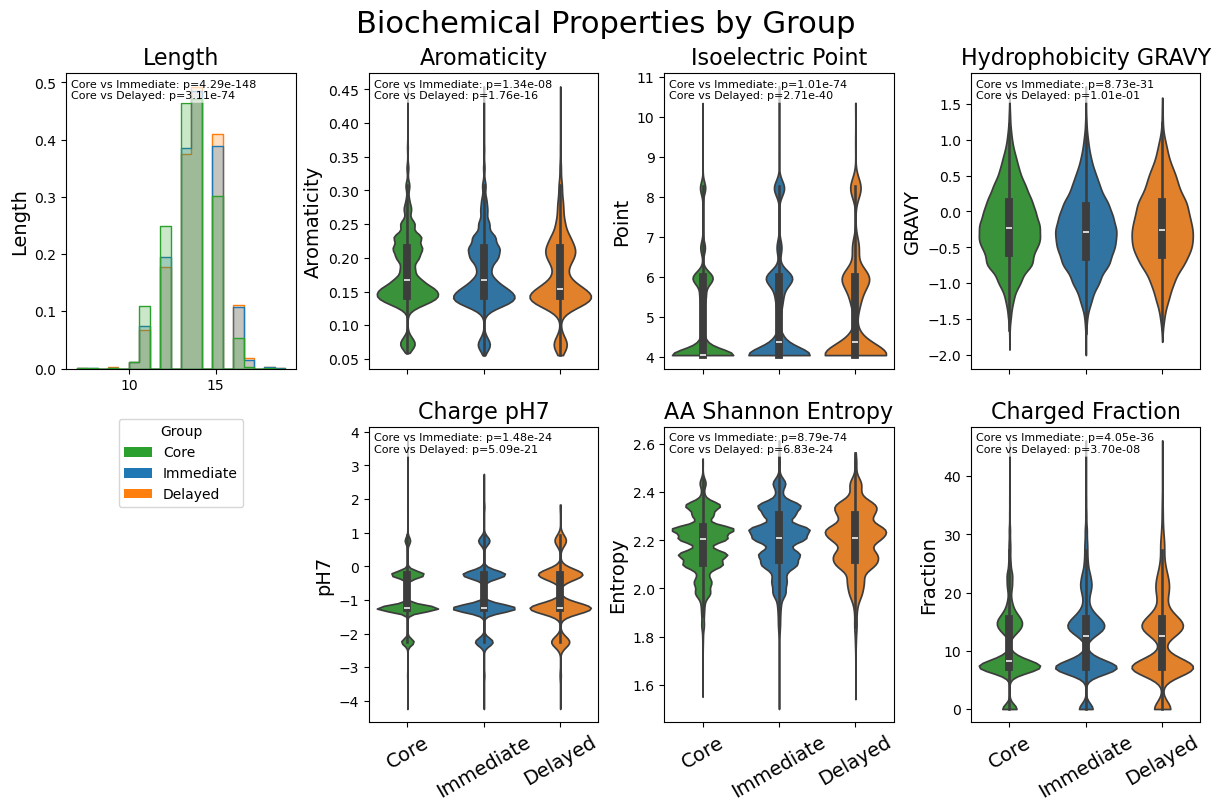

In [125]:
plot_biochem_with_pairwise_stats_new(biochem_master_std, VIOLIN_METRICS, HISTOGRAM_METRICS, biochem_p_stats_df, show_q_on_plot=False)

# Figure 9 — CORE clonotype network and antigen association analyses

In [ ]:
FAST_R = 0.85
SLOW_R = 0.87
CORR_PUB_THRESHOLD = 3

In [ ]:
import networkx as nx

def load_corr(clonotype_df, threshold=5):
    # A narrow view ONLY for the survivor/qualification logic
    logic_df = clonotype_df[['Sample_ID','group','aaSeqCDR3']].dropna(subset=['aaSeqCDR3','group'])
    # survivors: AA present in BOTH groups
    presence = (logic_df.groupby(['aaSeqCDR3','group'])['Sample_ID']
                        .size().unstack(fill_value=0))
    survivors = presence.index[(presence.get('fast',0) > 0) & (presence.get('slow',0) > 0)]
    survivor_df = clonotype_df[clonotype_df['aaSeqCDR3'].isin(survivors)].copy()  # keeps ALL columns

    counts = (survivor_df.groupby(['aaSeqCDR3','group'])['Sample_ID']
            .nunique().unstack(fill_value=0))
    qualified_tcrs = counts[(counts.get('fast',0) >= threshold) &
                            (counts.get('slow',0) >= threshold)].index

    # keep these objects with ALL columns 
    qualified_df = clonotype_df[clonotype_df['aaSeqCDR3'].isin(qualified_tcrs)].copy()

    fast_df = qualified_df[qualified_df['group'] == 'fast'].copy()
    slow_df = qualified_df[qualified_df['group'] == 'slow'].copy()

    # Expression matrices (needs 'readFraction' present in sub)
    fast_expr = fast_df.pivot_table(index='aaSeqCDR3', columns='Sample_ID',
                                    values='readFraction', fill_value=0)
    slow_expr = slow_df.pivot_table(index='aaSeqCDR3', columns='Sample_ID',
                                    values='readFraction', fill_value=0)

    fast_expr_numpy = fast_expr.to_numpy()
    fast_corr_numpy = np.corrcoef(fast_expr_numpy)
    fast_corr = pd.DataFrame(fast_corr_numpy, index=fast_expr.index, columns=fast_expr.index)

    slow_expr_numpy = slow_expr.to_numpy()
    slow_corr_numpy = np.corrcoef(slow_expr_numpy)
    slow_corr = pd.DataFrame(slow_corr_numpy, index=slow_expr.index, columns=slow_expr.index)
    return fast_df, slow_df, fast_corr, slow_corr

In [ ]:
def intersection_graph_with_weights(G1, G2, attr1='weight', attr2='weight', new_attr1='fast_weight', new_attr2='slow_weight'):
    """
    Returns a new graph with only edges present in both G1 and G2.
    Edge attributes from G1 and G2 are preserved as new_attr1 and new_attr2.
    Only nodes with at least one shared edge will be included.
    """
    G_inter = nx.Graph()
    # Create sets of edges as (nodeA, nodeB) sorted tuples for undirected comparison
    edges1 = set(tuple(sorted(e)) for e in G1.edges())
    edges2 = set(tuple(sorted(e)) for e in G2.edges())
    shared_edges = edges1 & edges2
    
    for u, v in shared_edges:
        # Copy correlation weights from both graphs
        w1 = G1[u][v][attr1]
        w2 = G2[u][v][attr2]
        G_inter.add_edge(u, v, **{new_attr1: w1, new_attr2: w2})
    return G_inter

def build_pos_corr_graph(corr_matrix, min_r=None):
    """
    Efficiently build a NetworkX graph from a correlation matrix using a threshold.
    Precompute the edge list directly from the correlation matrix (using NumPy or pandas).
    Only adds edges where r >= min_r (positive correlation).
    """
    tcrs = np.array(corr_matrix.index)
    # Get upper triangle indices (excluding diagonal)
    mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
    # Get pairs and correlations
    i_idx, j_idx = np.where(mask)
    corrs = corr_matrix.values[mask]
    if min_r is not None:
        select = np.where(corrs >= min_r)[0]
        i_idx = i_idx[select]
        j_idx = j_idx[select]
        corrs = corrs[select]
    # Build edge list
    edge_list = [
        (tcrs[i], tcrs[j], {'weight': float(corr)})
        for i, j, corr in zip(i_idx, j_idx, corrs)
    ]
    # Create graph
    G = nx.Graph()
    G.add_edges_from(edge_list)
    return G


In [13]:
fast_df, slow_df, fast_corr, slow_corr = load_corr(clonotype_df, threshold=CORR_PUB_THRESHOLD)

In [15]:
G_fast_sub = build_pos_corr_graph(fast_corr, min_r=FAST_R)
G_slow_sub = build_pos_corr_graph(slow_corr, min_r=SLOW_R)
G_overlap = intersection_graph_with_weights(G_fast_sub, G_slow_sub)

In [ ]:
# Get all connected components sorted by size
components = sorted(nx.connected_components(G_overlap), key=len, reverse=True)

largest_cc_nodes = components[0]
G_overlap_lcc_largest = G_overlap.subgraph(largest_cc_nodes).copy()

In [ ]:
print(
    f"Overlap graph: {G_overlap.number_of_nodes()} nodes, "
    f"{G_overlap.number_of_edges()} edges; "
    f"largest component: {G_overlap_lcc_largest.number_of_nodes()} nodes"
)

## Epitope Matching

We used McPAS-TCR to test whether TCRs in the largest overlap-network component were enriched for known antigen-associated TCR neighborhoods. Each network TCR was matched to McPAS entries differing by one amino acid.

In [16]:
import re

def create_tcr_meta(tcr_sequences, fast_df, slow_df):
    """
    Build per-sequence V/J annotations for fast/slow groups, plus sample_prevalence
    and codon_diversity, and map V/J to categorical IDs.

    """
    def clean_vj(gene_str):
        return re.sub(r"\*.*", "", gene_str) if isinstance(gene_str, str) else gene_str

    def mode_or_na(s):
        m = s.mode()
        return m.iat[0] if not m.empty else pd.NA

    vj_map_fast = (
        fast_df.groupby("aaSeqCDR3")
        .agg({
            "allVHitsWithScore": mode_or_na,
            "allJHitsWithScore": mode_or_na,
            "nSeqCDR3": pd.Series.nunique,     # codon diversity
            "Sample_ID": pd.Series.nunique     # sample prevalence
        })
        .rename(columns={
            "allVHitsWithScore": "V_gene_fast",
            "allJHitsWithScore": "J_gene_fast",
            "nSeqCDR3": "codon_diversity_fast",
            "Sample_ID": "sample_prevalence_fast"
        })
    )

    vj_map_slow = (
        slow_df.groupby("aaSeqCDR3")
        .agg({
            "allVHitsWithScore": mode_or_na,
            "allJHitsWithScore": mode_or_na,
            "nSeqCDR3": pd.Series.nunique,
            "Sample_ID": pd.Series.nunique
        })
        .rename(columns={
            "allVHitsWithScore": "V_gene_slow",
            "allJHitsWithScore": "J_gene_slow",
            "nSeqCDR3": "codon_diversity_slow",
            "Sample_ID": "sample_prevalence_slow"
        })
    )
    # Clean allele fields
    for col in ("V_gene_fast", "J_gene_fast"):
        if col in vj_map_fast:
            vj_map_fast[col] = vj_map_fast[col].apply(clean_vj)
    for col in ("V_gene_slow", "J_gene_slow"):
        if col in vj_map_slow:
            vj_map_slow[col] = vj_map_slow[col].apply(clean_vj)

    # base df from sequences 
    out = pd.DataFrame({"cdr3_sequence": list(tcr_sequences)})
    out = (
        out
        .merge(vj_map_fast, how="left", left_on="cdr3_sequence", right_index=True)
        .merge(vj_map_slow, how="left", left_on="cdr3_sequence", right_index=True))
    # final column order
    out = out[[
        "cdr3_sequence",
        "V_gene_fast", 
        "J_gene_fast",
        "sample_prevalence_fast", "codon_diversity_fast",
        "V_gene_slow",
        "J_gene_slow",
        "sample_prevalence_slow", "codon_diversity_slow",
    ]]

    return out

In [ ]:
mcpas = pd.read_csv("McPAS-TCR.csv")

McPAS-TCR was restricted to human TCRβ entries.

In [ ]:
mcpas = mcpas[mcpas["Species"] == "Human"].copy()

,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,Single.cell,NGS,...,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
0,NaN,ATSIRFTDTQYF,Human,Autoimmune,Celiac disease,D002503,6 days post oral gluten\nchallenge,1.0,Yes,Yes,...,TRAV8-6,NaN,TRBV7-2,NaN,TRBJ2-3,NaN,NaN,NaN,23878218,NaN
1,NaN,CAAAAASGAYEQYF,Human,Pathogens,M.Tuberculosis,D009169,Bulk,2.2,No,Yes,...,NaN,NaN,TRBV10-3,NaN,NaN,NaN,NaN,NaN,32341563,NaN
2,NaN,CAAADEEIGNQPQHF,Human,Pathogens,Hepatitis C virus,D016174,NaN,1.0,No,No,...,NaN,NaN,TRBV10-03,NaN,NaN,No,NaN,NaN,21160049,NaN
3,CAVRDSNYQLIW,CAAAGGPDTGELFF,Human,Pathogens,M. tuberculosis,D009169,NaN,2.2,Yes,Yes,...,NaN,TRAJ33,TRBV6-1,NaN,TRBJ2-2,NaN,NaN,NaN,30992377,NaN
4,NaN,CAAEDDTGGFKTIF,Human,Pathogens,Influenza,D009980,NaN,1.0,Yes,Yes,...,TRAV8-4:03,TRAJ45:01,TRBV25:01,NaN,TRBJ9:01,No,NaN,NaN,28300170,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40726,NaN,CASSPKRTRQLSIS,Human,Autoimmune,ARDS,D012128,Acute Respiratory Distress Syndrome,NaN,No,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37238695,TRBJ not suplied
40727,NaN,CASSPTRPAARRLS,Human,Autoimmune,ARDS,D012128,Acute Respiratory Distress Syndrome,NaN,No,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37238695,TRBJ not suplied
40728,NaN,CASSTRQLFTSVPP,Human,Autoimmune,ARDS,D012128,Acute Respiratory Distress Syndrome,NaN,No,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37238695,TRBJ not suplied
40729,NaN,CASSTPPAARRLGP,Human,Autoimmune,ARDS,D012128,Acute Respiratory Distress Syndrome,NaN,No,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37238695,TRBJ not suplied


In [19]:
g_lcc_nodes = list(G_overlap_lcc_largest.nodes())
meta_largest = create_tcr_meta(g_lcc_nodes, fast_df, slow_df)

In [ ]:
def hamming_distance(s1, s2):
    if len(s1) != len(s2):
        return None
    return sum(a != b for a, b in zip(s1, s2))

# For each query TCR, find all hits with a Hamming distance of 1
def find_single_mutation_hits(query_seq, db_df, db_col='CDR3.beta.aa'):
    # Only compare to sequences of same length
    # Drop missing / non-string entries safely
    s = db_df[db_col]
    valid = s.notna()
    same_len = valid & (s.str.len() == len(query_seq))
    cand = db_df.loc[same_len].copy()
    # ensure query_seq is str
    query_seq = str(query_seq)

    mask = cand[db_col].apply(lambda x: hamming_distance(x, query_seq) == 1)
    return cand.loc[mask]

def match_queries_to_mcpas_1aa(queries, mcpas_df: pd.DataFrame, db_col="CDR3.beta.aa"):
    """
    Returns a tidy long table with one row per (query, matched_public_tcr, epitope, ...).
    """
    results = []
    queries = pd.Series(list(queries)).dropna().astype(str).unique()

    for q in queries:
        hits = find_single_mutation_hits(q, mcpas_df, db_col=db_col)
        for _, row in hits.iterrows():
            results.append({
                "query": q,
                "match": row.get(db_col, None),
                "epitope": row.get("Epitope.peptide", None),
                "antigen_pathology": row.get("Pathology", None), 
                "host_species": row.get("Species", None),
                "category": row.get("Category", None),
                "antigen_protein": row.get("Antigen.protein", None),
                "mhc": row.get("MHC", None),
                "reference_id": row.get("PubMed.ID", None),
            })

    out = pd.DataFrame(results)
    if out.empty:
        return out

    # Drop exact duplicates if McPAS has repeated identical evidence rows
    out = out.drop_duplicates(subset=["query", "match", "epitope", "reference_id"])
    return out


In [ ]:
def plot_one_near_match(results, tcr_db, tcr_column='cdr3_sequence'):
    results__df = pd.DataFrame(results)
    n_with_hits = results__df['query'].nunique()
    n_total = tcr_db[tcr_column].nunique() 

    print(f"{n_with_hits}/{n_total} TCRs have a single-a.a. variant hit ({100*n_with_hits/n_total:.1f}%)")

    plt.bar(['Matched', 'Not matched'], [n_with_hits, n_total - n_with_hits], color=['green','gray'])
    plt.title("Fraction of TCRs with 1-a.a. variant hit")
    plt.ylabel("Number of TCRs")
    plt.show()

def print_epitope_hits_per_tcr_with_variants(results):
    results_df = pd.DataFrame(results)
    print("Epitope hits per original TCR (showing variant sequence for each epitope):")
    print("=" * 80)
    grouped = results_df.groupby('query')
    for tcr, group in grouped:
        print(f"Original TCR: {tcr}")
        if group['epitope'].notna().any():
            # group by epitope to get all variant TCRs that led to each one
            epitope_groups = group.groupby('epitope')
            for epitope, ep_group in epitope_groups:
                if pd.isna(epitope):
                    continue
                variants = ep_group['match'].unique()
                for variant in variants:
                    print(f"   Epitope: {epitope}  |  Variant TCR: {variant}")
        else:
            print("   No epitope found.")
        print("-" * 80)

def print_and_plot_hit_epitopes(results, top_n=10):
    results_df = pd.DataFrame(results)
    # Keep only rows with epitope information
    df = results_df.dropna(subset=["epitope"])
    epitope_pathology = (
        df.groupby("epitope")["antigen_pathology"]
        .agg(lambda x: x.dropna().iloc[0] if x.notna().any() else "Unknown")
    )
    # Count hits per epitope
    epitope_counts = df["epitope"].value_counts().head(top_n)
    # Build display labels
    labels = [
        f"{epi}\n({epitope_pathology.get(epi, 'Unknown')})"
        for epi in epitope_counts.index
    ]

    # Plot
    plt.figure(figsize=(10, 4))
    plt.bar(labels, epitope_counts.values, color="steelblue")
    plt.title("Most Frequently Matched Epitope", fontsize=20)
    plt.ylabel("Count", fontsize=16)
    plt.xlabel("Epitope Tracking", fontsize=16)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()

    save_plot("epitope_and_pathology_hits.svg", format="svg", bbox_inches="tight")
    plt.show()

    # list all unique hit epitopes
    all_unique = df["epitope"].unique()
    print("\nAll unique hit epitopes found:")
    print(", ".join(map(str, all_unique)))


def plot_epitope_source_dist(results):
    results_df = pd.DataFrame(results)
    species_counts = results_df['antigen_pathology'].value_counts().head(10)
    plt.figure(figsize=(8,4))
    species_counts.plot(kind='bar')
    plt.title("Top Antigen Pathology for 1-a.a. Variant Matches")
    plt.ylabel("Number of matches")
    plt.xlabel("Antigen Species")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
# Observed McPAS 1-aa matches for the largest overlap-network component
results_largest_mcpas = match_queries_to_mcpas_1aa(
    queries=meta_largest["cdr3_sequence"],
    mcpas_df=mcpas,
    db_col="CDR3.beta.aa"
)

print(
    f"Observed LCC TCRs: {meta_largest['cdr3_sequence'].nunique()} | "
    f"1-aa McPAS matches: {len(results_largest_mcpas)} | "
    f"unique matched epitopes: {results_largest_mcpas['epitope'].nunique(dropna=True)}"
)

In [ ]:
print_and_plot_hit_epitopes(results_largest_mcpas)
plot_epitope_source_dist(results_largest_mcpas)

In [ ]:
def plot_hits_and_epitope_diversity_grouped(
    results,
    tcr_db,
    tcr_column="cdr3_sequence",
    sort_by="hits",   # "hits"/"epitopes"/None
    top_n=None,
    title="Epitope recognition breadth"
):
    results_df = pd.DataFrame(results)

    # Universe of queries (include zero-hit TCRs)
    queries = pd.Index(tcr_db[tcr_column].dropna().astype(str).unique(), name="query")

    # Hits per query
    hits = results_df.groupby("query").size().reindex(queries, fill_value=0).astype(int)

    # Unique epitopes per query
    epi = (results_df.dropna(subset=["epitope"])
                    .groupby("query")["epitope"]
                    .nunique()
                    .reindex(queries, fill_value=0)
                    .astype(int))

    plot_df = pd.DataFrame({"hits": hits, "unique_epitopes": epi})

    # Sorting
    if sort_by == "hits":
        plot_df = plot_df.sort_values(["hits", "unique_epitopes"], ascending=False)
    elif sort_by == "epitopes":
        plot_df = plot_df.sort_values(["unique_epitopes", "hits"], ascending=False)

    if top_n is not None:
        plot_df = plot_df.head(top_n)

    x = np.arange(len(plot_df))
    width = 0.42

    plt.figure(figsize=(max(10, 0.5 * len(plot_df)), 4.5))
    plt.bar(x - width/2, plot_df["hits"].values, width=width, label="Total hits")
    plt.bar(x + width/2, plot_df["unique_epitopes"].values, width=width, label="Unique epitopes")

    plt.xticks(x, plot_df.index.astype(str), rotation=60, ha="center", fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylabel("Count", fontsize=16)
    plt.xlabel("TCR", fontsize=16)
    plt.title(title, fontsize=20)
    plt.legend(frameon=False, fontsize=14)
    plt.tight_layout()
    save_plot("epitope_hits_vs_diversity.svg", format="svg", bbox_inches="tight")
    plt.show()

    return plot_df


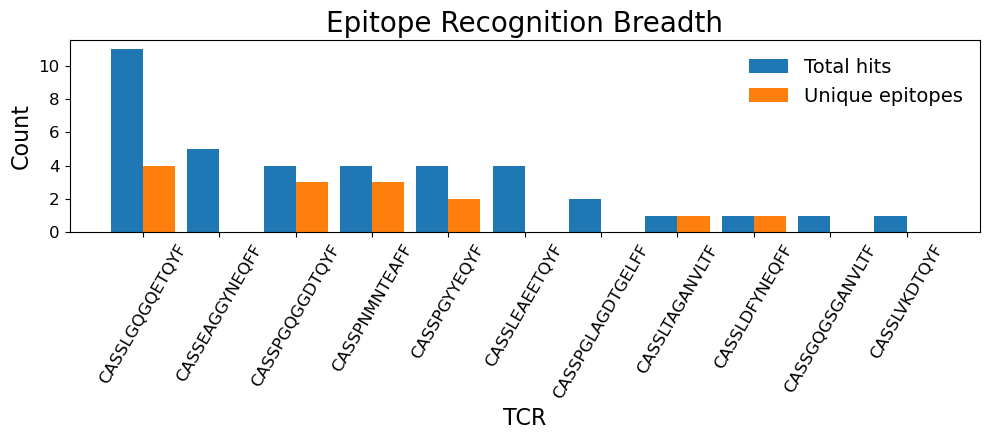

In [ ]:
plot_df = plot_hits_and_epitope_diversity_grouped(
    results=results_largest_mcpas,
    tcr_db=meta_largest,
    tcr_column="cdr3_sequence",
    sort_by="hits",
    title="Epitope Recognition Breadth")

### Random Sampling

We compared the observed network component against random public TCR sets of the same size using an empirical one-sided null distribution.


In [ ]:
from tqdm import tqdm

def compute_epitope_metrics(matched_df: pd.DataFrame, original_epitopes=None):
    if matched_df is None or matched_df.empty:
        metrics = {
            "n_hits": 0,
            "n_unique_epitopes": 0,
            "n_antigen_pathologies": 0,
            "n_antigen_proteins": 0,
            "n_mhc_types": 0,
        }
        if original_epitopes is not None:
            metrics["epitope_overlap_with_original"] = 0
        return metrics

    metrics = {
        "n_hits": int(len(matched_df)),
        "n_unique_epitopes": int(matched_df["epitope"].nunique(dropna=True)),
        "n_antigen_pathologies": int(matched_df["antigen_pathology"].nunique(dropna=True)),
        "n_antigen_proteins": int(matched_df["antigen_protein"].nunique(dropna=True)),
        "n_mhc_types": int(matched_df["mhc"].nunique(dropna=True)),
    }

    if original_epitopes is not None:
        matched_epitopes = set(matched_df["epitope"].dropna())
        metrics["epitope_overlap_with_original"] = int(len(matched_epitopes & set(original_epitopes)))

    return metrics

def sample_random_tcrs(clonotype_df: pd.DataFrame, n: int, rng: np.random.Generator, cdr3_col="aaSeqCDR3"):
    """
    Returns a 1-column DataFrame with aaSeqCDR3 only.
    """
    if cdr3_col not in clonotype_df.columns:
        raise ValueError(f"Expected column {cdr3_col!r} in clonotype_df")

    pool = clonotype_df[cdr3_col].dropna().astype(str).drop_duplicates()
    if len(pool) < n:
        raise ValueError(f"Pool too small: need {n}, have {len(pool)} unique CDR3s")

    sampled = rng.choice(pool.to_numpy(), size=n, replace=False)
    return pd.DataFrame({cdr3_col: sampled})


def run_random_sampling_mcpas(
    pool_df: pd.DataFrame,
    mcpas_df: pd.DataFrame,
    n_iter: int,
    group_size: int,
    original_epitopes,
    seed: int = 0,
    pool_cdr3_col: str = "aaSeqCDR3",
    mcpas_cdr3_col: str = "CDR3.beta.aa",
):
    """
    Function Goals:
      - sample group_size random CDR3s from pool_df, n_iter times
      - run 1-aa McPAS matching
      - compute metrics per iteration
    Returns: metrics_df, all_matches_df
    """
    rng = np.random.default_rng(seed)

    metrics_rows = []
    matched_rows = []

    for it in tqdm(range(n_iter), desc="Random sampling (McPAS 1-aa)"):
        sample_df = sample_random_tcrs(pool_df, n=group_size, rng=rng, cdr3_col=pool_cdr3_col)
        queries = sample_df[pool_cdr3_col].tolist()

        matched = match_queries_to_mcpas_1aa(queries, mcpas_df, db_col=mcpas_cdr3_col)
        matched["iteration"] = it
        matched_rows.append(matched)

        metrics = compute_epitope_metrics(matched, original_epitopes=original_epitopes)
        metrics["iteration"] = it
        metrics_rows.append(metrics)

    metrics_df = pd.DataFrame(metrics_rows)
    all_matches_df = pd.concat(matched_rows, ignore_index=True) if matched_rows else pd.DataFrame()
    return metrics_df, all_matches_df


def get_public_tcr_pool(clonotype_df, min_samples=5):
    """Return a filtered clonotype_df of only TCRs with at least min_samples unique sample occurrences."""
    tcr_publicity = (
        clonotype_df.groupby('aaSeqCDR3')['Sample_ID']
        .nunique()
        .reset_index(name='sample_count')
        .query(f'sample_count >= {min_samples}')
    )

    return clonotype_df[clonotype_df['aaSeqCDR3'].isin(tcr_publicity['aaSeqCDR3'])]

In [33]:
# Precompute once
public_clonotype_df = get_public_tcr_pool(clonotype_df, min_samples=CORR_PUB_THRESHOLD)

In [ ]:
# Original group
original_matches = match_queries_to_mcpas_1aa(
    queries=meta_largest["cdr3_sequence"],
    mcpas_df=mcpas,
    db_col="CDR3.beta.aa"
)

original_epitopes = set(original_matches["epitope"].dropna())
original_metrics = compute_epitope_metrics(original_matches, original_epitopes=original_epitopes)
group_clonotype_size = meta_largest["cdr3_sequence"].nunique()
# Random groups (group_clonotype_size)
random_metrics_df, random_matches_df = run_random_sampling_mcpas(
    pool_df=public_clonotype_df, 
    mcpas_df=mcpas,
    n_iter=500,
    group_size=group_clonotype_size,
    original_epitopes=original_epitopes,
    seed=42,
    pool_cdr3_col="aaSeqCDR3",
    mcpas_cdr3_col="CDR3.beta.aa",
)


Random sampling (McPAS 1-aa): 100%|██████████| 500/500 [10:34<00:00,  1.27s/it]


### Random-sampling summary plots

In [ ]:
def empirical_pvalue(random_vals, observed, alternative="greater"):
    random_vals = np.asarray(random_vals)
    n = random_vals.size

    if alternative == "greater":
        p = (np.sum(random_vals >= observed) + 1) / (n + 1)
    elif alternative == "less":
        p = (np.sum(random_vals <= observed) + 1) / (n + 1)
    elif alternative == "two-sided":
        center = np.median(random_vals)
        dist_obs = abs(observed - center)
        p = (np.sum(np.abs(random_vals - center) >= dist_obs) + 1) / (n + 1)
    else:
        raise ValueError("alternative must be 'greater', 'less', or 'two-sided'")
    return float(p)




In [ ]:
def plot_null_ecdf(random_metrics_df, original_metrics, metric_key,
                   alternative="greater", title=None):
    vals = np.sort(random_metrics_df[metric_key].dropna().to_numpy())
    obs = float(original_metrics[metric_key])
    n = len(vals)

    p = empirical_pvalue(vals, obs, alternative=alternative)
    y = np.arange(1, n + 1) / n

    plt.figure(figsize=(6.5, 4))
    plt.plot(vals, y)
    plt.axvline(obs, linestyle="--", label=f"Observed ({obs:.2f})")
    plt.title(title or f"ECDF under null: {metric_key}")
    plt.xlabel(metric_key)
    plt.ylabel("ECDF")
    plt.legend(frameon=False)

    # Percentile annotation
    perc = (np.sum(vals <= obs) / n) * 100
    plt.gcf().text(0.68, 0.20, f"n={n}\npercentile={perc:.1f}\nempirical p={p:.4g}",
                   fontsize=10)

    plt.tight_layout()
    plt.show()

    return {"p": p, "percentile": float(perc)}

def plot_metric_scatter(random_metrics_df, original_metrics, x_metric, y_metric, title=None, x_title=None, y_title=None):
    x = random_metrics_df[x_metric].to_numpy()
    y = random_metrics_df[y_metric].to_numpy()

    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.4, s=15)
    plt.scatter([original_metrics[x_metric]], [original_metrics[y_metric]], s=80, label="Observed")
    plt.xlabel(x_title if x_title is not None else x_metric.replace('_', ' ').title(), fontsize=16)
    plt.ylabel(y_title if y_title is not None else y_metric.replace('_', ' ').title(), fontsize=16)
    plt.title(title or f"{y_metric} vs {x_metric} (null + observed)", fontsize = 20)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(frameon=False, fontsize=14, handletextpad=0.2,scatterpoints=1)
    plt.tight_layout()
    save_plot(f"{title}.svg", format="svg", bbox_inches="tight")
    plt.show()


def plot_bar_with_empirical_p(random_metrics_df, original_metrics, metric_key,
                              alternative="greater", title=None, y_title=None):
    """
    Paper-style summary plot:
    - bar for observed
    - bar for random mean
    - empirical one-sided p-value computed from actual random sample size
    """
    obs = float(original_metrics[metric_key])
    vals = random_metrics_df[metric_key].dropna().to_numpy()
    n = len(vals)
    if n == 0:
        raise ValueError(f"No values found for metric_key={metric_key!r} in random_metrics_df")

    if alternative == "greater":
        p = (np.sum(vals >= obs) + 1) / (n + 1)
    elif alternative == "less":
        p = (np.sum(vals <= obs) + 1) / (n + 1)
    else:
        raise ValueError("alternative must be 'greater' or 'less'")

    mean_null = float(np.mean(vals))
    std_null = float(np.std(vals, ddof=1)) # Sample Standard Deviation
    
    # Plot the "Observed" bar ALONE (No error params)
    bar1 = plt.bar(["Observed"], [obs], color="#ce5a5a")
    
    # Plot the "Random" bar ALONE (With error params)
    bar2 = plt.bar(["Random mean"], [mean_null], 
                   yerr=std_null, 
                   capsize=10,    # Cap only appears here
                   color="#649fc9")

    # Combine bars list for text labeling loop
    bars = list(bar1) + list(bar2)

    plt.xticks(fontsize=16)  
    if y_title is None:
        plt.ylabel(metric_key.replace("_", " ").title())
    else:
        plt.ylabel(y_title, fontsize=16)
    plt.title(title or f"{metric_key.replace('_', ' ').title()} (empirical p)", fontsize=20)

    # Put numeric values inside bars 
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height * 0.5,                 # middle of the bar
             f"{height:.2f}", ha="center", va="center", color="white",
               fontsize=12, fontweight="bold"
        )

    # Put p-value in top-right corner (axes coords) 
    plt.text(
        0.98, 0.95, f"p = {p:.4g}\n(n = {n})", ha="right", va="top",
          transform=plt.gca().transAxes,fontsize=11, fontweight="bold"
    )

    plt.tight_layout()
    
    save_plot(f"{title}.svg", format="svg", bbox_inches="tight")
    plt.show()
    
    return float(p)


In [ ]:
p_epi = plot_bar_with_empirical_p(
    random_metrics_df=random_metrics_df,
    original_metrics=original_metrics,
    metric_key="n_unique_epitopes",
    alternative="greater",
    title="Unique Epitopes (Observed vs Random)",
    y_title="Unique Epitopes"
)


In [ ]:
plot_metric_scatter(
    random_metrics_df=random_metrics_df,
    original_metrics=original_metrics,
    x_metric="n_hits",
    y_metric="n_unique_epitopes",
    title="Epitope Breadth Comparison\n(Observed vs Random)",
    x_title="Total Hits",
    y_title='Unique Epitopes'
)
